In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
!pip install wordcloud
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.sentiment import SentimentIntensityAnalyzer
import re
from collections import Counter
import warnings
import emoji
import re
import os
warnings.filterwarnings('ignore')   

In [3]:
# Read CSV file and print the contents

df = pd.read_csv('/Users/isabellalatchamradusky/Documents/GitHub/final-project-repo-team-5/blueskyapistuff/test_ai_posts_historical.csv')
print(df.head()) # Read CSV file and print the contents

# Make into dataframe
df = pd.DataFrame(df)
print(df.head())

   keyword                author  \
0  chatgpt  profcpbl.bsky.social   
1       ai     alvinashcraft.com   
2  chatgpt  urologia.bsky.social   
3       ai  urologia.bsky.social   
4       ai      john.whites.site   

                                                text  \
0  I've done pretty well defending myself against...   
1  What Does ChatGPT Mean for New Software Develo...   
2  You can subscribe at\nhttps://openai.com/blog/...   
3  🧠💯💥\nI just tried the #chatGPT asking some ran...   
4  A5: In the coming years, it is likely that AI ...   

                 created_at  \
0  2024-11-25T03:00:03.351Z   
1  2024-11-22T00:38:05.262Z   
2  2024-11-27T13:27:22.167Z   
3  2024-11-27T13:17:47.557Z   
4  2024-12-06T12:27:23.653Z   

                                                 uri  like_count  \
0  at://did:plc:izkupspivve6uyzyvbcldoav/app.bsky...           0   
1  at://did:plc:tdj5ie3dprhi242wsd7ykk7k/app.bsky...           0   
2  at://did:plc:5hmxlh2ftcakxzlpuv3qhlqu/app.bsky...   

In [4]:
def clean_text(text):
    if not isinstance(text, str): 
        return ""
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)
    text = emoji.demojize(text)
    text = re.sub(r"@", "", text)
    return text

df['cleaned_text'] = df['text'].apply(clean_text)

In [5]:
# Check for missing values
print(df.isnull().sum())

keyword                    0
author                     0
text                    1803
created_at                 0
uri                        0
like_count                 0
repost_count               0
reply_count                0
author_display_name    38831
has_embedded_media         0
cleaned_text               0
dtype: int64


In [40]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 983828 entries, 0 to 983827
Data columns (total 11 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   keyword              983828 non-null  object
 1   author               983828 non-null  object
 2   text                 982025 non-null  object
 3   created_at           983828 non-null  object
 4   uri                  983828 non-null  object
 5   like_count           983828 non-null  int64 
 6   repost_count         983828 non-null  int64 
 7   reply_count          983828 non-null  int64 
 8   author_display_name  944997 non-null  object
 9   has_embedded_media   983828 non-null  bool  
 10  cleaned_text         983828 non-null  object
dtypes: bool(1), int64(3), object(7)
memory usage: 76.0+ MB
None


In [41]:
df.describe()

,like_count,repost_count,reply_count
count,983828.000000,983828.000000,983828.000000
mean,5.068693,0.877208,0.507914
std,80.507931,26.651780,3.547504
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000
50%,1.000000,0.000000,0.000000
75%,2.000000,0.000000,1.000000
max,41418.000000,9959.000000,2339.000000


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/isabellalatchamradusky/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


Sentiment Counts:
 sentiment_label
neutral     442879
positive    338578
negative    202371
Name: count, dtype: int64


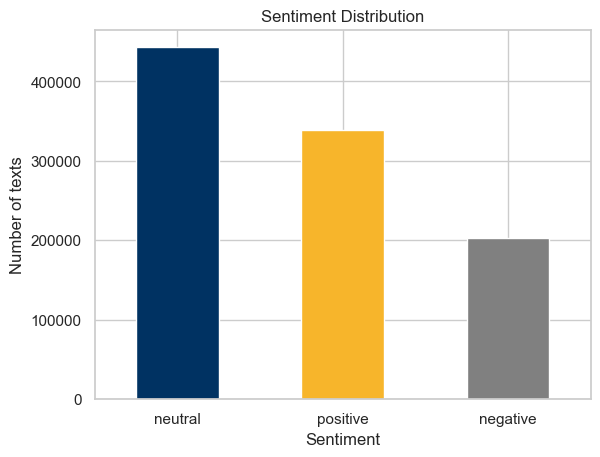

,text,cleaned_text,compound,sentiment_label
0,I've done pretty well defending myself against...,I've done pretty well defending myself against...,0.4376,positive
1,What Does ChatGPT Mean for New Software Develo...,What Does ChatGPT Mean for New Software Develo...,0.0000,neutral
2,You can subscribe at\nhttps://openai.com/blog/...,You can subscribe at\n\n\nMicheleTalso wroclaw...,0.0000,neutral
3,🧠💯💥\nI just tried the #chatGPT asking some ran...,:brain::hundred_points::collision:\nI just tri...,0.5106,positive
4,"A5: In the coming years, it is likely that AI ...","A5: In the coming years, it is likely that AI ...",0.1779,positive


In [42]:
# --- Step 0: Imports ---
import pandas as pd
from nltk.sentiment import SentimentIntensityAnalyzer
import nltk

# Download required resources
nltk.download('vader_lexicon')

# --- Step 1: Initialize VADER ---
sia = SentimentIntensityAnalyzer()

# --- Step 2: Sentiment analysis ---
# Use original text (not heavily cleaned) for sentiment scoring
df['sentiment_scores'] = df['text'].apply(lambda x: sia.polarity_scores(str(x)))

# Extract compound score
df['compound'] = df['sentiment_scores'].apply(lambda x: x['compound'])

# --- Step 3: Assign sentiment labels ---
def get_label(score):
    if score >= 0.05:
        return 'positive'
    elif score <= -0.05:
        return 'negative'
    else:
        return 'neutral'

df['sentiment_label'] = df['compound'].apply(get_label)

# --- Step 4: Count sentiment categories ---
sentiment_counts = df['sentiment_label'].value_counts()
print("Sentiment Counts:\n", sentiment_counts)

# Optional: visualize distribution
import matplotlib.pyplot as plt
sentiment_counts.plot(kind='bar', color=['#003262', '#F7B52B', 'gray'])
plt.xticks(rotation=0)
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Number of texts')
plt.show()


# --- Step 5: Inspect results ---
df[['text', 'cleaned_text', 'compound', 'sentiment_label']].head()


In [43]:
sentiment_counts = df['sentiment_label'].value_counts()
print(sentiment_counts)

sentiment_label
neutral     442879
positive    338578
negative    202371
Name: count, dtype: int64


In [44]:
# Remove duplicates based on 'text'
df_unique = df.drop_duplicates(subset='text')

# Select top 5 negative posts
top_negative = df_unique[df_unique['sentiment_label'] == 'negative'].sort_values(by='compound').head(5)

# Create a DataFrame for display
top_negative_df = top_negative.reset_index(drop=True)[['text', 'compound', 'sentiment_label']]

# Add a ranking column
top_negative_df.insert(0, 'Rank', top_negative_df.index + 1)

# Display the DataFrame
pd.set_option('display.max_colwidth', None)  # Ensures full text is shown
top_negative_df

,Rank,text,compound,sentiment_label
0,1,I've trained an LLM on my last 100 text messages STOP STOP STOP STOP STOP STOP STOP STOP STOP STOP STOP STOP STOP STOP STOP STOP STOP STOP STOP STOP STOP STOP STOP STOP STOP STOP STOP STOP STOP STOP STOP STOP STOP STOP STOP STOP,-0.9985,negative
1,2,"Google AI summarizing product reviews: perfect use case, just don't force it on me when I search for it.\n\nGoogle AI summarizing scientific facts: die die die die die die die die die die die die die die die die die die die die die die die die",-0.9983,negative
2,3,"Fuck OpenAI, fuck Sam Altman, fuck ChatGPT, fuck Copilot, fuck Gemini, fuck Grok, fuck Claude, fuck Deepseek, fuck generative AI, fuck the billionaires, fuck the greedy bastards, fuck the tariffs, fuck the enshittification of the Internet, fuck this timeline in general.",-0.9952,negative
3,4,"Fuck OpenAI, fuck Sam Altman, fuck ChatGPT, fuck Copilot, fuck Gemini, fuck Grok, fuck Claude, fuck Deepseek, fuck generative AI, fuck the billionaires, fuck the greedy bastards, fuck the tariffs, fuck this timeline in general.",-0.9945,negative
4,5,This AI race reminds me of the old days of:\n\n- Home Computer Wars\n- PC Wars\n- C Compiler Wars\n- Unix Wars\n- C++ Wars\n- Character UI Wars\n- TSR Wars\n- GUI Wars\n- Smalltalk vs. The World Wars\n- GUI Framework Wars\n- VB Component Wars\n- OS Wars\n- Database Wars\n- eCommerce Wars\n\n1/2,-0.9944,negative


In [45]:
# Remove duplicates based on 'text'
df_unique = df.drop_duplicates(subset='text')

# Select top 5 positive posts excluding those that mention "Gemini"
top_positive = df_unique[
    (df_unique['sentiment_label'] == 'positive') & 
    (~df_unique['text'].str.contains("Gemini", case=False, na=False))
].sort_values(by='compound', ascending=False).head(5)

# Create a DataFrame for display
top_positive_df = top_positive.reset_index(drop=True)[['text', 'compound', 'sentiment_label']]

# Add a ranking column
top_positive_df.insert(0, 'Rank', top_positive_df.index + 1)

# Display the DataFrame
pd.set_option('display.max_colwidth', None)  # Ensures full text is shown
top_positive_df

,Rank,text,compound,sentiment_label
0,1,Voting has started for the fifth Gems of the Year awards. This year's categories:\n\n1. Best content\n2. Best template\n3. Best tool\n4. Best existing plugin\n5. Best LLM integration\n6. Best third-party integration\n7. Best new theme\n8. Best new plugin\n\nJoin us on the official Obsidian Discord to vote!,0.9902,positive
1,2,"What I'm imagining is the following\n\nShareholders: MOAR PROFITS\n\nGoogle: But we're a $b company, we're great\n\nSH: MOAR PROFIT! Innovate!\n\nManager: AI counts as innovation\n\nSH: Yes! MOAR!\n\nCustomers: Hey this is silly and does not work\n\nSH: uh\n\nManager: It will work eventually!\n\nSH: YES! MOAR PROFIT!",0.9899,positive
2,3,"The Meta AI is good, it’s not quite ChatGPT, but it’s great being to be able to ask complex questions in real language, ask it questions about what I’m looking at.\n\nBut the ability to discretely listen to audio, take phone calls truly hands and ears free is great and hands free photography is best",0.9897,positive
3,4,"Image by ChatGPT: ""May love and laughter light your days and warm your heart and home. May good and faithful friends be yours wherever you may roam. May peace and plenty bless your world with joy that long endures. May all life's passing seasons bring the best to you and yours!"" Old Irish Blessing",0.9882,positive
4,5,"I am pretty new to DnD, but my group just started a campaign, and having to make up stuff like that was a big part of the fun? I had to get a lot of help making my character sheet, but like, everyone was happy to help me, and we had a good time with it. Using AI would have just bypassed more fun.",0.9877,positive


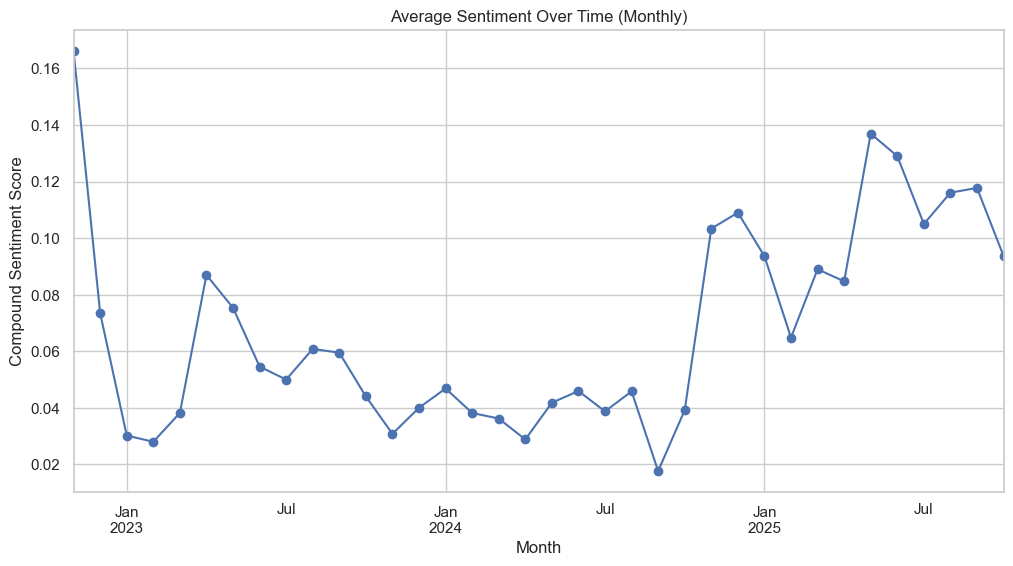

In [46]:
import pandas as pd
import matplotlib.pyplot as plt

# 1️⃣ Convert created_at to datetime and drop invalid dates
df['date'] = pd.to_datetime(df['created_at'], errors='coerce')
df = df.dropna(subset=['date', 'compound'])

# 2️⃣ Filter date range
start_date = "2022-11-01"
end_date   = "2025-11-30"

filtered_df = df[(df['date'] >= start_date) & (df['date'] <= end_date)]

# 3️⃣ Group by month and calculate average compound sentiment
sentiment_over_time = (
    filtered_df.groupby(filtered_df['date'].dt.to_period('M'))['compound'].mean()
    .to_timestamp()  # convert PeriodIndex → datetime for plotting
)

# 4️⃣ Plot
sentiment_over_time.plot(kind='line', figsize=(12, 6), marker='o')
plt.title("Average Sentiment Over Time (Monthly)")
plt.ylabel("Compound Sentiment Score")
plt.xlabel("Month")
plt.grid(True)
plt.show()


In [47]:
# Make sure you have compound scores

analyzer = SentimentIntensityAnalyzer()
df['compound'] = df['cleaned_text'].apply(lambda x: analyzer.polarity_scores(str(x))['compound'])

# Create labels
def label_sentiment(score):
    if score >= 0.05:
        return "positive"
    elif score <= -0.05:
        return "negative"
    else:
        return "neutral"

df['sentiment_label'] = df['compound'].apply(label_sentiment)

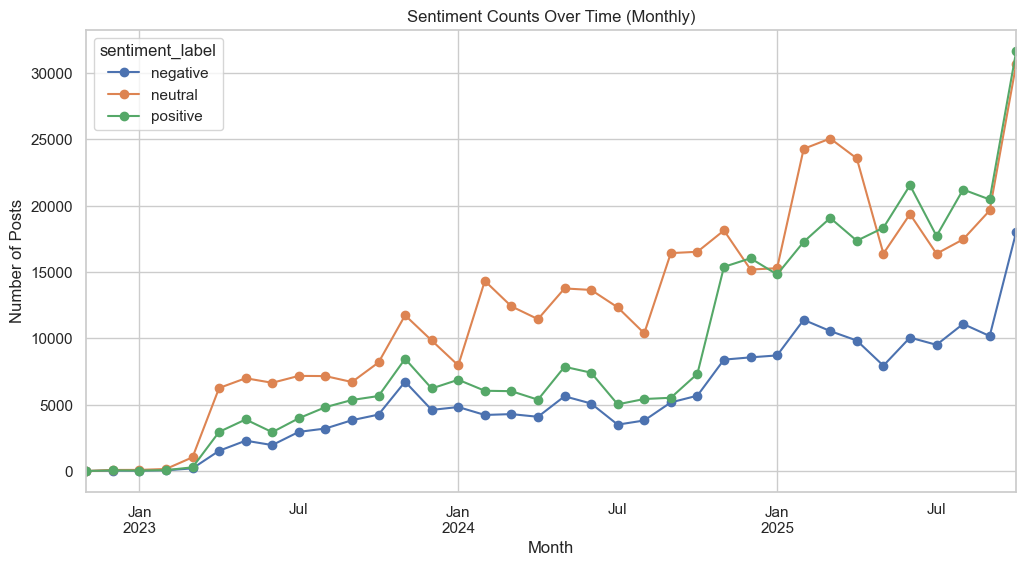

In [48]:

df['date'] = pd.to_datetime(df['created_at'], errors='coerce')
df = df.dropna(subset=['date', 'sentiment_label'])

start_date = "2022-11-01"
end_date   = "2025-11-30"
filtered_df = df[(df['date'] >= start_date) & (df['date'] <= end_date)]

sentiment_over_time = (
    filtered_df.groupby([filtered_df['date'].dt.to_period('M'), 'sentiment_label'])
    .size()
    .unstack(fill_value=0)  
    .to_timestamp()         
)

sentiment_over_time.plot(kind='line', figsize=(12, 6), marker='o')
plt.title("Sentiment Counts Over Time (Monthly)")
plt.xlabel("Month")
plt.ylabel("Number of Posts")
plt.grid(True)
plt.show()


In [49]:

df['virality'] = df['like_count'] + df['repost_count'] + df['reply_count']

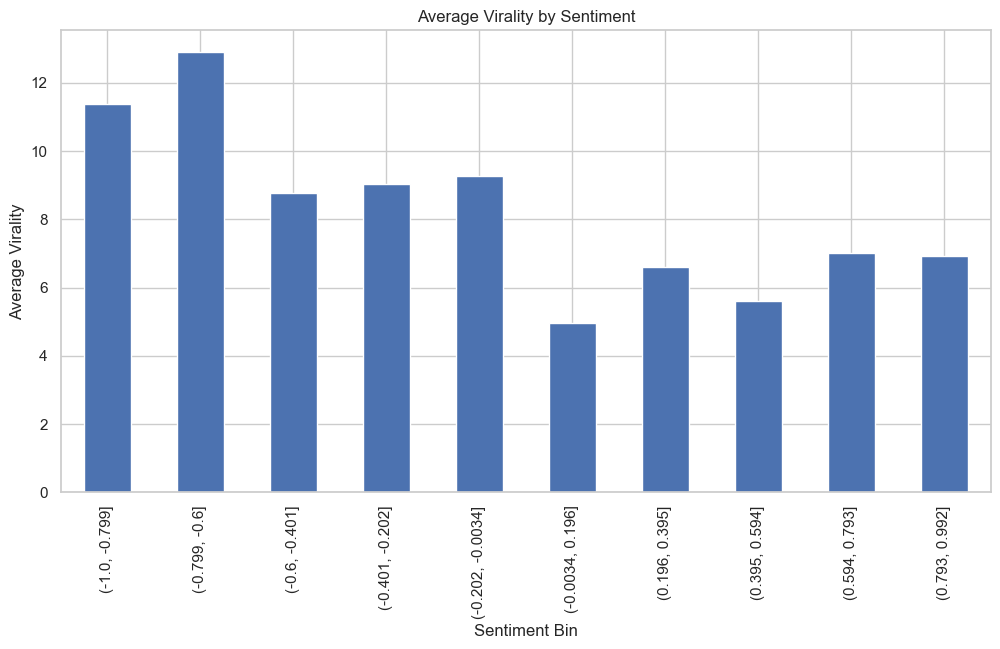

In [52]:
analyzer = SentimentIntensityAnalyzer()
df['compound'] = df['cleaned_text'].apply(lambda x: analyzer.polarity_scores(str(x))['compound'])

# Bin sentiment into 10 buckets
df['sentiment_bin'] = pd.cut(df['compound'], bins=10)

# Compute average virality per bin
avg_virality = df.groupby('sentiment_bin')['virality'].mean()

# Plot
avg_virality.plot(kind='bar', figsize=(12, 6))
plt.title("Average Virality by Sentiment")
plt.ylabel("Average Virality")
plt.xlabel("Sentiment Bin")
plt.show()



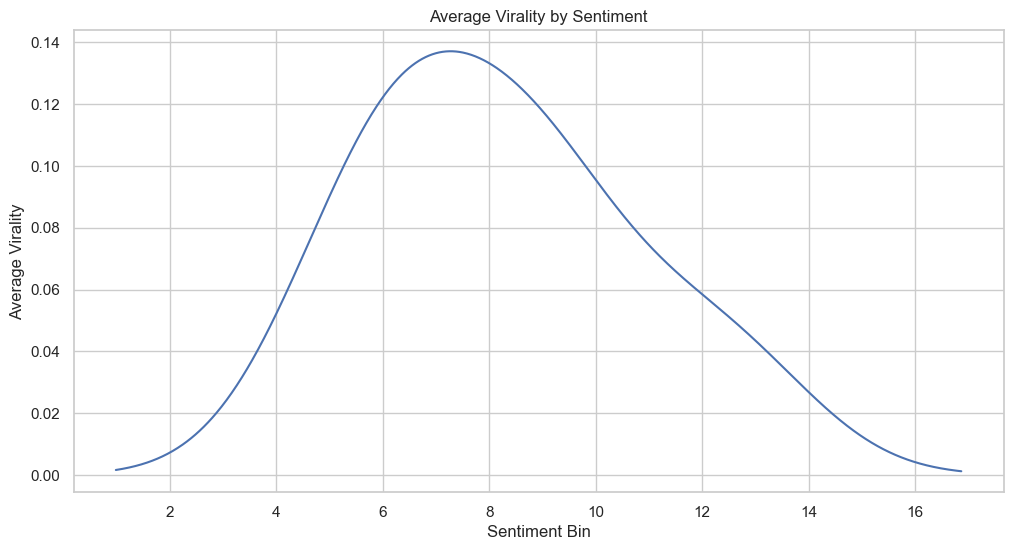

In [53]:
avg_virality.plot(kind='density', figsize=(12, 6))
plt.title("Average Virality by Sentiment")
plt.ylabel("Average Virality")
plt.xlabel("Sentiment Bin")
plt.show()

In [54]:
# Example list of job-related keywords
job_keywords = [
    "job", "jobs", "hiring", "career", "position", "interview", 
    "salary", "employment", "work", "role", "vacancy", "recruitment"
]

# Make a regex pattern for any of these keywords
pattern = "|".join(job_keywords)

# Filter dataframe (case-insensitive)
job_df = df[df["cleaned_text"].str.contains(pattern, case=False, na=False)]

# Reset index for cleanliness
job_df = job_df.reset_index(drop=True)

print(f"Number of job-related posts: {len(job_df)}")
job_df.head(10)

Number of job-related posts: 74529


,keyword,author,text,created_at,uri,like_count,repost_count,reply_count,author_display_name,has_embedded_media,cleaned_text,sentiment_scores,compound,sentiment_label,date,virality,sentiment_bin
0,ai,john.whites.site,"A5: In the coming years, it is likely that AI will continue to play a significant role in the development and disruption of businesses across a wide range of sectors. (ChatGPT generated response) #CollabTalk",2024-12-06T12:27:23.653Z,at://did:plc:eha4zzrxqaezc6rxpni3dkos/app.bsky.feed.post/3lcn6lkw3322s,0,0,0,John P White,False,"A5: In the coming years, it is likely that AI will continue to play a significant role in the development and disruption of businesses across a wide range of sectors. (ChatGPT generated response) #CollabTalk","{'neg': 0.07, 'neu': 0.812, 'pos': 0.118, 'compound': 0.1779}",0.1779,positive,2024-12-06 12:27:23.653000+00:00,0,"(-0.0034, 0.196]"
1,chatgpt,jorgeorchilles.bsky.social,"ChatGPT for Offensive Security video followed by David Hoelzer explaining how it all works https://youtu.be/-zUOsO6i92I\n\nIf you want to learn more, I highly encourage you to taking his class SEC595: https://www.sans.org/cyber-security-courses/applied-data-science-machine-learning/",2024-11-24T07:11:01.950Z,at://did:plc:qfuha4d2jzek2jhmemjkiui6/app.bsky.feed.post/3lbohcsyqnh2r,0,0,1,Jorge Orchilles,False,"ChatGPT for Offensive Security video followed by David Hoelzer explaining how it all works \n\nIf you want to learn more, I highly encourage you to taking his class SEC595:","{'neg': 0.082, 'neu': 0.711, 'pos': 0.207, 'compound': 0.5531}",0.5531,positive,2024-11-24 07:11:01.950000+00:00,1,"(0.395, 0.594]"
2,chatgpt,jholston.bsky.social,"""been having a blast with ChatGPT. In the past week I've written website copy (and many) emails, wrote legal templates, updated our board charters, wrote funny songs for (kids), and created the first draft of a new company policy. This is going to (quickly) transform work""",2024-11-19T02:45:37.523Z,at://did:plc:so2fnehffqkhq34asodug5aw/app.bsky.feed.post/3lbbg5myqmb2w,0,0,0,JB Holston,True,"""been having a blast with ChatGPT. In the past week I've written website copy (and many) emails, wrote legal templates, updated our board charters, wrote funny songs for (kids), and created the first draft of a new company policy. This is going to (quickly) transform work""","{'neg': 0.0, 'neu': 0.865, 'pos': 0.135, 'compound': 0.6597}",0.6597,positive,2024-11-19 02:45:37.523000+00:00,0,"(0.594, 0.793]"
3,chatgpt,socworkpodcast.bsky.social,"This tweet thread brought to you by #ChatGPT and the prompt, ""Create a twitter thread about social work and technology""\n#SWTech #SWFutures\nhttps://chat.openai.com/chat",2024-11-22T20:14:37.272Z,at://did:plc:wgncrohorvky4xdo6a2ank4t/app.bsky.feed.post/3lbks65imbi2c,0,0,0,Social Work Podcast,False,"This tweet thread brought to you by #ChatGPT and the prompt, ""Create a twitter thread about social work and technology""\n#SWTech #SWFutures\n","{'neg': 0.0, 'neu': 0.909, 'pos': 0.091, 'compound': 0.2732}",0.2732,positive,2024-11-22 20:14:37.272000+00:00,0,"(0.196, 0.395]"
4,chatgpt,schmoller.net,"Illuminating experiment with ChatGPT by Lex Toumbourou:\nhttps://notesbylex.com/disputing-a-parking-fine-with-chatgpt.html ""It's like having a talented personal assistant (who is often wrong - need to read their work thoroughly) at your fingertips."" (Via 🐘veletsianos@mastodon.social)",2024-11-04T21:35:58.685Z,at://did:plc:7ozv52xitkpjflxhygf5c65b/app.bsky.feed.post/3la5od2ggmf2j,0,0,0,Seb Schmoller,True,"Illuminating experiment with ChatGPT by Lex Toumbourou:\n ""It's like having a talented personal assistant (who is often wrong - need to read their work thoroughly) at your fingertips."" (Via :elephant:veletsianosmastodon.social)","{'neg': 0.089, 'neu': 0.745, 'pos': 0.166, 'compound': 0.4019}",0.4019,positive,2024-11-04 21:35:58.685000+00:00,0,"(0.395, 0.594]"
5,chatgpt,infotainment.bsky.social,Statistical learning in action. #ChatGPT does a decent job of creati

Number of positive posts: 38282


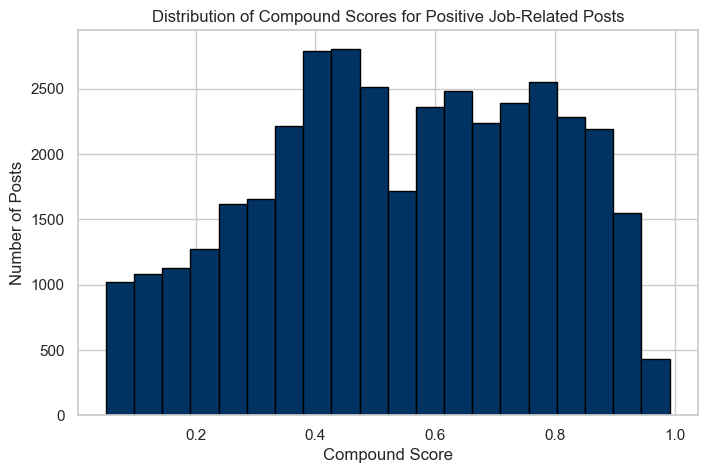

,cleaned_text,compound
0,"A5: In the coming years, it is likely that AI will continue to play a significant role in the development and disruption of businesses across a wide range of sectors. (ChatGPT generated response) #CollabTalk",0.1779
1,"ChatGPT for Offensive Security video followed by David Hoelzer explaining how it all works \n\nIf you want to learn more, I highly encourage you to taking his class SEC595:",0.5531
2,"""been having a blast with ChatGPT. In the past week I've written website copy (and many) emails, wrote legal templates, updated our board charters, wrote funny songs for (kids), and created the first draft of a new company policy. This is going to (quickly) transform work""",0.6597
3,"This tweet thread brought to you by #ChatGPT and the prompt, ""Create a twitter thread about social work and technology""\n#SWTech #SWFutures\n",0.2732
4,"Illuminating experiment with ChatGPT by Lex Toumbourou:\n ""It's like having a talented personal assistant (who is often wrong - need to read their work thoroughly) at your fingertips."" (Via :elephant:veletsianosmastodon.social)",0.4019
5,Statistical learning in action. #ChatGPT does a decent job of creating APA-formatted citations.,0.2960
6,Statistical learning in action. #ChatGPT does a decent job of creating APA-formatted citations.,0.2960
7,"In 1 day, ChatGPT has quickly become my buddy to ask profound questions and marvel at the response! How freaking apt and insanely accurate it is on fuzzy responses!!!! As ML practitioner, I get extra hit in knowing how hard it is to create something this simple that just works!!!",0.4344
8,"Asked OpenAI's ChatGPT (Dec 15 version) to write me a poem.\n\nI'd say our jobs are safe for now, poets ...",0.4404
9,Working in a SaaS and not sure what to do for entertainment at the next company holiday party? \n\nChatGPT to the rescue!\n\n“Rewrite the lyrics from Hamilton's What’s comes Next to be about churning customers of a SaaS company”\n\n,0.8699


In [55]:
# Filter only positive posts
positive_posts = job_df[job_df['sentiment_label'] == 'positive']

# Optional: see how many positive posts
print(f"Number of positive posts: {len(positive_posts)}")

# Plot the distribution of compound scores for positive posts
plt.figure(figsize=(8,5))
plt.hist(positive_posts['compound'], bins=20, color='#003262', edgecolor='black')
plt.title('Distribution of Compound Scores for Positive Job-Related Posts')
plt.xlabel('Compound Score')
plt.ylabel('Number of Posts')
plt.show()

# Inspect some of the top positive posts
positive_posts[['cleaned_text', 'compound']].head(10)

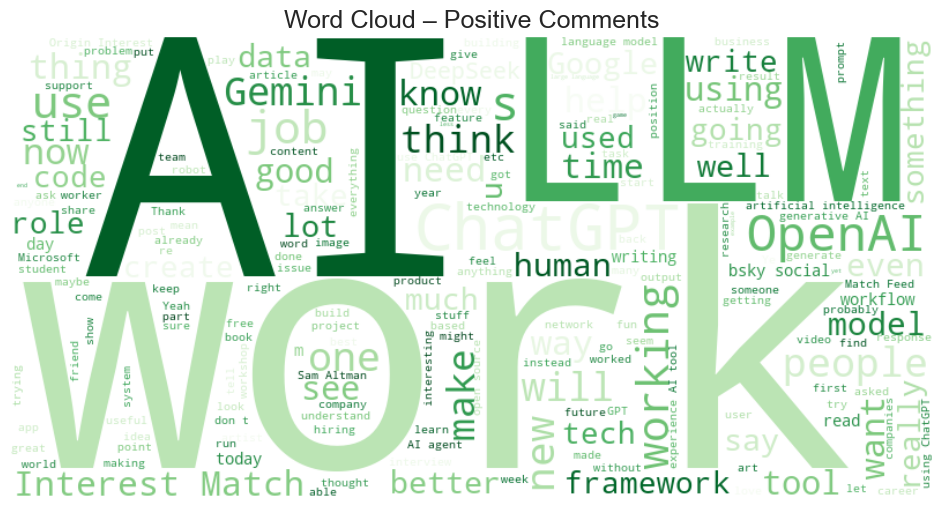

In [57]:
from wordcloud import WordCloud

# Filter only positive comments
positive_text = " ".join(
    job_df[job_df['sentiment_label'] == 'positive']['cleaned_text'].astype(str)
)

# Generate word cloud
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap='Greens',   # Optional: green color palette for positive sentiment
    max_words=200
).generate(positive_text)

# Display
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.title("Word Cloud – Positive Comments", fontsize=18)
plt.axis('off')
plt.show()

In [58]:
# --- Descriptive statistics for sentiment ---
desc_stats = job_df['compound'].describe()
print("Descriptive Statistics for Compound Sentiment:\n")
print(desc_stats)

# Optional: include sentiment counts
sentiment_counts = job_df['sentiment_label'].value_counts()
print("\nSentiment Label Counts:\n")
print(sentiment_counts)

# Optional: percentages of each sentiment
sentiment_percent = job_df['sentiment_label'].value_counts(normalize=True) * 100
print("\nSentiment Label Percentages:\n")
print(sentiment_percent)

Descriptive Statistics for Compound Sentiment:

count    74529.000000
mean         0.163838
std          0.472194
min         -0.994400
25%         -0.025800
50%          0.097100
75%          0.557400
max          0.991600
Name: compound, dtype: float64

Sentiment Label Counts:

sentiment_label
positive    38282
negative    18366
neutral     17881
Name: count, dtype: int64

Sentiment Label Percentages:

sentiment_label
positive    51.365240
negative    24.642757
neutral     23.992003
Name: proportion, dtype: float64


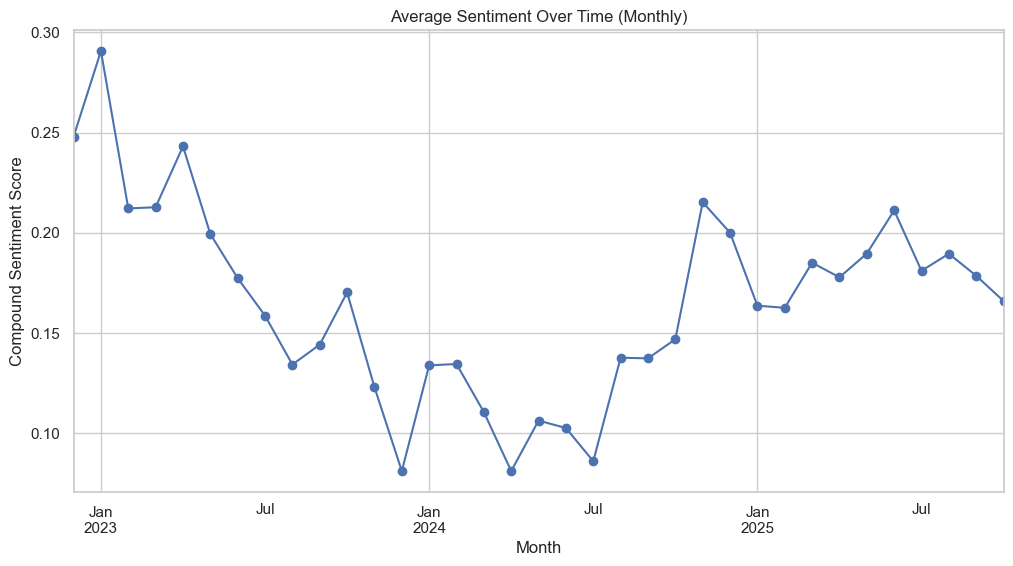

In [59]:
# Convert created_at to datetime
job_df['date'] = pd.to_datetime(job_df['created_at'], errors='coerce')

# Filter date range
start_date = "2022-11-01"
end_date   = "2025-11-30"   # end of Nov 2025

filtered_df = job_df[(job_df['date'] >= start_date) & (job_df['date'] <= end_date)]

# Group by month and take average compound sentiment
sentiment_over_time = filtered_df.groupby(filtered_df['date'].dt.to_period('M'))['compound'].mean()

# Plot
sentiment_over_time.plot(kind='line', figsize=(12, 6), marker='o')
plt.title("Average Sentiment Over Time (Monthly)")
plt.ylabel("Compound Sentiment Score")
plt.xlabel("Month")
plt.grid(True)
plt.show()

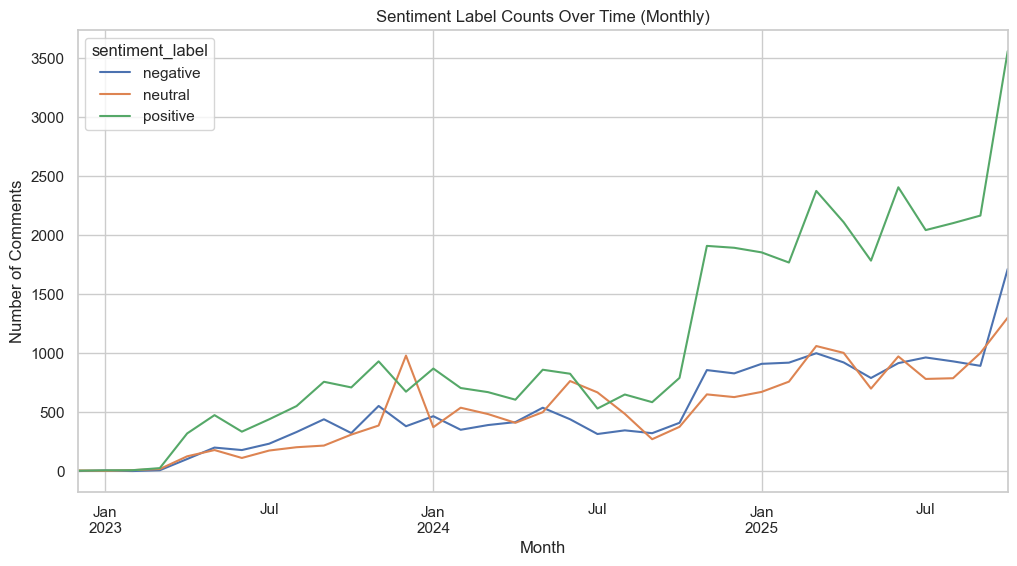

In [60]:
sentiment_labels_over_time = job_df.groupby([
    job_df['date'].dt.to_period('M'),
    'sentiment_label'
]).size().unstack(fill_value=0)

sentiment_labels_over_time.plot(kind='line', figsize=(12, 6))
plt.title("Sentiment Label Counts Over Time (Monthly)")
plt.ylabel("Number of Comments")
plt.xlabel("Month")
plt.grid(True)
plt.show()

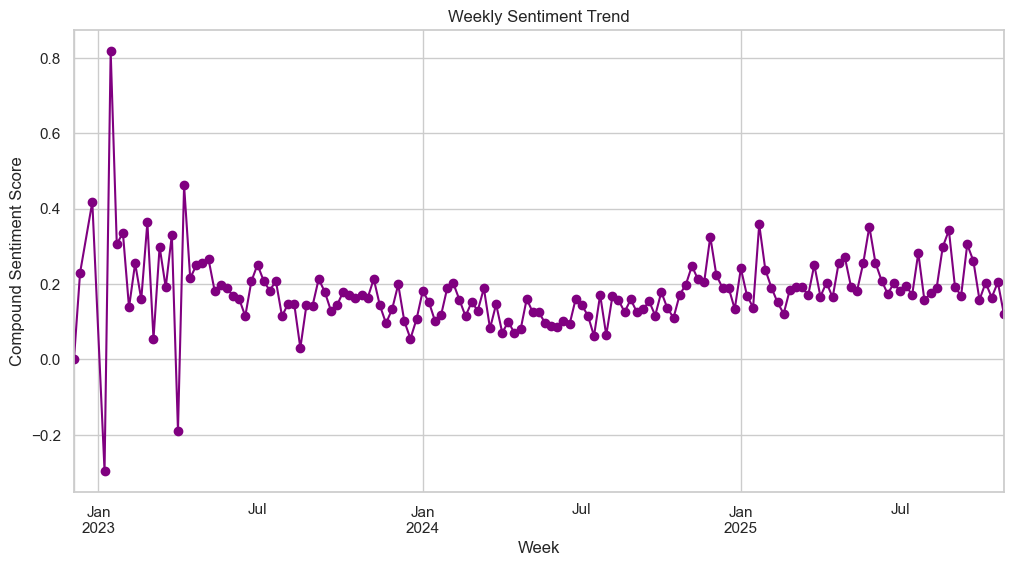

In [61]:
weekly_sentiment = job_df.groupby(job_df['date'].dt.to_period('W'))['compound'].mean()

weekly_sentiment.plot(kind='line', figsize=(12,6), marker='o', color='purple')
plt.title("Weekly Sentiment Trend")
plt.ylabel("Compound Sentiment Score")
plt.xlabel("Week")
plt.grid(True)
plt.show()

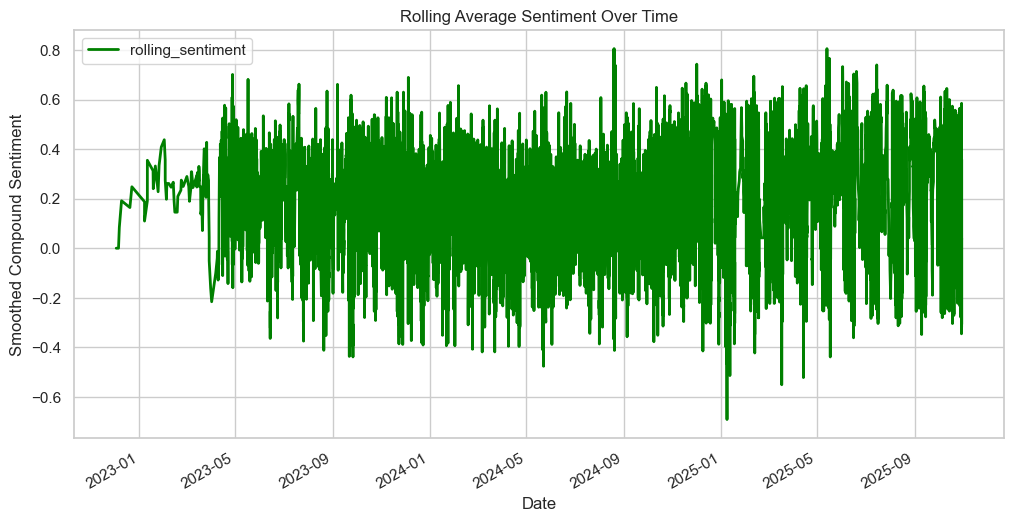

In [62]:
job_df_sorted = job_df.sort_values('date')

job_df_sorted['rolling_sentiment'] = (
    job_df_sorted['compound']
    .rolling(window=10, min_periods=1)
    .mean()
)

job_df_sorted.plot(
    x='date', 
    y='rolling_sentiment',
    figsize=(12,6),
    linewidth=2,
    color='green'
)

plt.title("Rolling Average Sentiment Over Time")
plt.ylabel("Smoothed Compound Sentiment")
plt.xlabel("Date")
plt.grid(True)
plt.show()


In [63]:
# 1. School-related keywords
school_keywords = [
    "school", "college", "university", "uni", "campus", "class",
    "homework", "study", "studying", "assignment", "teacher",
    "professor", "exam", "test", "lecture", "semester", "tuition",
    "education", "degree", "students", "student", "classroom"
]

# 2. Build regex pattern (whole-word match)
pattern = r"\b(" + "|".join(school_keywords) + r")\b"

# 3. Filter dataframe (case-insensitive)
school_df = df[df["cleaned_text"].str.contains(pattern, case=False, na=False, regex=True)]

# 4. Reset index
school_df = school_df.reset_index(drop=True)

# 5. Preview
print(f"Number of school-related posts: {len(school_df)}")
school_df.head(10)


Number of school-related posts: 28830


,keyword,author,text,created_at,uri,like_count,repost_count,reply_count,author_display_name,has_embedded_media,cleaned_text,sentiment_scores,compound,sentiment_label,date,virality,sentiment_bin
0,chatgpt,andrewdessler.com,"I think it will depend on the class. Next time I teach programming, I'll definitely have the students incorporate chatGPT into their coding because that's absolutely how people will program in the future. I already use it to help me write code.",2024-11-02T21:39:36.602Z,at://did:plc:uyemf6niinxjzirk7pbzzt3j/app.bsky.feed.post/3l7ynlpa3d32r,0,0,0,Andrew Dessler,False,"I think it will depend on the class. Next time I teach programming, I'll definitely have the students incorporate chatGPT into their coding because that's absolutely how people will program in the future. I already use it to help me write code.","{'neg': 0.0, 'neu': 0.873, 'pos': 0.127, 'compound': 0.6597}",0.6597,positive,2024-11-02 21:39:36.602000+00:00,0,"(0.594, 0.793]"
1,chatgpt,vincewall.bsky.social,"A ""more streamlined"" version of #ChatGPT ""is just around the corner"". ""We need to start thinking about this now, not in the future, because students are already using it. The education system has got to catch up with what’s already happening,”",2024-11-20T03:19:30.082Z,at://did:plc:eq6rkkatcc3xyul5jyjaufsp/app.bsky.feed.post/3lbdyiuwtlp2r,1,0,0,Vince Wall 💬,False,"A ""more streamlined"" version of #ChatGPT ""is just around the corner"". ""We need to start thinking about this now, not in the future, because students are already using it. The education system has got to catch up with what’s already happening,”","{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}",0.0000,neutral,2024-11-20 03:19:30.082000+00:00,1,"(-0.0034, 0.196]"
2,chatgpt,jorgeorchilles.bsky.social,"ChatGPT for Offensive Security video followed by David Hoelzer explaining how it all works https://youtu.be/-zUOsO6i92I\n\nIf you want to learn more, I highly encourage you to taking his class SEC595: https://www.sans.org/cyber-security-courses/applied-data-science-machine-learning/",2024-11-24T07:11:01.950Z,at://did:plc:qfuha4d2jzek2jhmemjkiui6/app.bsky.feed.post/3lbohcsyqnh2r,0,0,1,Jorge Orchilles,False,"ChatGPT for Offensive Security video followed by David Hoelzer explaining how it all works \n\nIf you want to learn more, I highly encourage you to taking his class SEC595:","{'neg': 0.082, 'neu': 0.711, 'pos': 0.207, 'compound': 0.5531}",0.5531,positive,2024-11-24 07:11:01.950000+00:00,1,"(0.395, 0.594]"
3,chatgpt,joelhooks.com,"eventually we'll be able to prompt ChatGPT ""please rewrite the 20,000,000 lines of Scala microservice code in Rust with 100% test coverage and a focus on performance""\n\nlol ☠️\n\nenjoy the salad days while they last!",2024-11-04T16:45:00.084Z,at://did:plc:urqqcsulsrxjf2mwy6qauxuu/app.bsky.feed.post/3la562qkkwm2v,0,0,0,joel 🌦️,False,"eventually we'll be able to prompt ChatGPT ""please rewrite the 20,000,000 lines of Scala microservice code in Rust with 100% test coverage and a focus on performance""\n\nlol :skull_and_crossbones:\n\nenjoy the salad days while they last!","{'neg': 0.0, 'neu': 0.788, 'pos': 0.212, 'compound': 0.8221}",0.8221,positive,2024-11-04 16:45:00.084000+00:00,0,"(0.793, 0.992]"
4,chatgpt,sharp.blue,ChatGPT might not pass the Turing Test but it could certainly outcompete humans in the Twitter troll niche. Some of them don’t come anywhere near passing.,2024-11-13T00:18:07.114Z,at://did:plc:dtl7jeyiscsbqmkmcsv7457b/app.bsky.feed.post/3las34dvb6z2c,0,0,0,Richard Baker,False,ChatGPT might not pass the Turing Test but it could certainly outcompete humans in the Twitter troll niche. Some of them don’t come anywhere near passing.,"{'neg': 0.0, 'neu': 0.89, 'pos': 0.11, 'compound': 0.4767}",0.4767,positive,2024-11-13 00:18:07.114000+00:00,0,"(0.395, 0.594]"
5,chatgpt,enfascination.com,Another things that's remarkable about ChatGPT is that when it's bad it rambles in exactly the way students do on short answers when they have no idea

In [64]:
# --- Step 0: Imports ---
import pandas as pd
from nltk.sentiment import SentimentIntensityAnalyzer
import nltk
import matplotlib.pyplot as plt

# Download required resources
nltk.download('vader_lexicon')

# --- Step 1: Initialize VADER ---
sia = SentimentIntensityAnalyzer()

# --- Step 2: Sentiment analysis on school_df ---
# Use cleaned_text
school_df['sentiment_scores'] = school_df['cleaned_text'].apply(lambda x: sia.polarity_scores(str(x)))

# Extract compound score
school_df['compound'] = school_df['sentiment_scores'].apply(lambda x: x['compound'])

# --- Step 3: Assign sentiment labels ---
def get_label(score):
    if score >= 0.05:
        return 'positive'
    elif score <= -0.05:
        return 'negative'
    else:
        return 'neutral'

school_df['sentiment_label'] = school_df['compound'].apply(get_label)

# --- Step 4: Count sentiment categories ---
sentiment_counts = school_df['sentiment_label'].value_counts()
print("Sentiment Counts:\n", sentiment_counts)

# --- Step 5: Inspect results ---
school_df[['cleaned_text', 'compound', 'sentiment_label']].head(10)


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/isabellalatchamradusky/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


Sentiment Counts:
 sentiment_label
positive    14880
negative     7801
neutral      6149
Name: count, dtype: int64


,cleaned_text,compound,sentiment_label
0,"I think it will depend on the class. Next time I teach programming, I'll definitely have the students incorporate chatGPT into their coding because that's absolutely how people will program in the future. I already use it to help me write code.",0.6597,positive
1,"A ""more streamlined"" version of #ChatGPT ""is just around the corner"". ""We need to start thinking about this now, not in the future, because students are already using it. The education system has got to catch up with what’s already happening,”",0.0000,neutral
2,"ChatGPT for Offensive Security video followed by David Hoelzer explaining how it all works \n\nIf you want to learn more, I highly encourage you to taking his class SEC595:",0.5531,positive
3,"eventually we'll be able to prompt ChatGPT ""please rewrite the 20,000,000 lines of Scala microservice code in Rust with 100% test coverage and a focus on performance""\n\nlol :skull_and_crossbones:\n\nenjoy the salad days while they last!",0.8221,positive
4,ChatGPT might not pass the Turing Test but it could certainly outcompete humans in the Twitter troll niche. Some of them don’t come anywhere near passing.,0.4767,positive
5,Another things that's remarkable about ChatGPT is that when it's bad it rambles in exactly the way students do on short answers when they have no idea.,-0.2732,negative
6,AI breakthrough ChatGPT raises alarm over student cheating,-0.7184,negative
7,"ChatGPT may change everything more than fusion power (for now). Students are already using it to cheat on exams at UToronto and all the academics I know are mulling over what exams will look like from now on. If a chat bot can answer the question, is it worth asking?",0.1027,positive
8,Schools blocking ChatGpt is like the time I got Wolfram_Alpha banned at my high school cause it made math too easy,-0.0516,negative
9,.john_cogs and I put #ChatGPT to the test to see if it has what it takes to contribute to a gitlab issue.\n\nCheck out our experiments and findings in this new post! :eyes: :robot: :laptop: :speech_balloon:...,0.0000,neutral


In [65]:
# --- Descriptive statistics for sentiment ---
desc_stats = school_df['compound'].describe()
print("Descriptive Statistics for Compound Sentiment:\n")
print(desc_stats)

# Optional: include sentiment counts
sentiment_counts = school_df['sentiment_label'].value_counts()
print("\nSentiment Label Counts:\n")
print(sentiment_counts)

# Optional: percentages of each sentiment
sentiment_percent = school_df['sentiment_label'].value_counts(normalize=True) * 100
print("\nSentiment Label Percentages:\n")
print(sentiment_percent)


Descriptive Statistics for Compound Sentiment:

count    28830.000000
mean         0.146126
std          0.477563
min         -0.983400
25%         -0.128000
50%          0.102700
75%          0.534600
max          0.982800
Name: compound, dtype: float64

Sentiment Label Counts:

sentiment_label
positive    14880
negative     7801
neutral      6149
Name: count, dtype: int64

Sentiment Label Percentages:

sentiment_label
positive    51.612903
negative    27.058619
neutral     21.328477
Name: proportion, dtype: float64


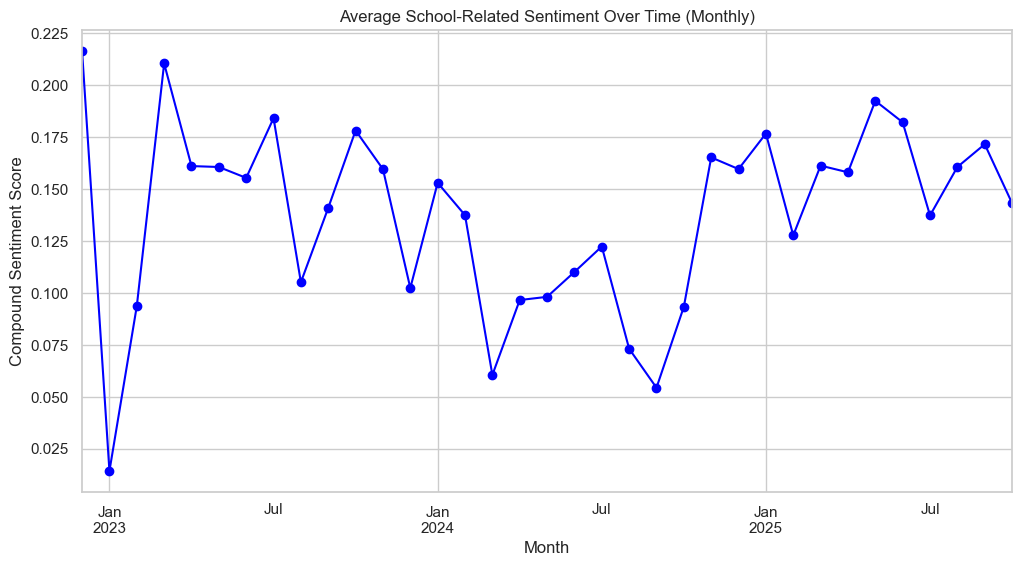

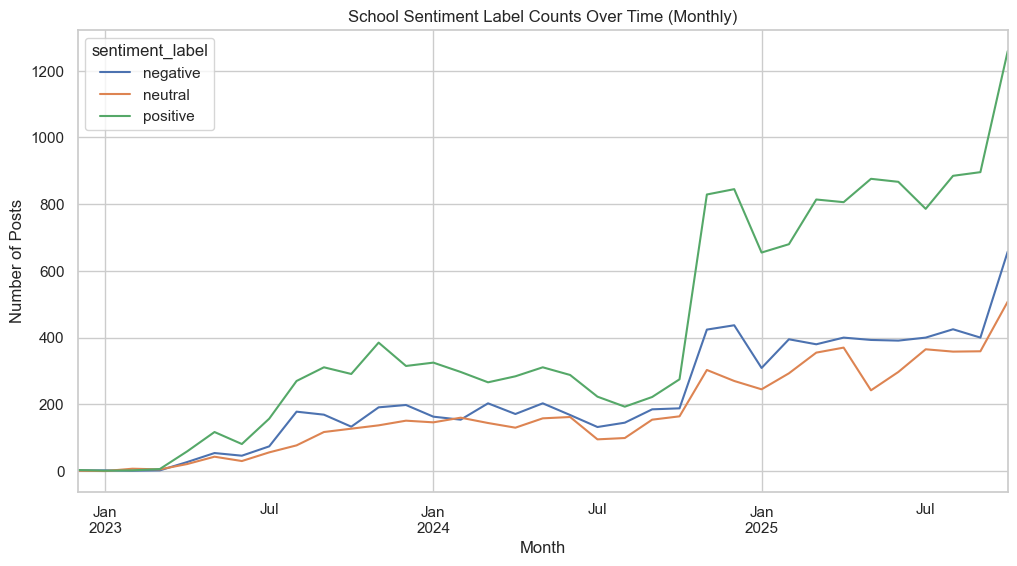

In [66]:
import matplotlib.pyplot as plt
import pandas as pd

# Ensure 'created_at' is datetime
school_df['date'] = pd.to_datetime(school_df['created_at'], errors='coerce')

# Filter date range Nov 2022 → Nov 2025
start_date = "2022-11-01"
end_date   = "2025-11-30"

filtered_df = school_df[
    (school_df['date'] >= start_date) &
    (school_df['date'] <= end_date)
]

# Group by month and compute average compound sentiment
sentiment_over_time = filtered_df.groupby(filtered_df['date'].dt.to_period('M'))['compound'].mean()

# Plot average sentiment over time
plt.figure(figsize=(12,6))
sentiment_over_time.plot(kind='line', marker='o', color='blue')
plt.title("Average School-Related Sentiment Over Time (Monthly)")
plt.ylabel("Compound Sentiment Score")
plt.xlabel("Month")
plt.grid(True)
plt.show()

# Optional: Count of sentiment labels over time
sentiment_labels_over_time = filtered_df.groupby([
    filtered_df['date'].dt.to_period('M'),
    'sentiment_label'
]).size().unstack(fill_value=0)

sentiment_labels_over_time.plot(kind='line', figsize=(12,6))
plt.title("School Sentiment Label Counts Over Time (Monthly)")
plt.ylabel("Number of Posts")
plt.xlabel("Month")
plt.grid(True)
plt.show()


Descriptive Statistics for Positive School Posts:

count    14880.000000
mean         0.531382
std          0.231414
min          0.051600
25%          0.361200
50%          0.520100
75%          0.726900
max          0.982800
Name: compound, dtype: float64


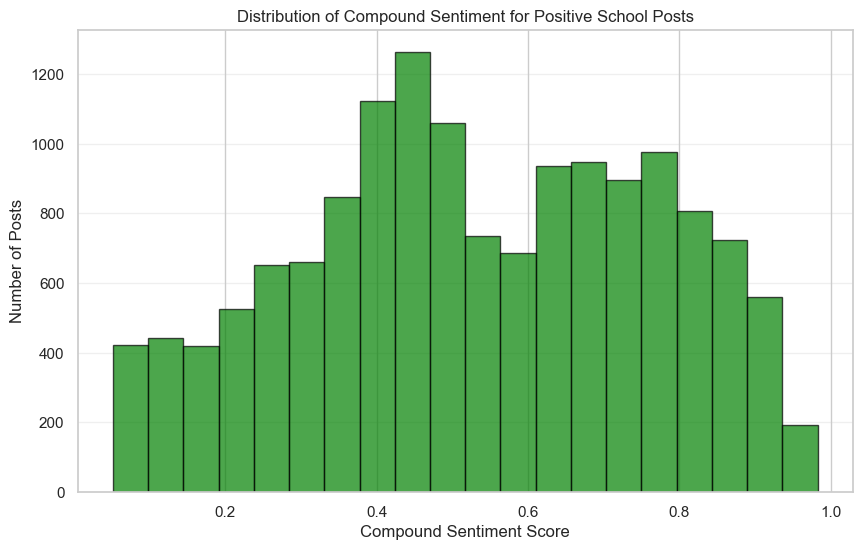

In [67]:


# Filter only positive posts
positive_df = school_df[school_df['sentiment_label'] == 'positive']

# Descriptive statistics for positive posts
pos_desc_stats = positive_df['compound'].describe()
print("Descriptive Statistics for Positive School Posts:\n")
print(pos_desc_stats)

# Plot distribution (histogram)
plt.figure(figsize=(10,6))
plt.hist(positive_df['compound'], bins=20, color='green', edgecolor='black', alpha=0.7)
plt.title("Distribution of Compound Sentiment for Positive School Posts")
plt.xlabel("Compound Sentiment Score")
plt.ylabel("Number of Posts")
plt.grid(axis='y', alpha=0.3)
plt.show()


Descriptive Statistics for Negative School Posts:

count    7801.000000
mean       -0.473779
std         0.237697
min        -0.983400
25%        -0.659700
50%        -0.476700
75%        -0.296000
max        -0.050400
Name: compound, dtype: float64


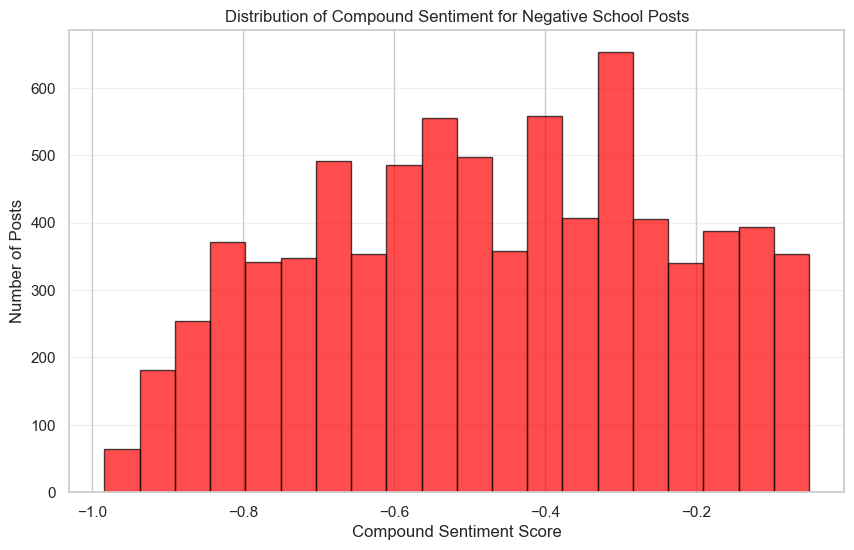

In [68]:
# Filter only negative posts
negative_df = school_df[school_df['sentiment_label'] == 'negative']

# Descriptive statistics for negative posts
neg_desc_stats = negative_df['compound'].describe()
print("Descriptive Statistics for Negative School Posts:\n")
print(neg_desc_stats)

# Plot distribution (histogram)
plt.figure(figsize=(10,6))
plt.hist(negative_df['compound'], bins=20, color='red', edgecolor='black', alpha=0.7)
plt.title("Distribution of Compound Sentiment for Negative School Posts")
plt.xlabel("Compound Sentiment Score")
plt.ylabel("Number of Posts")
plt.grid(axis='y', alpha=0.3)
plt.show()

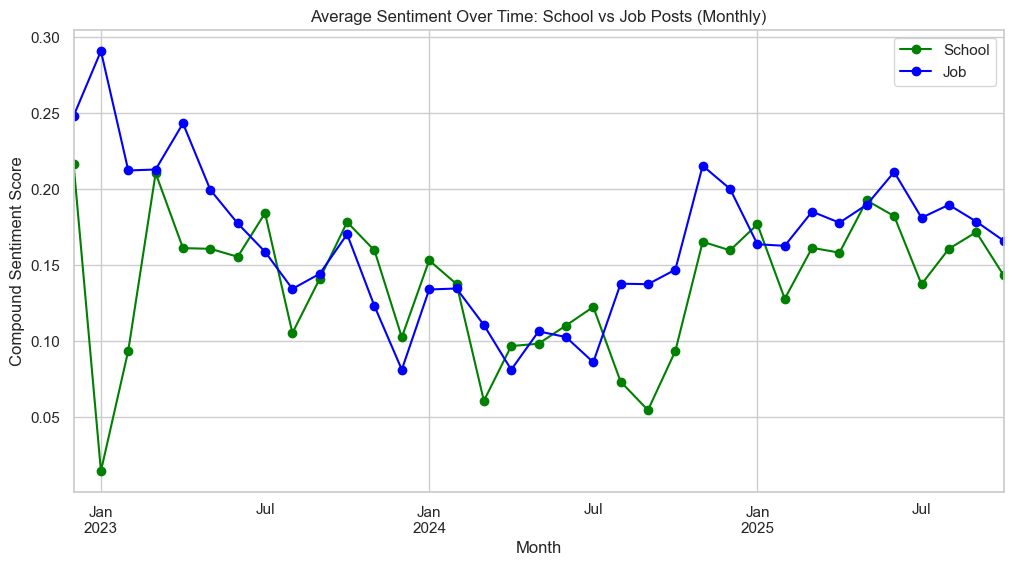

<Figure size 1200x600 with 0 Axes>

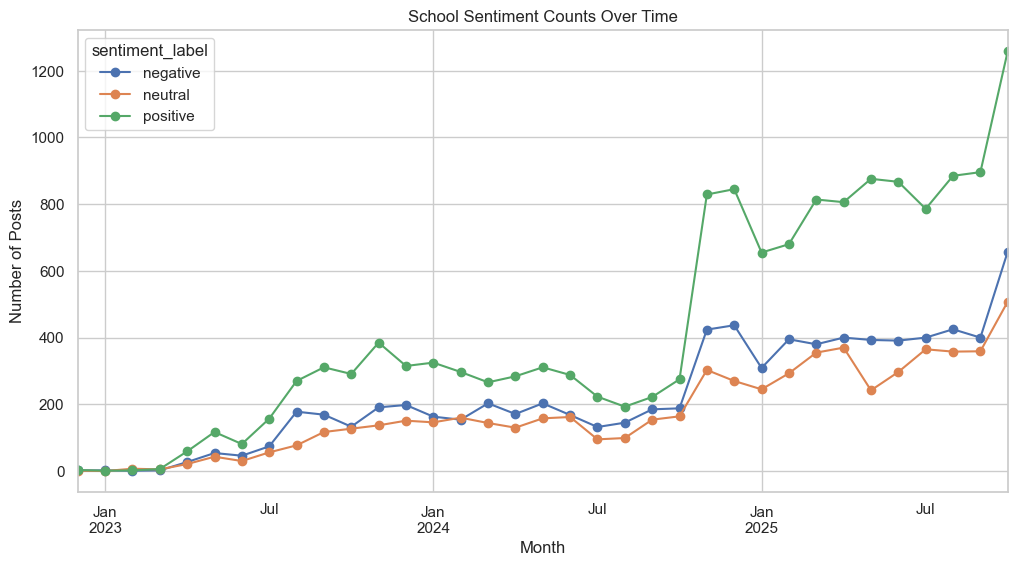

<Figure size 1200x600 with 0 Axes>

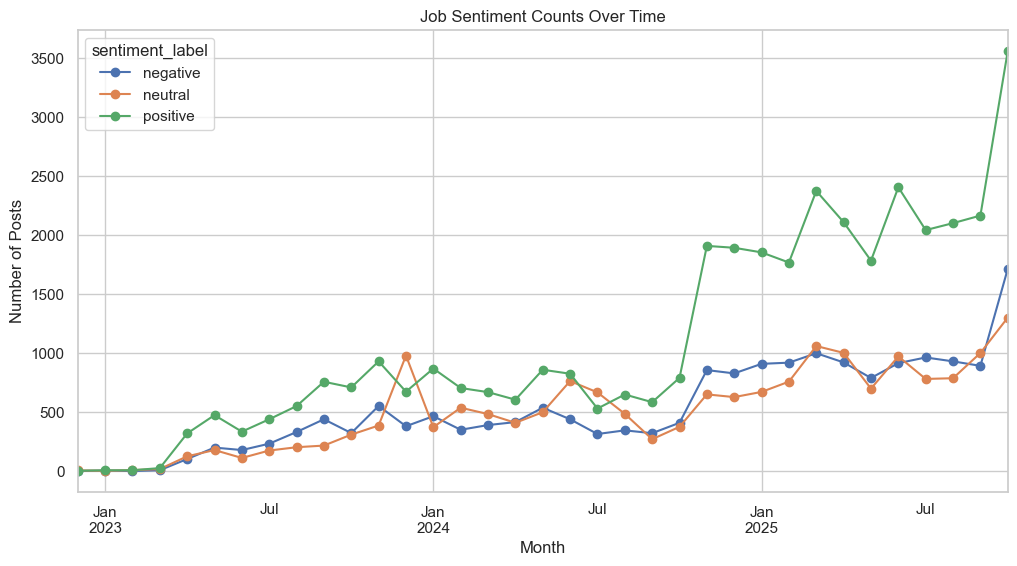

In [69]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Ensure datetime for both dataframes ---
school_df['date'] = pd.to_datetime(school_df['created_at'], errors='coerce')
job_df['date'] = pd.to_datetime(job_df['created_at'], errors='coerce')

# --- Filter date range (Nov 2022 to Nov 2025) ---
start_date = "2022-11-01"
end_date   = "2025-11-30"

school_filtered = school_df[(school_df['date'] >= start_date) & (school_df['date'] <= end_date)]
job_filtered    = job_df[(job_df['date'] >= start_date) & (job_df['date'] <= end_date)]

# --- Group by month and calculate average sentiment ---
school_sentiment = school_filtered.groupby(school_filtered['date'].dt.to_period('M'))['compound'].mean()
job_sentiment    = job_filtered.groupby(job_filtered['date'].dt.to_period('M'))['compound'].mean()

# --- Plot average sentiment over time for both ---
plt.figure(figsize=(12,6))
school_sentiment.plot(marker='o', color='green', label='School')
job_sentiment.plot(marker='o', color='blue', label='Job')
plt.title("Average Sentiment Over Time: School vs Job Posts (Monthly)")
plt.ylabel("Compound Sentiment Score")
plt.xlabel("Month")
plt.legend()
plt.grid(True)
plt.show()

# --- Optional: Count positive/neutral/negative posts per month for comparison ---
school_counts = school_filtered.groupby([school_filtered['date'].dt.to_period('M'), 'sentiment_label']).size().unstack(fill_value=0)
job_counts    = job_filtered.groupby([job_filtered['date'].dt.to_period('M'), 'sentiment_label']).size().unstack(fill_value=0)

plt.figure(figsize=(12,6))
school_counts.plot(marker='o', figsize=(12,6), title="School Sentiment Counts Over Time")
plt.ylabel("Number of Posts")
plt.xlabel("Month")
plt.grid(True)
plt.show()

plt.figure(figsize=(12,6))
job_counts.plot(marker='o', figsize=(12,6), title="Job Sentiment Counts Over Time")
plt.ylabel("Number of Posts")
plt.xlabel("Month")
plt.grid(True)
plt.show()


In [70]:
def top_ngrams(df, ngram_range=(1,2), top_n=20):
    vectorizer = CountVectorizer(stop_words='english', ngram_range=ngram_range)
    X = vectorizer.fit_transform(df['cleaned_text'].astype(str))
    counts = X.sum(axis=0)
    terms = vectorizer.get_feature_names_out()
    top_terms = sorted(zip(terms, counts.tolist()[0]), key=lambda x: x[1], reverse=True)
    return top_terms[:top_n]

# Example: top bigrams in school posts
top_ngrams(school_df, ngram_range=(2,2))

[('using chatgpt', 817),
 ('use chatgpt', 788),
 ('bsky social', 736),
 ('generative ai', 551),
 ('use ai', 548),
 ('artificial intelligence', 517),
 ('large language', 464),
 ('high school', 451),
 ('using ai', 431),
 ('language models', 407),
 ('new ai', 405),
 ('ai tools', 404),
 ('google gemini', 404),
 ('match feed', 390),
 ('ai education', 388),
 ('new study', 381),
 ('students use', 377),
 ('like chatgpt', 364),
 ('origin match', 357),
 ('free test', 336)]

In [72]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF

def get_topics(df, n_topics=3, n_top_words=10):
    tfidf = TfidfVectorizer(stop_words='english')
    X = tfidf.fit_transform(df['cleaned_text'].astype(str))
    nmf = NMF(n_components=n_topics, random_state=42)
    nmf.fit(X)
    feature_names = tfidf.get_feature_names_out()
    topics = []
    for topic_idx, topic in enumerate(nmf.components_):
        top_words = [feature_names[i] for i in topic.argsort()[-n_top_words:]]
        topics.append((topic_idx+1, top_words))
    return topics

get_topics(job_df, n_topics=3)


[(1,
  ['people',
   'job',
   'use',
   'just',
   'like',
   'openai',
   'llm',
   'chatgpt',
   'work',
   'ai']),
 (2,
  ['continues',
   'ios',
   'siri',
   'ai',
   'work',
   'generative',
   'podcast',
   'fleet',
   '9to5mac',
   'apple']),
 (3,
  ['synthart',
   'aiartcommunity',
   'aiイラスト',
   'aiartcommuity',
   'ａｉイラスト',
   'aiart',
   'ai画像',
   'aiartists',
   'digitalart',
   'aiartwork'])]

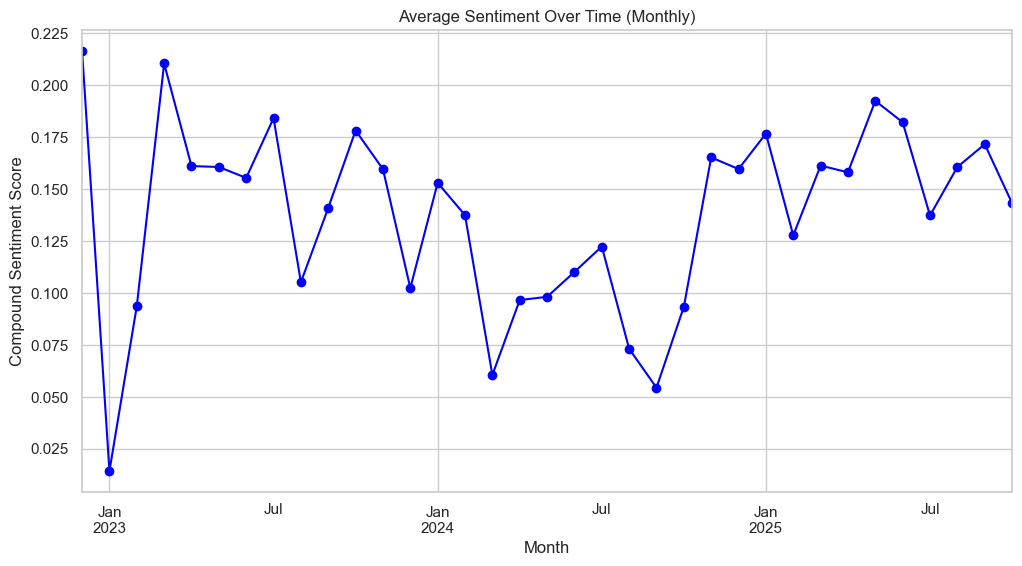

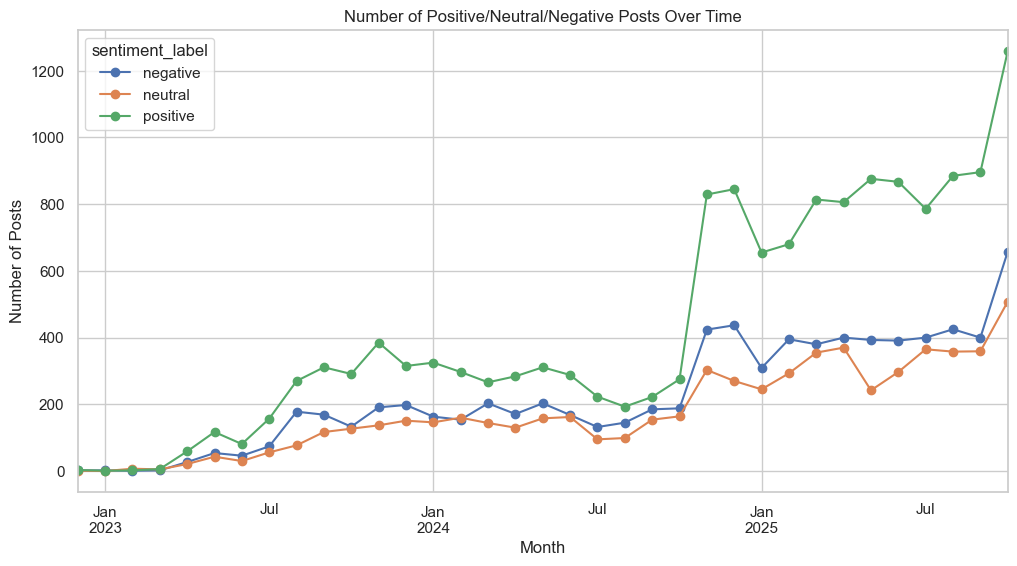

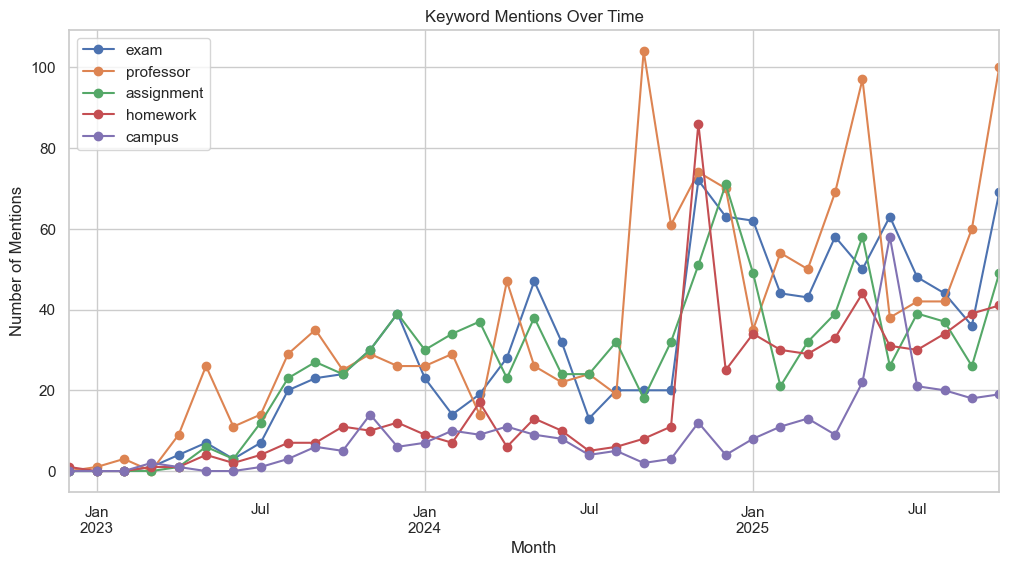

In [74]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Ensure datetime ---
school_df['date'] = pd.to_datetime(school_df['created_at'], errors='coerce')

# --- Filter date range (Nov 2022 to Nov 2025) ---
start_date = "2022-11-01"
end_date   = "2025-11-30"

filtered_df = school_df[
    (school_df['date'] >= start_date) &
    (school_df['date'] <= end_date)
]

# --- Group by month ---
monthly_sentiment = filtered_df.groupby(filtered_df['date'].dt.to_period('M'))['compound'].mean()

monthly_counts = filtered_df.groupby([filtered_df['date'].dt.to_period('M'), 'sentiment_label']).size().unstack(fill_value=0)

# --- Plot average sentiment over time ---
plt.figure(figsize=(12,6))
monthly_sentiment.plot(marker='o', color='blue')
plt.title("Average Sentiment Over Time (Monthly)")
plt.ylabel("Compound Sentiment Score")
plt.xlabel("Month")
plt.grid(True)
plt.show()

# --- Plot counts of sentiment labels over time ---
monthly_counts.plot(kind='line', figsize=(12,6), marker='o')
plt.title("Number of Positive/Neutral/Negative Posts Over Time")
plt.ylabel("Number of Posts")
plt.xlabel("Month")
plt.grid(True)
plt.show()

# --- Optional: Overlay keywords in spikes ---
# Define keywords to check
keywords = ["exam", "professor", "assignment", "homework", "campus"]

# Count keyword occurrences per month
def count_keyword_occurrences(df, keyword):
    return df['cleaned_text'].str.contains(keyword, case=False, na=False).groupby(df['date'].dt.to_period('M')).sum()

keyword_counts = pd.DataFrame({kw: count_keyword_occurrences(filtered_df, kw) for kw in keywords})

# Plot keyword trends
keyword_counts.plot(figsize=(12,6), marker='o')
plt.title("Keyword Mentions Over Time")
plt.ylabel("Number of Mentions")
plt.xlabel("Month")
plt.grid(True)
plt.show()


Number of college-related posts: 9674


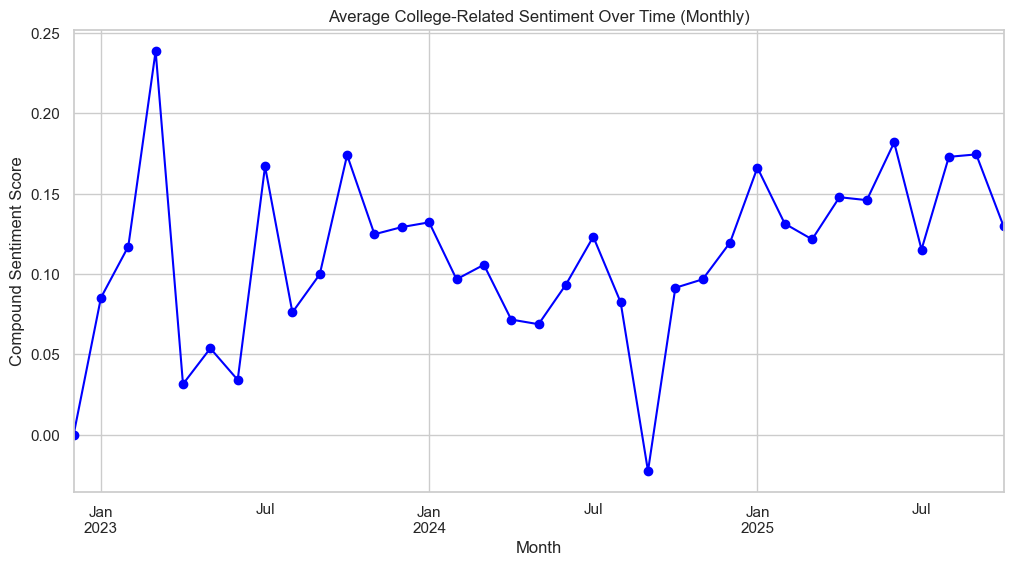

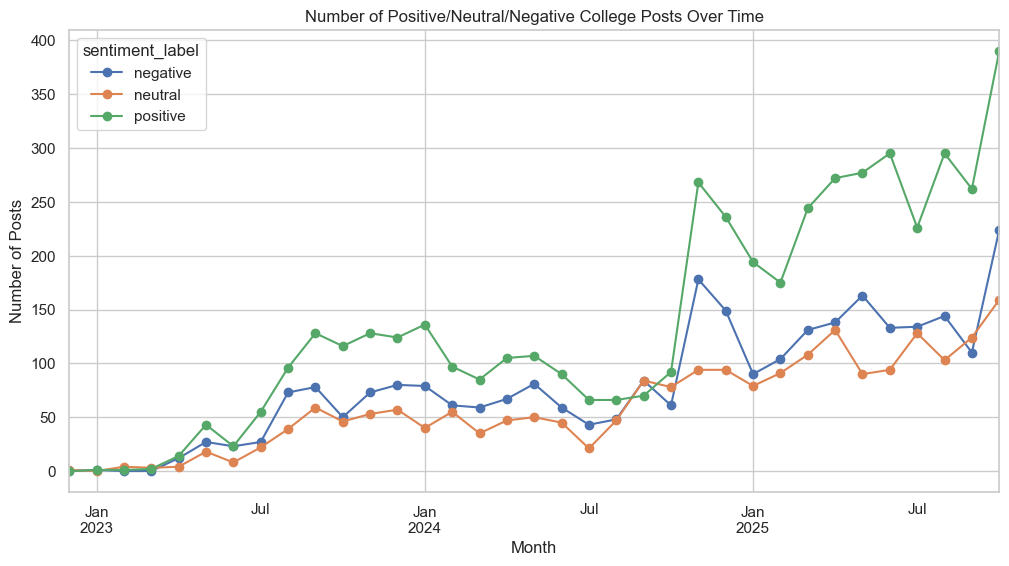

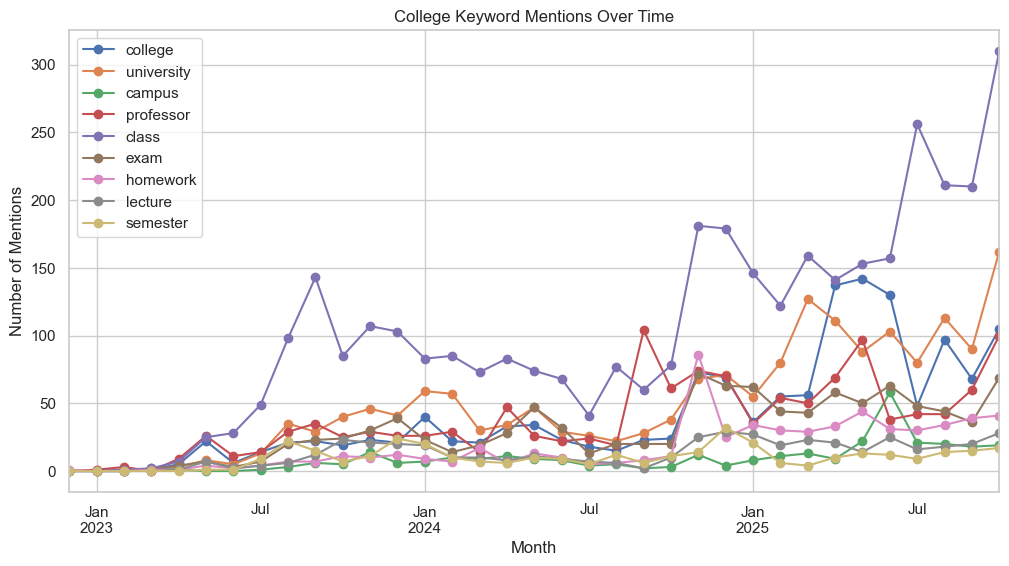

In [75]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Define college-related keywords ---
college_keywords = ["college", "university", "campus", "professor", "class", "exam", "homework", "lecture", "semester"]

# --- Filter posts containing any college keywords ---
college_df = school_df[school_df['cleaned_text'].str.contains("|".join(college_keywords), case=False, na=False)].copy()
college_df.reset_index(drop=True, inplace=True)

print(f"Number of college-related posts: {len(college_df)}")

# --- Ensure datetime ---
college_df['date'] = pd.to_datetime(college_df['created_at'], errors='coerce')

# --- Filter date range (Nov 2022 to Nov 2025) ---
start_date = "2022-11-01"
end_date   = "2025-11-30"
college_df = college_df[(college_df['date'] >= start_date) & (college_df['date'] <= end_date)]

# --- Group by month ---
monthly_sentiment = college_df.groupby(college_df['date'].dt.to_period('M'))['compound'].mean()
monthly_counts = college_df.groupby([college_df['date'].dt.to_period('M'), 'sentiment_label']).size().unstack(fill_value=0)

# --- Plot average sentiment over time ---
plt.figure(figsize=(12,6))
monthly_sentiment.plot(marker='o', color='blue')
plt.title("Average College-Related Sentiment Over Time (Monthly)")
plt.ylabel("Compound Sentiment Score")
plt.xlabel("Month")
plt.grid(True)
plt.show()

# --- Plot counts of sentiment labels over time ---
monthly_counts.plot(kind='line', figsize=(12,6), marker='o')
plt.title("Number of Positive/Neutral/Negative College Posts Over Time")
plt.ylabel("Number of Posts")
plt.xlabel("Month")
plt.grid(True)
plt.show()

# --- Optional: Keyword trends ---
# Count keyword occurrences per month
def count_keyword_occurrences(df, keyword):
    return df['cleaned_text'].str.contains(keyword, case=False, na=False).groupby(df['date'].dt.to_period('M')).sum()

keyword_counts = pd.DataFrame({kw: count_keyword_occurrences(college_df, kw) for kw in college_keywords})

# Plot keyword trends
keyword_counts.plot(figsize=(12,6), marker='o')
plt.title("College Keyword Mentions Over Time")
plt.ylabel("Number of Mentions")
plt.xlabel("Month")
plt.grid(True)
plt.show()


In [76]:
# --- Top positive posts ---

top_positive_school = school_df.nlargest(10, 'compound')[['cleaned_text', 'compound', 'sentiment_label']]
top_positive_job    = job_df.nlargest(10, 'compound')[['cleaned_text', 'compound', 'sentiment_label']]

print("=== Top 10 Positive School Posts ===")
for idx, row in top_positive_school.iterrows():
    print(f"Post {idx} (Score: {row['compound']}): {row['cleaned_text']}")
    print("-"*80)

print("\n=== Top 10 Positive Job Posts ===")
for idx, row in top_positive_job.iterrows():
    print(f"Post {idx} (Score: {row['compound']}): {row['cleaned_text']}")
    print("-"*80)


# --- Top negative posts ---

top_negative_school = school_df.nsmallest(10, 'compound')[['cleaned_text', 'compound', 'sentiment_label']]
top_negative_job    = job_df.nsmallest(10, 'compound')[['cleaned_text', 'compound', 'sentiment_label']]

print("\n=== Top 10 Negative School Posts ===")
for idx, row in top_negative_school.iterrows():
    print(f"Post {idx} (Score: {row['compound']}): {row['cleaned_text']}")
    print("-"*80)

print("\n=== Top 10 Negative Job Posts ===")
for idx, row in top_negative_job.iterrows():
    print(f"Post {idx} (Score: {row['compound']}): {row['cleaned_text']}")
    print("-"*80)


=== Top 10 Positive School Posts ===
Post 27489 (Score: 0.9828): Ah but the very best to you! I trust it was a pleasant one? I'm actually a June baby (you'll never meet a more Gemini Gemini) but September and the Back to School of it is a time I absolutely love for a reboot so I think I definitely bring those vibes on these days.
--------------------------------------------------------------------------------
Post 9408 (Score: 0.9821): Ok, many have DM me and asked what makes me 80% more productive.

Here's a list of 6 top tools I use:

ChatGPT — FREE (Research)
Canva — FREE (Design)
Gumroad — FREE (Product)
Notion — FREE (Management & Writing)
Threads — FREE (Marketing)
Facebook — FREE (Marketing)

Case Study:...
--------------------------------------------------------------------------------
Post 28176 (Score: 0.9817): I would have thought so but alignment is central to successful reward shaping, and DeepSeek are reteaching the world the importance of rewards/RL in both training&test

In [77]:
# Drop rows with missing compound scores
school_df_clean = school_df.dropna(subset=['compound'])
job_df_clean    = job_df.dropna(subset=['compound'])

# Top 10 positive and negative posts
top_positive_school = school_df_clean.nlargest(10, 'compound')[['cleaned_text', 'compound']]
top_negative_school = school_df_clean.nsmallest(10, 'compound')[['cleaned_text', 'compound']]

top_positive_job = job_df_clean.nlargest(10, 'compound')[['cleaned_text', 'compound']]
top_negative_job = job_df_clean.nsmallest(10, 'compound')[['cleaned_text', 'compound']]

print("Top Positive School Posts:\n", top_positive_school)
print("\nTop Negative School Posts:\n", top_negative_school)
print("\nTop Positive Job Posts:\n", top_positive_job)
print("\nTop Negative Job Posts:\n", top_negative_job)


Top Positive School Posts:
                                                                                                                                                                                                                                                                                                                                              cleaned_text  \
27489                                                                          Ah but the very best to you! I trust it was a pleasant one? I'm actually a June baby (you'll never meet a more Gemini Gemini) but September and the Back to School of it is a time I absolutely love for a reboot so I think I definitely bring those vibes on these days.   
9408                                               Ok, many have DM me and asked what makes me 80% more productive.\n\nHere's a list of 6 top tools I use:\n\nChatGPT — FREE (Research)\nCanva — FREE (Design)\nGumroad — FREE (Product)\nNotion — FREE (Management & Writing)\nTh

In [78]:
# --- Remove duplicates based on 'cleaned_text' ---
job_df_unique = job_df.drop_duplicates(subset='cleaned_text')

# --- Filter out posts containing 'gemini' ---
job_df_unique = job_df_unique[~job_df_unique['cleaned_text'].str.contains('gemini', case=False, na=False)]

# --- Top 5 positive posts ---
top_positive = job_df_unique[job_df_unique['sentiment_label'] == 'positive'] \
    .sort_values(by='compound', ascending=False).head(5)
top_positive_df = top_positive.reset_index(drop=True)[['cleaned_text', 'compound', 'sentiment_label']]
top_positive_df.insert(0, 'Rank', top_positive_df.index + 1)

# --- Top 5 negative posts ---
top_negative = job_df_unique[job_df_unique['sentiment_label'] == 'negative'] \
    .sort_values(by='compound').head(5)
top_negative_df = top_negative.reset_index(drop=True)[['cleaned_text', 'compound', 'sentiment_label']]
top_negative_df.insert(0, 'Rank', top_negative_df.index + 1)

# --- Ensure full text is visible ---
pd.set_option('display.max_colwidth', None)

# --- Display ---
print("=== Top Positive Job Posts ===")
display(top_positive_df)

print("\n=== Top Negative Job Posts ===")
display(top_negative_df)



=== Top Positive Job Posts ===


,Rank,cleaned_text,compound,sentiment_label
0,1,"What I'm imagining is the following\n\nShareholders: MOAR PROFITS\n\nGoogle: But we're a $b company, we're great\n\nSH: MOAR PROFIT! Innovate!\n\nManager: AI counts as innovation\n\nSH: Yes! MOAR!\n\nCustomers: Hey this is silly and does not work\n\nSH: uh\n\nManager: It will work eventually!\n\nSH: YES! MOAR PROFIT!",0.9899,positive
1,2,Thank you. I’m so glad you like it. I wish I could draw. But I think ChatGPT did a pretty good job with the request. I sent you the image without the words in case you can find someone with some artistic talent to make it better. Thank you for the inspiration. :hundred_points::smiling_face_with_hearts::hundred_points:,0.9841,positive
2,3,"A few well-meaning friends asked me if there were ways I could use AI to help my writing career. There probably are, but here's the thing: I love what I do. I love interviewing people. I love the research process. I love the topics I cover. Outsourcing would rob me of my joy.",0.9840,positive
3,4,"Getting the best results out of an #LLM is like getting the best results out of a person: give it a defined role, clear instructions, examples of good practice, constructive feedback, praise where merited, and the promise of a reward.",0.9806,positive
4,5,"Fantastic, thank you!\n\nUsing LLM as a smart ""pretty printer"" for mutable game state feels like a really great fit. \n\nVery glad to see it's working out so well in this prototype!",0.9804,positive



=== Top Negative Job Posts ===


,Rank,cleaned_text,compound,sentiment_label
0,1,This AI race reminds me of the old days of:\n\n- Home Computer Wars\n- PC Wars\n- C Compiler Wars\n- Unix Wars\n- C++ Wars\n- Character UI Wars\n- TSR Wars\n- GUI Wars\n- Smalltalk vs. The World Wars\n- GUI Framework Wars\n- VB Component Wars\n- OS Wars\n- Database Wars\n- eCommerce Wars\n\n1/2,-0.9944,negative
1,2,"AI steals work from real artists. what the fuck is this deflection?? i agree, fiver is bad too i guess. but what the fuck??\n""fiver is bad so this other bad thing isnt actually bad""\ndude what the fuck",-0.9856,negative
2,3,"But because you lied, you cheated, you disrespected each other and the work we do here, you disrespected the school, you disrespected me, and worse of all, you disrespected yourself.\n\nAnd that is how I deal with AI in my classroom at Berkeley. \n\n",-0.9834,negative
3,4,"I'm not important enough for ChatGPT to steal any of my work, but I sure hate that it steals other ppl's work. And if their ""business model"" is failing them, too bad so sad.",-0.9791,negative
4,5,"Did their LLM Death List Machine tell them to kill aid workers? Pure atrocity. We need another war crimes tribunal, but first we need to put a fucking stop to this entire illegal, immoral war",-0.9782,negative


In [79]:

# --- Remove duplicates based on 'cleaned_text' ---
school_df_unique = school_df.drop_duplicates(subset='cleaned_text')

# --- Exclude posts containing 'gemini' ---
school_df_unique = school_df_unique[~school_df_unique['cleaned_text'].str.contains('gemini', case=False, na=False)]

# --- Top 5 positive posts ---
top_positive = school_df_unique[school_df_unique['sentiment_label'] == 'positive'] \
    .sort_values(by='compound', ascending=False).head(5)
top_positive_df = top_positive.reset_index(drop=True)[['cleaned_text', 'compound', 'sentiment_label']]
top_positive_df.insert(0, 'Rank', top_positive_df.index + 1)

# --- Top 5 negative posts ---
top_negative = school_df_unique[school_df_unique['sentiment_label'] == 'negative'] \
    .sort_values(by='compound').head(5)
top_negative_df = top_negative.reset_index(drop=True)[['cleaned_text', 'compound', 'sentiment_label']]
top_negative_df.insert(0, 'Rank', top_negative_df.index + 1)

# --- Ensure full text is visible ---
pd.set_option('display.max_colwidth', None)

# --- Display ---
print("=== Top Positive School Posts ===")
display(top_positive_df)

print("\n=== Top Negative School Posts ===")
display(top_negative_df)


=== Top Positive School Posts ===


,Rank,cleaned_text,compound,sentiment_label
0,1,"Ok, many have DM me and asked what makes me 80% more productive.\n\nHere's a list of 6 top tools I use:\n\nChatGPT — FREE (Research)\nCanva — FREE (Design)\nGumroad — FREE (Product)\nNotion — FREE (Management & Writing)\nThreads — FREE (Marketing)\nFacebook — FREE (Marketing)\n\nCase Study:...",0.9821,positive
1,2,"I would have thought so but alignment is central to successful reward shaping, and DeepSeek are reteaching the world the importance of rewards/RL in both training&test time agent voting. Designing a reward is like designing the pattern of a solution that someone else has to solve",0.9817,positive
2,3,"Truer words. \n\nMostly I think students [my area of professional interest] deserve the best. The best info, and the best support as they become independent, capable adults. They deserve to have the expertise they gain from idependence respected and fostered.\n\nAI dependency facilitates NONE of that.",0.9796,positive
3,4,"I really want my new college students to write well, but when they turn in something very good I can’t help but wonder if it’s really theirs. I’m trying to remember whether pure joy at seeing successful student writing really came easily before ChatGPT, even with the occasional plagiarisms.",0.9776,positive
4,5,"I'm doing plenty of exciting ChatGPT experimentation for my day job, but it's also super useful for my author side hustle. I gave it few dozen 5-star reviews and it did a fantastic job generating ad copy. Can't wait to see how they test out combined with the great images I developed with MidJourney.",0.9746,positive



=== Top Negative School Posts ===


,Rank,cleaned_text,compound,sentiment_label
0,1,"But because you lied, you cheated, you disrespected each other and the work we do here, you disrespected the school, you disrespected me, and worse of all, you disrespected yourself.\n\nAnd that is how I deal with AI in my classroom at Berkeley. \n\n",-0.9834,negative
1,2,"man\n\nif you give a LLM or whatever\n\na random fucking dataset\n\nand then randomly fucking filter it through your fucking worldview\n\nyou did not do fucking science.\n\nyou didn't even GUESS!\n\nyou JUST PUT SHIT IN SHIT AND NOW WE HAVE MORE SHIT.\n\nYOU STUPID FUCKING IDIOT!\n\nGO BACK TO SCHOOL, RIGHT NOW.",-0.9792,negative
2,3,"Two thousand & eighty eight consecutive days of rape & felony harassment, as cityofnormanok terrorist radio & AI commits to 'Making a Murderer' as a human production. Identity theft, fraud, defamation, spin, & school shootings already their MO as they promote CA over Brett.",-0.9753,negative
3,4,"Slavery. They're bringing slavery back. That's all they've wanted.\n\nSchool to prison pipeline, union busting, destroying public edu, AI, Dobbs, book banning, the 94 Crime Bill, sweeping unhoused people, Reaganomics, Patriot Act, Citizens United, monopolies, housing crisis, etc.\n\nHuman life is cheap.",-0.9729,negative
4,5,"You know what I'd do with an LLM? I'd collate all the Title IX reports from American universities and create a heat map of the shittiest, most dangerous universities. Then I'd get granular: shittiest most dangerous colleges/schools in the university, shittiest most dangerous departments.",-0.9728,negative


In [80]:
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"

import pandas as pd
from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer

docs = school_df['cleaned_text'].tolist()

topic_model = BERTopic(language="english", min_topic_size=20)
topics, probs = topic_model.fit_transform(docs)

school_df["topic"] = topics


In [81]:
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,12648,-1_the_to_and_of,"[the, to, and, of, chatgpt, it, in, is, for, that]","[Generative AI can’t *know* anything, so it’s just as likely to teach hallucinations as it is to teach course content. Students would literally be better off not studying at all than using an LLM as a “TA.”, I agree. We would want some kind of test to determine whether an AI/LLM is doing a better job than a human. That seems to me quite important. \n\nBut that's not the same, in my mind, as ""understanding"" the AI. We might not know *how* the AI does it, but we might think it's better., How do you teach when you have other educators in your same building who are telling students to use ChatGPT because it can help them brainstorm.\n\nNO!! You’re taking away the critical thinking. What do you think they’re going to do when they don’t understand one of the ideas means but they like it?]"
1,0,2989,0_ai_education_the_to,"[ai, education, the, to, and, of, in, is, students, be]","[My students found Grammarly Go the last few weeks of school and used it. They turned in the work as their own, which is a problem. I am trying to figure out a positive way to allow students to use it. We definitely need conversations and AI teaching moments with students. I guess we are all learning, AI and education, The question is: Do they want to replace all teachers with AI because they actually think that would work, or because they know it wouldn't and like how it would damage education?]"
2,1,1761,1_chatgpt_ai_generative_students,"[chatgpt, ai, generative, students, to, use, and, the, of, for]","[Forbes: ChatGPT and other generative AI are being widely used in higher education in school admissions. But now, students who’ve turned to AI for writing are turning back to people to make that work sound more human—and schools can’t possibly keep up. , Forbes: ChatGPT and other generative AI are being widely used in higher education in school admissions. But now, students who’ve turned to AI for writing are turning back to people to make that work sound more human—and schools can’t possibly keep up. , I started off by asking the room to share if they had used generative AI tools like ChatGPT. Only a handful had. Most had heard about the tools but not really tried them out. Our first-year students don’t seem to be using generative AI extensively, at least not yet. 3/]"
3,2,691,2_deepseek_chinese_china_model,"[deepseek, chinese, china, model, chinas, r1, models, deepseekr1, the, ai]","[What DeepSeek’s Success Tells Us About China’s Ability to Nurture Talent\n\nTo many Chinese, DeepSeek’s success is a victory for China’s education system, proof that it equals that of the United States or has even surpassed it. The core team of developers and scientists behind DeepSeek, the Chinese…, What DeepSeek’s Success Tells Us About China’s Ability to Nurture Talent\n\nTo many Chinese, DeepSeek’s success is a victory for China’s education system, proof that it equals that of the United States or has even surpassed it. The core team of developers and scientists behind DeepSeek, the Chinese…, DeepSeek at University of Arizona (are other universities banning use of DeepSeek?) #AI #DeepSeek]"
4,3,533,3_llm_ai_is_the,"[llm, ai, is, the, that, of, an, to, not, and]","[This is what I try to get across in the CPD for schools I do: it is important to give students advice on LLM etc BUT that also means education staff must be conscious of their OWN use. We have so much LLM or AI gen study content from teachers, I am 100% opposed to AI (LLMs) in my classroom, so I have a zero tolerance policy. If I suspect LLM use, I make them come in to see me and ask them to explain their paper--tell me what your argument was, why did you choose these examples, etc. If they used LLMs, 90% of the time they can't. 1/, Like many, I've struggled with students merely pasting LLM outputs as their own work. But this year when I encourage them to use AI in generating cod

In [82]:
topic_model.visualize_topics()

In [6]:
df.to_csv('cleaned_ai_posts_historical.csv', index=False)

In [7]:
job_filtered_df = df[df['cleaned_text'].str.contains('job|employment|hiring|layoff|unemployment', case=False, na=False)]
job_filtered_df.to_csv('job_filtered_ai_posts_historical.csv', index=False)

In [8]:

job_filtered_df=pd.read_csv('job_filtered_ai_posts_historical.csv')

In [9]:
# Run bertopic on filtered dataframe
from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer
vectorizer_model = CountVectorizer(ngram_range=(1, 2), stop_words="english")
topic_model = BERTopic(vectorizer_model=vectorizer_model, language="english", calculate_probabilities=True, verbose=True)
texts = job_filtered_df['cleaned_text'].tolist()
topics, probabilities = topic_model.fit_transform(texts)

2025-12-10 19:46:41,180 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/387 [00:00<?, ?it/s]

2025-12-10 19:47:23,880 - BERTopic - Embedding - Completed ✓
2025-12-10 19:47:23,883 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-12-10 19:47:35,320 - BERTopic - Dimensionality - Completed ✓
2025-12-10 19:47:35,322 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-12-10 19:47:43,440 - BERTopic - Cluster - Completed ✓
2025-12-10 19:47:43,465 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-12-10 19:47:44,173 - BERTopic - Representation - Completed ✓


In [10]:
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,4832,-1_ai_job_jobs_chatgpt,"[ai, job, jobs, chatgpt, just, like, people, o...",[Company Regrets Replacing All Those Pesky Hum...
1,0,797,0_llm_llms_job_using llm,"[llm, llms, job, using llm, code, good, like, ...","[""If you're using an LLM to write code without..."
2,1,525,1_chatgpt_ai_use_using,"[chatgpt, ai, use, using, like chatgpt, job, l...",[The Job Market Is Hell - Young people are usi...
3,2,380,2_gemini_google_google gemini_job,"[gemini, google, google gemini, job, job gemin...","[good job Gemini, Good job gemini, good job, g..."
4,3,317,3_llm_llm ai_ai_llms,"[llm, llm ai, ai, llms, job, aillm, dont, doin...","[Ironically, the easiest job an LLM AI could r..."
...,...,...,...,...,...
146,145,11,145_applications great_chatgpt desktop_desktop...,"[applications great, chatgpt desktop, desktop ...",[LOVE native #macOS applications!\n\nGreat job...
147,146,11,146_genai_fuck_bias_cheap fast,"[genai, fuck, bias, cheap fast, guidance, chea...",[The fact that GenAI often produces rubbish an...
148,147,11,147_microsoft_xbox_gamedev_kiwis,"[microsoft, xbox, gamedev, kiwis, ai microsoft...",[Microsoft employee uses terrible AI-generated...
149,148,10,148_citi sees_citi_sees ai_ai displacing,"[citi sees, citi, sees ai, ai displacing, disp...",[Citi sees AI displacing more jobs in finance ...


In [11]:
topic_model.get_topic(0)

[('llm', np.float64(0.023710804247847016)),
 ('llms', np.float64(0.008239518466473203)),
 ('job', np.float64(0.007823470113513597)),
 ('using llm', np.float64(0.006531755475596451)),
 ('code', np.float64(0.0058582142910643615)),
 ('good', np.float64(0.005711696551770742)),
 ('like', np.float64(0.005599046236221591)),
 ('think', np.float64(0.005268948321451666)),
 ('people', np.float64(0.00487448671777781)),
 ('im', np.float64(0.00487344538825907))]

In [ ]:
# Define the output directory
output_dir = "bertopic_visualizations"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
    print(f"Created output directory: {output_dir}")

# --- 1. Probability Reset and Topic Reduction (FIXED CODE) ---
nr_topics = 40

# --- FIX: Set probabilities_ to None to avoid mapping errors during reduction ---
# This forces the model to ignore the complex, large original probabilities matrix.
topic_model.probabilities_ = None
print("Probabilities matrix reset to avoid Index Error.")

# Reduce topics - using docs=texts and nr_topics
print(f"Original number of topics (including outliers): {len(topic_model.get_topic_info())}")
topic_model.reduce_topics(docs=texts, nr_topics=nr_topics) 

# --- RECALCULATE TOPIC ASSIGNMENTS and PROBABILITIES ---
# Rerun transform on the aligned texts to get new assignments based on the reduced topics
new_topics, new_probabilities = topic_model.transform(texts)
topic_model.probabilities_ = new_probabilities
topic_model.topics_ = new_topics

# Get the updated topic information
topic_info = topic_model.get_topic_info()
print(f"Reduced number of topics (including outliers): {len(topic_info)}")

# Save the updated info
topic_info.to_csv(os.path.join(output_dir, "reduced_topic_info.csv"), index=False)
print("\nSaved reduced topic information.")

# --- 2. Visualization Generation and Saving ---

## 2.1 Intertopic Distance Map (UMAP/t-SNE)
fig_distance = topic_model.visualize_topics()
fig_distance.write_html(os.path.join(output_dir, "01_intertopic_distance_map.html"))
print("Saved 01_intertopic_distance_map.html")

fig_distance = topic_model.visualize_topics()
fig_distance.show()     # <-- PRINT IN NOTEBOOK
fig_distance.write_html(os.path.join(output_dir, "01_intertopic_distance_map.html"))
print("Saved 01_intertopic_distance_map.html")

## 2.2 Topic Similarity Heatmap
fig_heatmap = topic_model.visualize_heatmap()
fig_heatmap.write_html(os.path.join(output_dir, "02_topic_similarity_heatmap.html"))
print("Saved 02_topic_similarity_heatmap.html")

fig_heatmap = topic_model.visualize_heatmap()
fig_heatmap.show()      # <-- PRINT IN NOTEBOOK
fig_heatmap.write_html(os.path.join(output_dir, "02_topic_similarity_heatmap.html"))
print("Saved 02_topic_similarity_heatmap.html")

## 2.3 Topic Word Scores (Bar Chart for Top 10 Topics)
fig_barchart = topic_model.visualize_barchart(top_n_topics=10)
fig_barchart.write_html(os.path.join(output_dir, "03_top_10_topic_barchart.html"))
print("Saved 03_top_10_topic_barchart.html")

fig_barchart = topic_model.visualize_barchart(top_n_topics=10)
fig_barchart.show()     # <-- PRINT IN NOTEBOOK
fig_barchart.write_html(os.path.join(output_dir, "03_top_10_topic_barchart.html"))
print("Saved 03_top_10_topic_barchart.html")

2025-12-10 20:00:13,975 - BERTopic - Topic reduction - Reducing number of topics
2025-12-10 20:00:13,976 - BERTopic - Topic reduction - Number of topics (40) is equal or higher than the clustered topics(40).
2025-12-10 20:00:13,977 - BERTopic - Representation - Fine-tuning topics using representation models.


Probabilities matrix reset to avoid Index Error.
Original number of topics (including outliers): 40


2025-12-10 20:00:17,800 - BERTopic - Representation - Completed ✓


Batches:   0%|          | 0/387 [00:00<?, ?it/s]

2025-12-10 20:00:49,828 - BERTopic - Dimensionality - Reducing dimensionality of input embeddings.
2025-12-10 20:00:49,880 - BERTopic - Dimensionality - Completed ✓
2025-12-10 20:00:49,880 - BERTopic - Clustering - Approximating new points with `hdbscan_model`
2025-12-10 20:00:50,078 - BERTopic - Probabilities - Start calculation of probabilities with HDBSCAN
2025-12-10 20:00:58,169 - BERTopic - Probabilities - Completed ✓
2025-12-10 20:00:58,169 - BERTopic - Cluster - Completed ✓


Reduced number of topics (including outliers): 40

Saved reduced topic information.
Saved 01_intertopic_distance_map.html


Saved 01_intertopic_distance_map.html
Saved 02_topic_similarity_heatmap.html


Saved 02_topic_similarity_heatmap.html
Saved 03_top_10_topic_barchart.html


Saved 03_top_10_topic_barchart.html


In [ ]:
# Define the output directory
output_dir = "bertopic_visualizations_labeled"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
    print(f"Created output directory: {output_dir}")

nr_topics = 40
topic_model.probabilities_ = None
print("Probabilities matrix reset to avoid Index Error.")

print(f"Original number of topics: {len(topic_model.get_topic_info())}")
topic_model.reduce_topics(docs=texts, nr_topics=nr_topics)

# Re-transform to update topics + probabilities
new_topics, new_probabilities = topic_model.transform(texts)
topic_model.probabilities_ = new_probabilities
topic_model.topics_ = new_topics

topic_info = topic_model.get_topic_info()
print(f"Reduced number of topics: {len(topic_info)}")

print("\n--- Generating Custom Topic Labels ---")

topic_labels_dict = {}
all_topic_ids = topic_model.get_topic_info()['Topic'].unique()

for topic_id in all_topic_ids:
    if topic_id == -1:
        topic_labels_dict[topic_id] = "-1_Outliers_噪音"
        continue

    top_words_and_scores = topic_model.get_topic(topic_id)[:3]
    top_words = [word for word, score in top_words_and_scores]

    label = f"{topic_id}_" + "_".join(top_words)
    topic_labels_dict[topic_id] = label

topic_model.set_topic_labels(topic_labels_dict)

print(f"Custom labels generated for {len(topic_labels_dict)} topics.")

topic_info_labeled = topic_model.get_topic_info()
topic_info_labeled.to_csv(os.path.join(output_dir, "reduced_topic_info_labeled.csv"), index=False)
print("Saved reduced topic information with custom labels.")

print("\n--- Generating Labeled Visualizations ---")

# 1. Intertopic Distance Map
fig_distance = topic_model.visualize_topics()
fig_distance.show() 
fig_distance.write_html(os.path.join(output_dir, "01_intertopic_distance_map_labeled.html"))
print("Saved 01_intertopic_distance_map_labeled.html")

# 2. Heatmap
fig_heatmap = topic_model.visualize_heatmap()
fig_heatmap.show()
fig_heatmap.write_html(os.path.join(output_dir, "02_topic_similarity_heatmap_labeled.html"))
print("Saved 02_topic_similarity_heatmap_labeled.html")

# 3. Bar chart for top 10 topics
fig_barchart = topic_model.visualize_barchart(top_n_topics=10)
fig_barchart.show()
fig_barchart.write_html(os.path.join(output_dir, "03_top_10_topic_barchart_labeled.html"))
print("Saved 03_top_10_topic_barchart_labeled.html")

print("\nAll labeled visualizations printed and saved.")


2025-12-10 20:02:14,119 - BERTopic - Topic reduction - Reducing number of topics
2025-12-10 20:02:14,120 - BERTopic - Topic reduction - Number of topics (40) is equal or higher than the clustered topics(40).
2025-12-10 20:02:14,120 - BERTopic - Representation - Fine-tuning topics using representation models.


Probabilities matrix reset to avoid Index Error.
Original number of topics: 40


2025-12-10 20:02:16,600 - BERTopic - Representation - Completed ✓


Batches:   0%|          | 0/387 [00:00<?, ?it/s]

2025-12-10 20:02:48,733 - BERTopic - Dimensionality - Reducing dimensionality of input embeddings.
2025-12-10 20:02:48,778 - BERTopic - Dimensionality - Completed ✓
2025-12-10 20:02:48,778 - BERTopic - Clustering - Approximating new points with `hdbscan_model`
2025-12-10 20:02:48,979 - BERTopic - Probabilities - Start calculation of probabilities with HDBSCAN
2025-12-10 20:02:57,132 - BERTopic - Probabilities - Completed ✓
2025-12-10 20:02:57,132 - BERTopic - Cluster - Completed ✓


Reduced number of topics: 40

--- Generating Custom Topic Labels ---
Custom labels generated for 40 topics.
Saved reduced topic information with custom labels.

--- Generating Labeled Visualizations ---


Saved 01_intertopic_distance_map_labeled.html


Saved 02_topic_similarity_heatmap_labeled.html


Saved 03_top_10_topic_barchart_labeled.html

All labeled visualizations printed and saved.


In [16]:
import plotly.graph_objects as go

print("\n--- Generating Visualizations with Custom Labels & Fixes ---")

fig_distance = topic_model.visualize_topics(custom_labels=True)
fig_distance.write_html(os.path.join(output_dir, "01_intertopic_distance_map_labeled.html"))
print("Saved 01_intertopic_distance_map_labeled.html")

fig_heatmap = topic_model.visualize_heatmap(custom_labels=True, width=1000, height=1000)
fig_heatmap.update_layout(
    xaxis=dict(tickangle=-45),
    margin=dict(b=150) 
)
fig_heatmap.write_html(os.path.join(output_dir, "02_topic_similarity_heatmap_labeled.html"))
print("Saved 02_topic_similarity_heatmap_labeled.html")


fig_barchart = topic_model.visualize_barchart(top_n_topics=10, n_words=5, custom_labels=True)
fig_barchart.write_html(os.path.join(output_dir, "03_top_10_topic_barchart_labeled.html"))
print("Saved 03_top_10_topic_barchart_labeled.html")

print(f"\nAll new visualizations saved to: {output_dir}")


--- Generating Visualizations with Custom Labels & Fixes ---
Saved 01_intertopic_distance_map_labeled.html
Saved 02_topic_similarity_heatmap_labeled.html
Saved 03_top_10_topic_barchart_labeled.html

All new visualizations saved to: bertopic_visualizations_labeled


In [17]:
from transformers import pipeline

emotion_classifier = pipeline(
    task="text-classification", 
    model="SamLowe/roberta-base-go_emotions", 
    top_k=None  
)

Device set to use mps:0


In [18]:
# sanity check with 5 rows
test_subset = job_filtered_df['cleaned_text'].head(5).tolist()
test_results = emotion_classifier(test_subset)
print(test_results[0])

[{'label': 'admiration', 'score': 0.500045657157898}, {'label': 'neutral', 'score': 0.4178716242313385}, {'label': 'approval', 'score': 0.13759249448776245}, {'label': 'realization', 'score': 0.013795345090329647}, {'label': 'gratitude', 'score': 0.011066115461289883}, {'label': 'optimism', 'score': 0.006674066185951233}, {'label': 'disapproval', 'score': 0.005417051259428263}, {'label': 'annoyance', 'score': 0.0043731569312512875}, {'label': 'disappointment', 'score': 0.0036041748244315386}, {'label': 'pride', 'score': 0.00221680523827672}, {'label': 'excitement', 'score': 0.0018214648589491844}, {'label': 'joy', 'score': 0.0013291846262291074}, {'label': 'confusion', 'score': 0.0012959272135049105}, {'label': 'caring', 'score': 0.0010800579329952598}, {'label': 'surprise', 'score': 0.0009733313927426934}, {'label': 'curiosity', 'score': 0.0009501969907432795}, {'label': 'desire', 'score': 0.000861654058098793}, {'label': 'relief', 'score': 0.000812418875284493}, {'label': 'disgust', 

In [19]:
job_filtered_df.shape

(12376, 11)

In [20]:
import pandas as pd
from tqdm import tqdm

# ==========================================
# Step 1: Attach Topic IDs to Original Data
# ==========================================
# We must do this BEFORE sampling so we don't lose the topic labels
if len(topic_model.topics_) == len(job_filtered_df):
    job_filtered_df['topic'] = topic_model.topics_
    print("Success: 'topic' column added to dataframe.")
else:
    print(f"Warning: Length mismatch. Topics: {len(topic_model.topics_)}, DF: {len(job_filtered_df)}")

# ==========================================
# Step 2: Sampling (Smart Sampling)
# ==========================================
TARGET_N = 2000  # Adjust this number if you want more data

if len(job_filtered_df) > TARGET_N:
    print(f"Data is sufficient. Sampling {TARGET_N} rows...")
    # Because we added 'topic' in Step 1, this sample now includes the topic column
    sample_df = job_filtered_df.sample(n=TARGET_N, random_state=42).reset_index(drop=True)
else:
    print(f"Data is smaller than {TARGET_N}. Using all available data...")
    sample_df = job_filtered_df.copy().reset_index(drop=True)

# ==========================================
# Step 3: Run Sentiment Analysis
# ==========================================
target_emotions = ['fear', 'nervousness', 'confusion', 'sadness', 'disappointment', 'optimism']
texts = sample_df['cleaned_text'].tolist()
results = []
BATCH_SIZE = 32

print("Starting sentiment analysis...")

for i in tqdm(range(0, len(texts), BATCH_SIZE), desc="Processing Batches"):
    batch_texts = texts[i : i + BATCH_SIZE]
    # truncation=True fixes the "expanded size" error
    batch_results = emotion_classifier(batch_texts, truncation=True, max_length=512)
    results.extend(batch_results)

# ==========================================
# Step 4: Extract Scores & Calculate Net Risk
# ==========================================
print("Extracting scores...")
emotion_data = []

for result in results:
    scores = {emotion: 0.0 for emotion in target_emotions}
    for item in result:
        if item['label'] in target_emotions:
            scores[item['label']] = item['score']
    emotion_data.append(scores)

# Create emotion dataframe
emotion_df = pd.DataFrame(emotion_data)

# Concatenate with the sample dataframe
final_df = pd.concat([sample_df, emotion_df], axis=1)

# Formula: Net Risk = (Fear + Nervousness) - Optimism
final_df['net_risk_score'] = (final_df['fear'] + final_df['nervousness']) - final_df['optimism']

print("\nProcessing Complete!")
print("Preview of final data:")
print(final_df[['topic', 'net_risk_score']].head())

Success: 'topic' column added to dataframe.
Data is sufficient. Sampling 2000 rows...
Starting sentiment analysis...


Processing Batches: 100%|██████████| 63/63 [01:02<00:00,  1.01it/s]

Extracting scores...

Processing Complete!
Preview of final data:
   topic  net_risk_score
0     -1       -0.000686
1     -1       -0.014215
2      0        0.000254
3      7       -0.001817
4      3       -0.001312


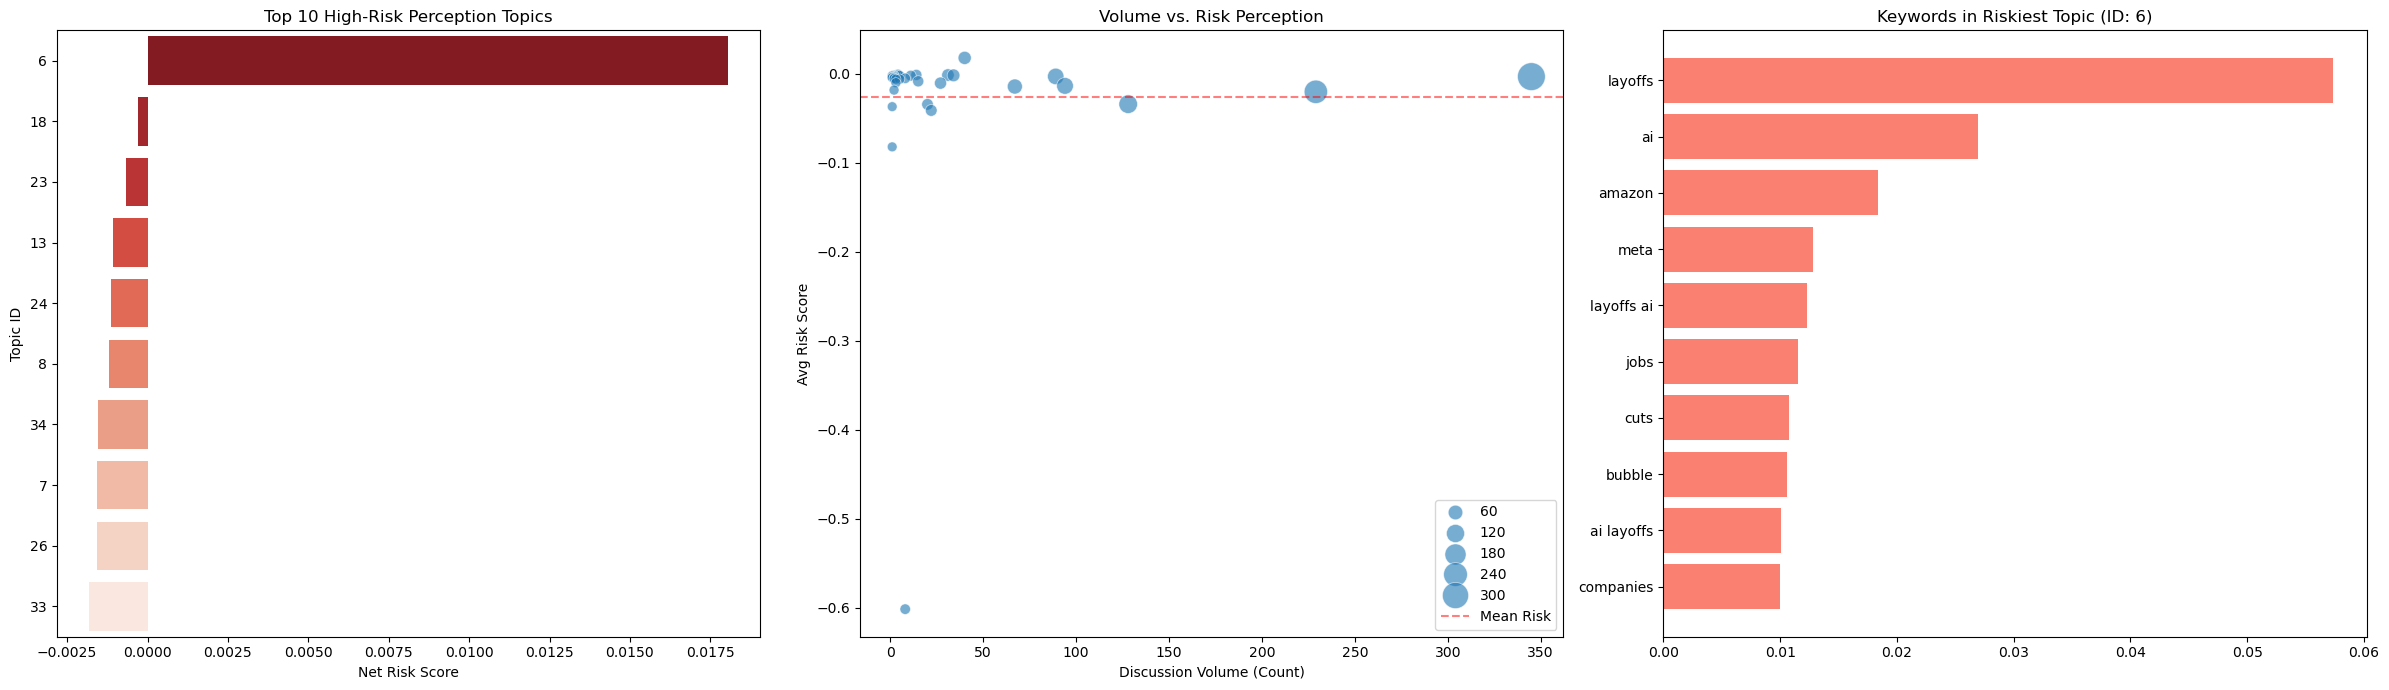

In [27]:
# ==========================================
# Step 1: Prepare Statistics
# ==========================================
# Group by 'topic' and calculate mean risk score and volume (count)
topic_stats = final_df.groupby('topic')['net_risk_score'].agg(['mean', 'count'])
topic_stats.columns = ['Avg_Risk_Score', 'Volume']

# Sort by risk score descending
topic_stats = topic_stats.sort_values('Avg_Risk_Score', ascending=False)

# Remove outlier topic -1 (noise) if it exists
if -1 in topic_stats.index:
    topic_stats_clean = topic_stats.drop(-1)
else:
    topic_stats_clean = topic_stats

# ==========================================
# Step 2: Plotting (3 Charts)
# ==========================================
fig, axes = plt.subplots(1, 3, figsize=(24, 7))

# --- Chart 1: The Risk Leaderboard ---
# Show top 10 topics with highest risk perception
top_10_risky = topic_stats_clean.head(10)
sns.barplot(
    x=top_10_risky['Avg_Risk_Score'], 
    y=top_10_risky.index.astype(str), 
    ax=axes[0], 
    palette='Reds_r'
)
axes[0].set_title('Top 10 High-Risk Perception Topics')
axes[0].set_xlabel('Net Risk Score')
axes[0].set_ylabel('Topic ID')

# --- Chart 2: Volume vs. Fear ---
# Scatter plot to see if high volume means high fear
sns.scatterplot(
    data=topic_stats_clean, 
    x='Volume', 
    y='Avg_Risk_Score', 
    size='Volume', 
    sizes=(50, 400), 
    alpha=0.6, 
    ax=axes[1]
)
axes[1].set_title('Volume vs. Risk Perception')
axes[1].set_xlabel('Discussion Volume (Count)')
axes[1].set_ylabel('Avg Risk Score')
# Add a horizontal line for the average risk
avg_risk_line = topic_stats_clean['Avg_Risk_Score'].mean()
axes[1].axhline(y=avg_risk_line, color='red', linestyle='--', alpha=0.5, label='Mean Risk')
axes[1].legend()

# --- Chart 3: Keywords in the Riskiest Topic ---
# Visualize keywords for the #1 riskiest topic
if not topic_stats_clean.empty:
    riskiest_topic_id = topic_stats_clean.index[0]
    
    # Get keywords from BERTopic model
    keywords = topic_model.get_topic(riskiest_topic_id) 

    if keywords:
        words = [k[0] for k in keywords[:10]] # Top 10 words
        scores = [k[1] for k in keywords[:10]]
        
        axes[2].barh(words, scores, color='salmon')
        axes[2].set_title(f'Keywords in Riskiest Topic (ID: {riskiest_topic_id})')
        axes[2].invert_yaxis() # Highest score at top
    else:
        axes[2].text(0.5, 0.5, 'No keywords found', ha='center')
else:
    axes[2].text(0.5, 0.5, 'No data available', ha='center')

plt.tight_layout()
plt.show()

In [22]:
avg_risk_per_topic = final_df.groupby('topic')['net_risk_score'].mean()
avg_risk_per_topic = avg_risk_per_topic.sort_values(ascending=False)
print(avg_risk_per_topic.head(5))

topic
6     0.018056
18   -0.000299
23   -0.000673
13   -0.001089
24   -0.001135
Name: net_risk_score, dtype: float64


In [ ]:

print("Generating readable labels for topics...")

# Create a dictionary to map Topic ID -> Topic Label
topic_id_to_label = {}

# Iterate through all topic IDs in your stats dataframe
for topic_id in topic_stats_clean.index:
    # Get the list of keywords for this topic
    keywords_list = topic_model.get_topic(topic_id)
    
    if keywords_list:
        # Extract the top 3 words (k[0] is the word)
        top_3_words = [k[0] for k in keywords_list[:3]]
        # Join them with a separator
        label = " | ".join(top_3_words)
    else:
        # Fallback if no keywords found
        label = f"Topic {topic_id}"
        
    # Store in dictionary
    topic_id_to_label[topic_id] = label

# Map the new labels to a new column 'Topic_Label'
topic_stats_clean['Topic_Label'] = topic_stats_clean.index.map(topic_id_to_label)

print("Labels generated! Preview of the first 5 rows:")
# Check what the new column looks like
print(topic_stats_clean[['Topic_Label', 'Avg_Risk_Score']].head())

Generating readable labels for topics...
Labels generated! Preview of the first 5 rows:
                                           Topic_Label  Avg_Risk_Score
topic                                                                 
6                                layoffs | ai | amazon        0.018056
18              aiart fantasy | fantasy jobs | fantasy       -0.000299
23                       media | social | social media       -0.000673
13               policecarlight ai | job alert | alert       -0.001089
24     custom | deepseekcoderv2latest | custom llmsjob       -0.001135


In [29]:
# ==========================================
# Step 1: Generate Readable Topic Labels
# ==========================================
print("Generating readable labels for topics...")

# Create a dictionary to map Topic ID -> Topic Label
topic_id_to_label = {}

# Iterate through all topic IDs in your stats dataframe
for topic_id in topic_stats_clean.index:
    # Get the list of keywords for this topic
    keywords_list = topic_model.get_topic(topic_id)
    
    if keywords_list:
        # Extract the top 3 words (k[0] is the word)
        top_3_words = [k[0] for k in keywords_list[:3]]
        # Join them with a separator
        label = " | ".join(top_3_words)
    else:
        # Fallback if no keywords found
        label = f"Topic {topic_id}"
        
    # Store in dictionary
    topic_id_to_label[topic_id] = label

# Map the new labels to a new column 'Topic_Label'
topic_stats_clean['Topic_Label'] = topic_stats_clean.index.map(topic_id_to_label)

print("Labels generated! Preview of the first 5 rows:")
# Check what the new column looks like
print(topic_stats_clean[['Topic_Label', 'Avg_Risk_Score']].head())

Generating readable labels for topics...
Labels generated! Preview of the first 5 rows:
                                           Topic_Label  Avg_Risk_Score
topic                                                                 
6                                layoffs | ai | amazon        0.018056
18              aiart fantasy | fantasy jobs | fantasy       -0.000299
23                       media | social | social media       -0.000673
13               policecarlight ai | job alert | alert       -0.001089
24     custom | deepseekcoderv2latest | custom llmsjob       -0.001135


Plot saved as: job_filtered_graphs/risk_perception_analysis_labeled.png


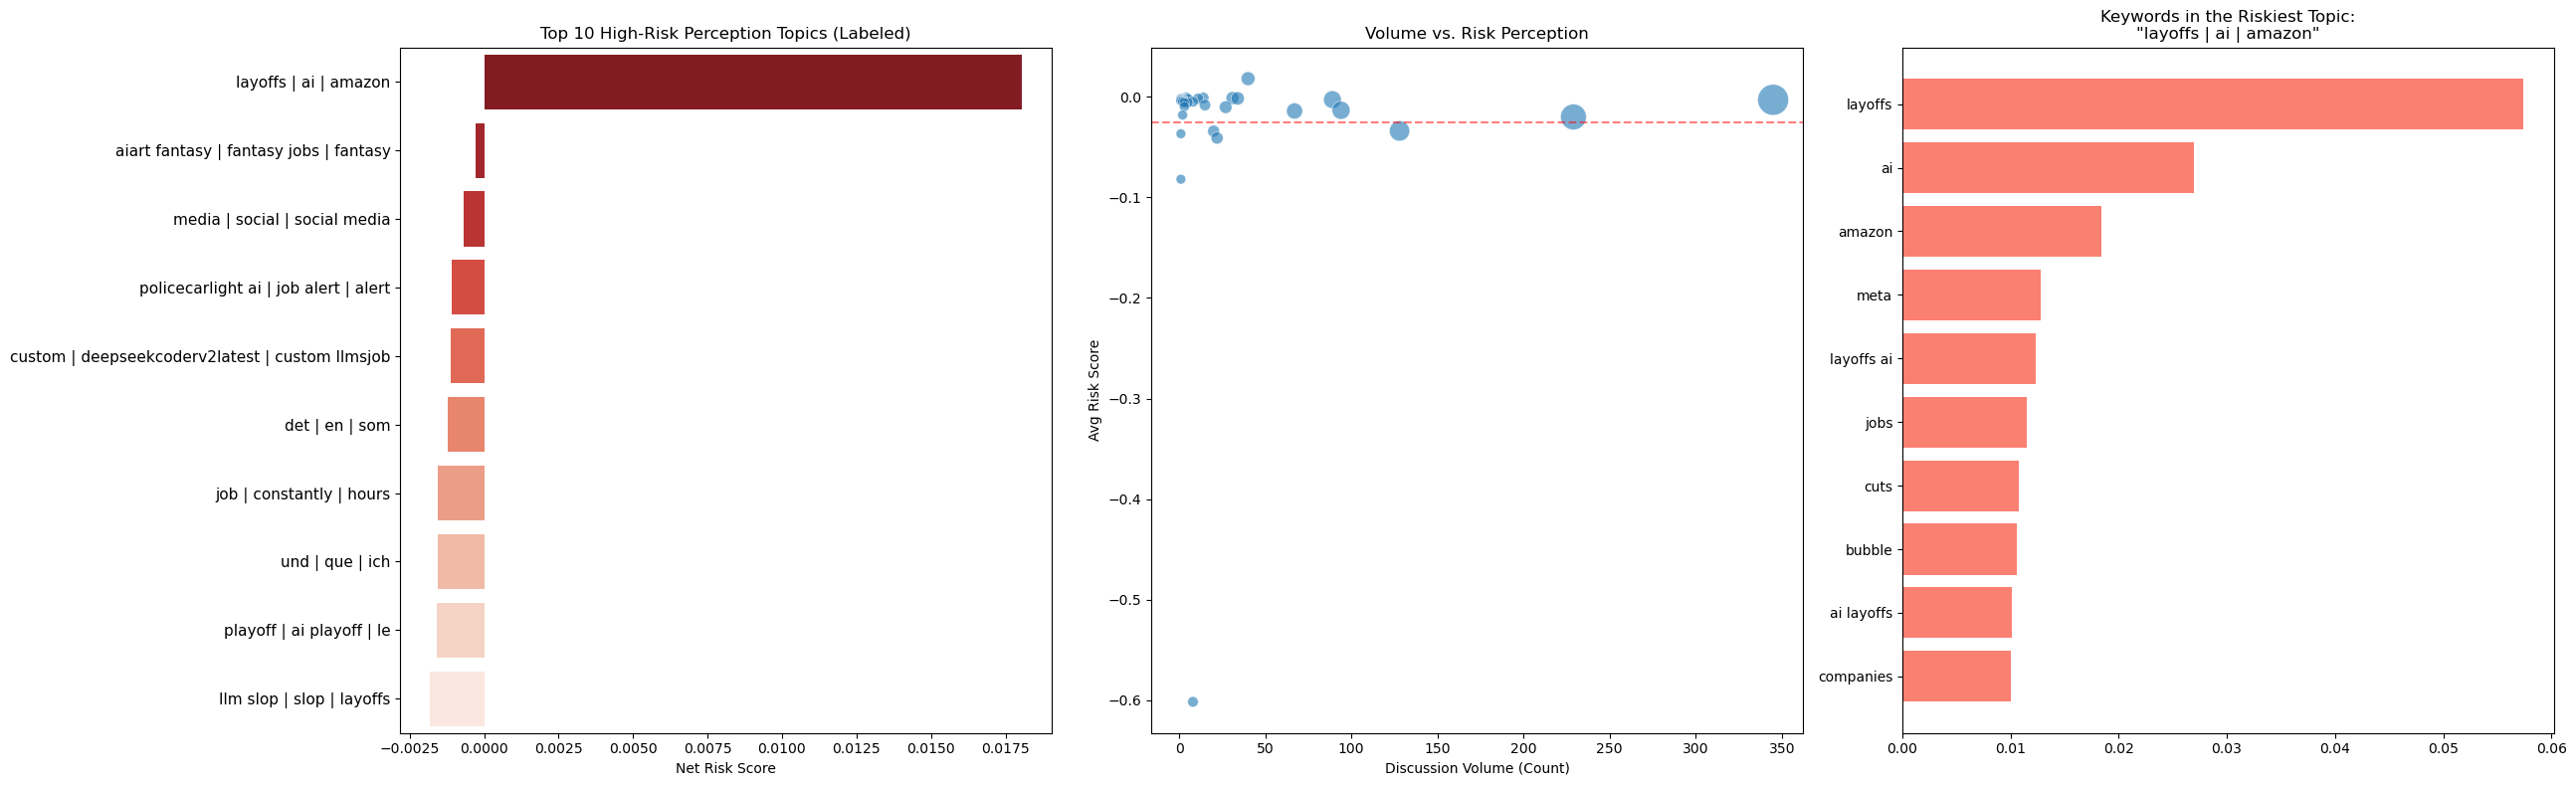

In [30]:
# ==========================================
# Step 2: Re-plot with Readable Labels
# ==========================================
fig, axes = plt.subplots(1, 3, figsize=(26, 8)) # Made it slightly wider for text

# --- Chart 1: The Risk Leaderboard (Labeled) ---
top_10_risky = topic_stats_clean.head(10)

sns.barplot(
    x=top_10_risky['Avg_Risk_Score'],
    # KEY CHANGE: Use the new readable label for Y-axis
    y=top_10_risky['Topic_Label'], 
    ax=axes[0],
    palette='Reds_r'
)
axes[0].set_title('Top 10 High-Risk Perception Topics (Labeled)')
axes[0].set_xlabel('Net Risk Score')
axes[0].tick_params(axis='y', labelsize=11) # Increase font size for readability
axes[0].set_ylabel('') # Remove redundant Y-axis label


# --- Chart 2: Volume vs. Risk (Same as before) ---
sns.scatterplot(
    data=topic_stats_clean, 
    x='Volume', 
    y='Avg_Risk_Score', 
    size='Volume', 
    sizes=(50, 500), 
    alpha=0.6, 
    ax=axes[1], 
    legend=False
)
axes[1].set_title('Volume vs. Risk Perception')
axes[1].set_xlabel('Discussion Volume (Count)')
axes[1].set_ylabel('Avg Risk Score')
# Add mean line
axes[1].axhline(y=topic_stats_clean['Avg_Risk_Score'].mean(), color='red', linestyle='--', alpha=0.5, label='Mean Risk')


# --- Chart 3: Keywords in the Riskiest Topic (Labeled) ---
if not topic_stats_clean.empty:
    # Get ID and Label of the #1 risky topic
    riskiest_topic_id = topic_stats_clean.index[0]
    riskiest_topic_label = topic_stats_clean.iloc[0]['Topic_Label']
    
    keywords = topic_model.get_topic(riskiest_topic_id) 
    if keywords:
        words = [k[0] for k in keywords[:10]]
        scores = [k[1] for k in keywords[:10]]
        axes[2].barh(words, scores, color='salmon')
        # KEY CHANGE: Add topic name to title
        axes[2].set_title(f'Keywords in the Riskiest Topic:\n"{riskiest_topic_label}"')
        axes[2].invert_yaxis()
    else:
        axes[2].text(0.5, 0.5, 'No keywords found', ha='center')

plt.tight_layout()

# Save with high DPI and white background
output_dir = "job_filtered_graphs"
os.makedirs(output_dir, exist_ok=True)
save_path = os.path.join(output_dir, "risk_perception_analysis_labeled.png")
plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
print(f"Plot saved as: {save_path}")  
plt.show()

   Topic  Count                                            Name  \
0     -1   4832                          -1_ai_job_jobs_chatgpt   
1      0   2157                           0_ai_jobs_job_chatgpt   
2      1   1272                             1_llm_job_llms_like   
3      2    778                 2_chatgpt_job_using chatgpt_use   
4      3    584            3_openai_platform_jobs platform_jobs   
5      4    533  4_loudspeaker_link_jobalert_jobalert jobsearch   
6      5    451   5_gemini_job_gemini hiring_loudspeaker gemini   
7      6    288                        6_layoffs_ai_amazon_meta   
8      7    247                               7_und_que_ich_die   
9      8    176                                8_det_en_som_att   

                        CustomName  \
0                   -1_Outliers_噪音   
1                    0_ai_jobs_job   
2                   1_llm_job_llms   
3      2_chatgpt_job_using chatgpt   
4  3_openai_platform_jobs platform   
5      4_loudspeaker_link_jobalert

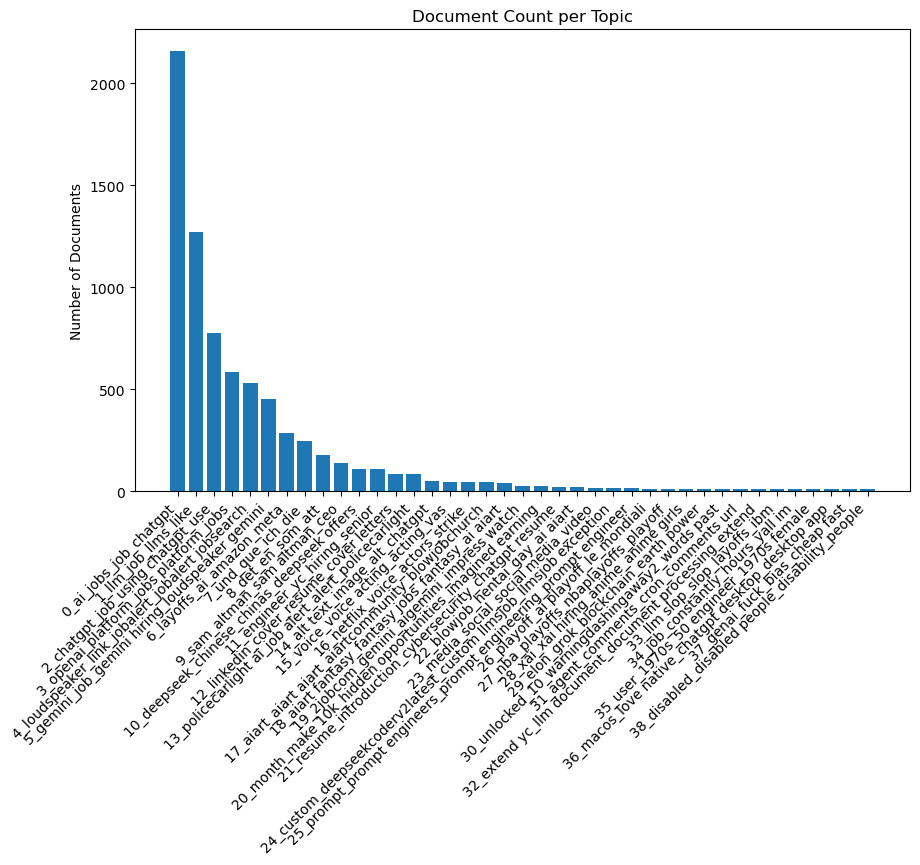

In [31]:
# 1️⃣ Get topic overview
topic_info = topic_model.get_topic_info()
print(topic_info.head(10))  # Print top 10 topics

# 2️⃣ Plot topic counts (excluding noise topic -1)
plt.figure(figsize=(10,6))
topic_info_filtered = topic_info[topic_info['Topic'] != -1]  # Exclude noise
plt.bar(topic_info_filtered['Name'], topic_info_filtered['Count'])
plt.xticks(rotation=45, ha='right')
plt.ylabel('Number of Documents')
plt.title('Document Count per Topic')
save_path = os.path.join(output_dir, 'topic_document_counts.png')
plt.savefig(save_path, bbox_inches='tight', dpi=300)
plt.show()

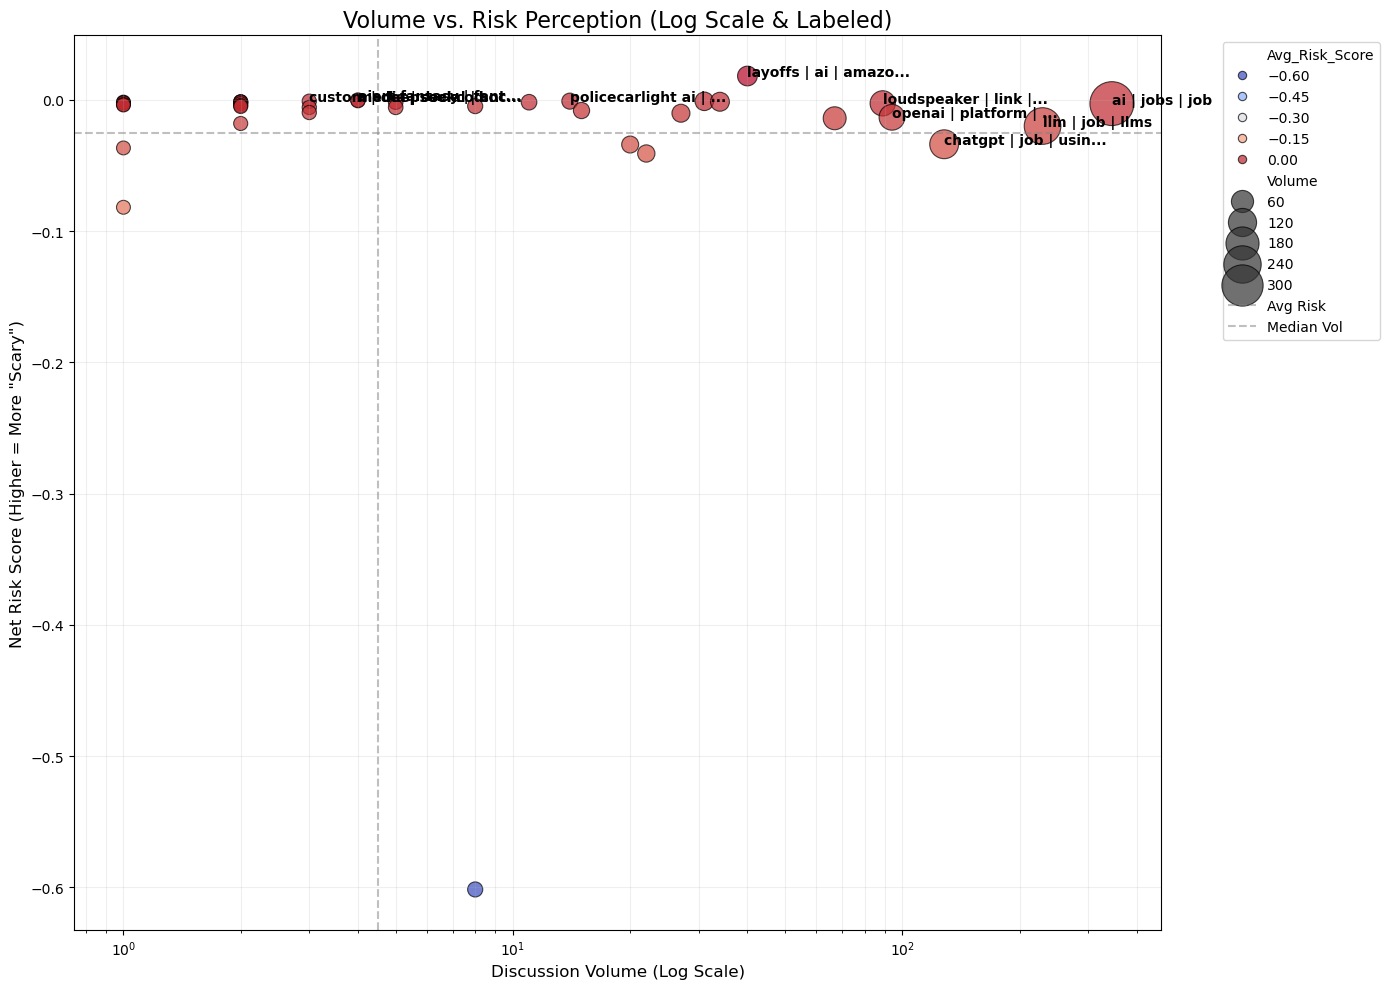

In [32]:
# Set up the figure size - make it large and clear
plt.figure(figsize=(14, 10))

# 1. Create the scatter plot with more visual dimensions
# Hue (Color): Based on Risk Score (Red=Scary, Blue=Calm)
# Size: Based on Volume (Bigger=More Talked About)
scatter = sns.scatterplot(
    data=topic_stats_clean, 
    x='Volume', 
    y='Avg_Risk_Score', 
    size='Volume', 
    hue='Avg_Risk_Score',      # Color by risk
    palette='coolwarm',        # Red-Blue diverging palette
    sizes=(100, 1000),         # Make bubbles bigger generally
    alpha=0.7,                 # Transparency
    edgecolor='black'          # Add border to bubbles
)

# 2. KEY FIX: Use Logarithmic Scale for X-axis
# This spreads out the "squashed" points on the left
plt.xscale('log')

# 3. Add Reference Lines (Quadrants)
# Mean Risk Line
plt.axhline(y=topic_stats_clean['Avg_Risk_Score'].mean(), color='grey', linestyle='--', alpha=0.5, label='Avg Risk')
# Median Volume Line
plt.axvline(x=topic_stats_clean['Volume'].median(), color='grey', linestyle='--', alpha=0.5, label='Median Vol')

# 4. Add Text Labels (Smart Annotation)
# We don't want to label everything (too messy). 
# Let's label: Top 5 Riskiest + Top 5 Highest Volume
texts = []

# Sort by Risk (High to Low) and take top 5
top_risky = topic_stats_clean.sort_values('Avg_Risk_Score', ascending=False).head(5)
# Sort by Volume (High to Low) and take top 5
top_vol = topic_stats_clean.sort_values('Volume', ascending=False).head(5)

# Combine them and remove duplicates
points_to_label = pd.concat([top_risky, top_vol]).drop_duplicates()

for idx, row in points_to_label.iterrows():
    # Get the label (Shorten it if it's too long)
    label_text = row['Topic_Label']
    if len(label_text) > 20:
        label_text = label_text[:20] + "..."
        
    plt.text(
        x=row['Volume'], 
        y=row['Avg_Risk_Score'], 
        s=label_text, 
        fontsize=10,
        weight='bold',
        color='black'
    )

# 5. Final Polish
plt.title('Volume vs. Risk Perception (Log Scale & Labeled)', fontsize=16)
plt.xlabel('Discussion Volume (Log Scale)', fontsize=12)
plt.ylabel('Net Risk Score (Higher = More "Scary")', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Move legend outside
plt.grid(True, which="both", ls="-", alpha=0.2)

plt.tight_layout()
save_path = os.path.join(output_dir, 'improved_scatter_plot.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

Fix complete! final_df now contains the 'Topic_Label' column.


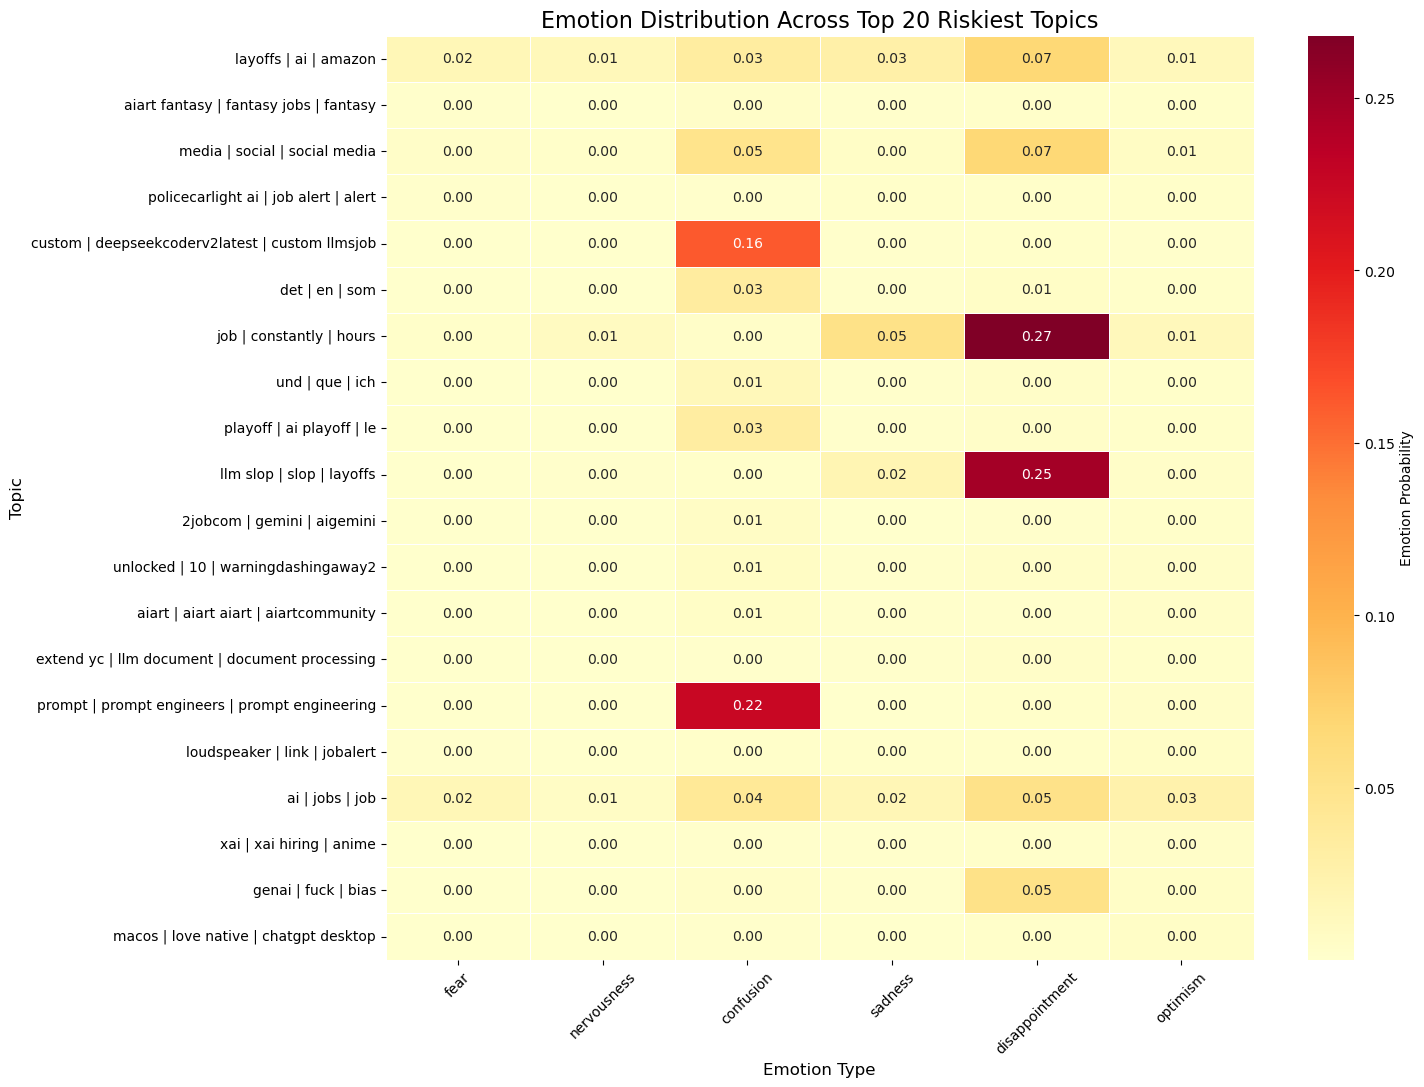

In [33]:
#Topic ID -> Topic Label
topic_id_to_label = {}

for topic_id in set(final_df['topic']):
    keywords_list = topic_model.get_topic(topic_id)
    
    if keywords_list:
        top_3_words = [k[0] for k in keywords_list[:3]]
        label = " | ".join(top_3_words)
    else:
        label = f"Topic {topic_id}"
        
    topic_id_to_label[topic_id] = label

final_df['Topic_Label'] = final_df['topic'].map(topic_id_to_label)
print("Fix complete! final_df now contains the 'Topic_Label' column.")


# ==========================================
# 2. Prepare Data
# ==========================================

heatmap_emotions = ['fear', 'nervousness', 'confusion', 'sadness', 'disappointment', 'optimism']


topic_emotion_stats = final_df.groupby('Topic_Label')[heatmap_emotions + ['net_risk_score']].mean()

topic_emotion_stats = topic_emotion_stats.sort_values('net_risk_score', ascending=False).head(20)

plot_data = topic_emotion_stats.drop(columns=['net_risk_score'])


# ==========================================
# 3. Draw Heatmap
# ==========================================

plt.figure(figsize=(14, 12))

sns.heatmap(
    plot_data, 
    annot=True,       
    fmt=".2f",        
    cmap='YlOrRd',   
    linewidths=.5,
    cbar_kws={'label': 'Emotion Probability'} 
)

plt.title('Emotion Distribution Across Top 20 Riskiest Topics', fontsize=16)
plt.xlabel('Emotion Type', fontsize=12)
plt.ylabel('Topic', fontsize=12)
plt.xticks(rotation=45)

save_path = os.path.join(output_dir, 'emotion_distribution_heatmap.png') 
plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')

plt.show()

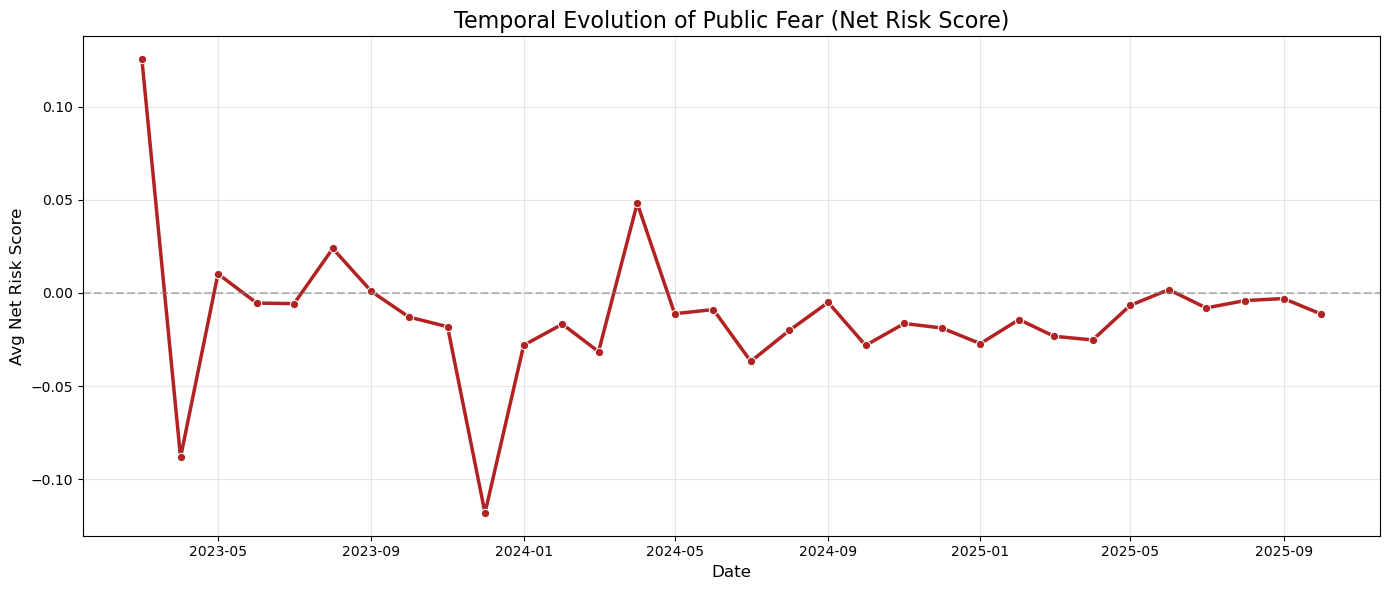

In [34]:
# Convert 'created_at' to datetime objects
# errors='coerce' will turn unparseable dates into NaT (Not a Time) so it doesn't crash
final_df['created_at'] = pd.to_datetime(final_df['created_at'], errors='coerce')

# Remove rows with invalid dates
time_df = final_df.dropna(subset=['created_at']).copy()

# Extract Year-Month for grouping (e.g., "2023-01")
time_df['year_month'] = time_df['created_at'].dt.to_period('M')

# ==========================================
# 2. Calculate Monthly Trends
# ==========================================
# Calculate average risk score per month
monthly_risk = time_df.groupby('year_month')['net_risk_score'].mean().reset_index()
# Convert back to timestamp for plotting
monthly_risk['timestamp'] = monthly_risk['year_month'].dt.to_timestamp()

# ==========================================
# 3. Plotting: General Fear Trend
# ==========================================
plt.figure(figsize=(14, 6))

sns.lineplot(data=monthly_risk, x='timestamp', y='net_risk_score', marker='o', linewidth=2.5, color='firebrick')

plt.title('Temporal Evolution of Public Fear (Net Risk Score)', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Avg Net Risk Score', fontsize=12)
plt.grid(True, alpha=0.3)

# Add a reference line for neutral risk
plt.axhline(0, color='grey', linestyle='--', alpha=0.5)

plt.tight_layout()
save_path = os.path.join(output_dir, 'temporal_fear_trend.png')
plt.savefig(save_path, dpi=300)
plt.show()

Spearman Correlation Matrix:
                net_risk_score  like_count  repost_count
net_risk_score        1.000000   -0.045223     -0.001097
like_count           -0.045223    1.000000      0.473607
repost_count         -0.001097    0.473607      1.000000


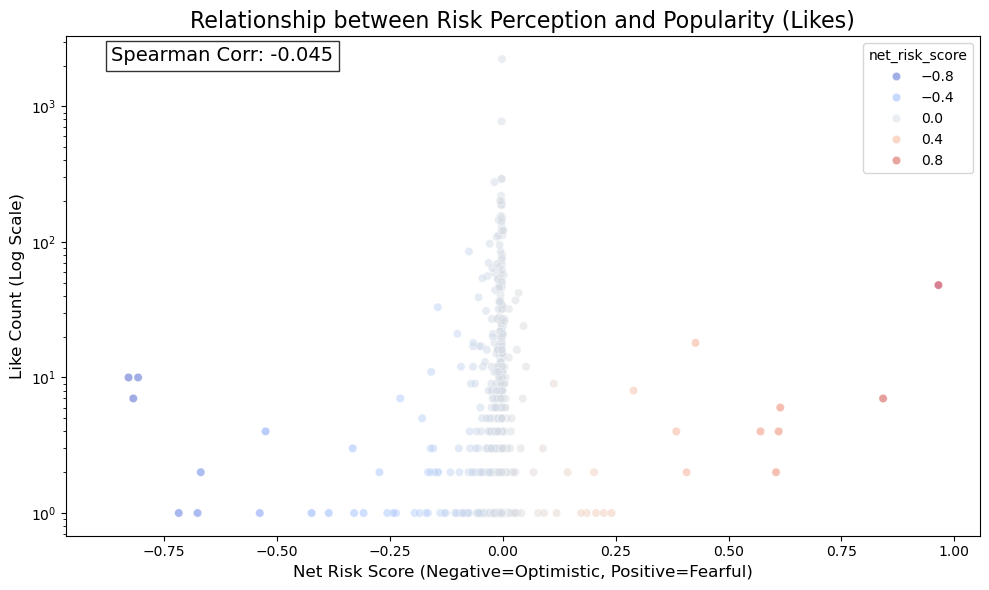

In [35]:
# 1. Correlation Calculation
# We use Spearman correlation because like counts are usually not normally distributed (power law)
correlation = final_df[['net_risk_score', 'like_count', 'repost_count']].corr(method='spearman')

print("Spearman Correlation Matrix:")
print(correlation)

# 2. Visualization
plt.figure(figsize=(10, 6))

# We use log scale for likes because usually a few posts have huge likes
sns.scatterplot(
    data=final_df, 
    x='net_risk_score', 
    y='like_count', 
    alpha=0.5, 
    hue='net_risk_score', 
    palette='coolwarm'
)

plt.yscale('log') # Log scale for Y-axis (Likes)
plt.title('Relationship between Risk Perception and Popularity (Likes)', fontsize=16)
plt.xlabel('Net Risk Score (Negative=Optimistic, Positive=Fearful)', fontsize=12)
plt.ylabel('Like Count (Log Scale)', fontsize=12)

# Add text annotation for the result
corr_value = correlation.loc['net_risk_score', 'like_count']
plt.text(0.05, 0.95, f'Spearman Corr: {corr_value:.3f}', transform=plt.gca().transAxes, fontsize=14, bbox=dict(facecolor='white', alpha=0.8))

plt.tight_layout()
save_path = os.path.join(output_dir, 'fear_engagement_correlation.png')
plt.savefig(save_path, dpi=300)
plt.show()

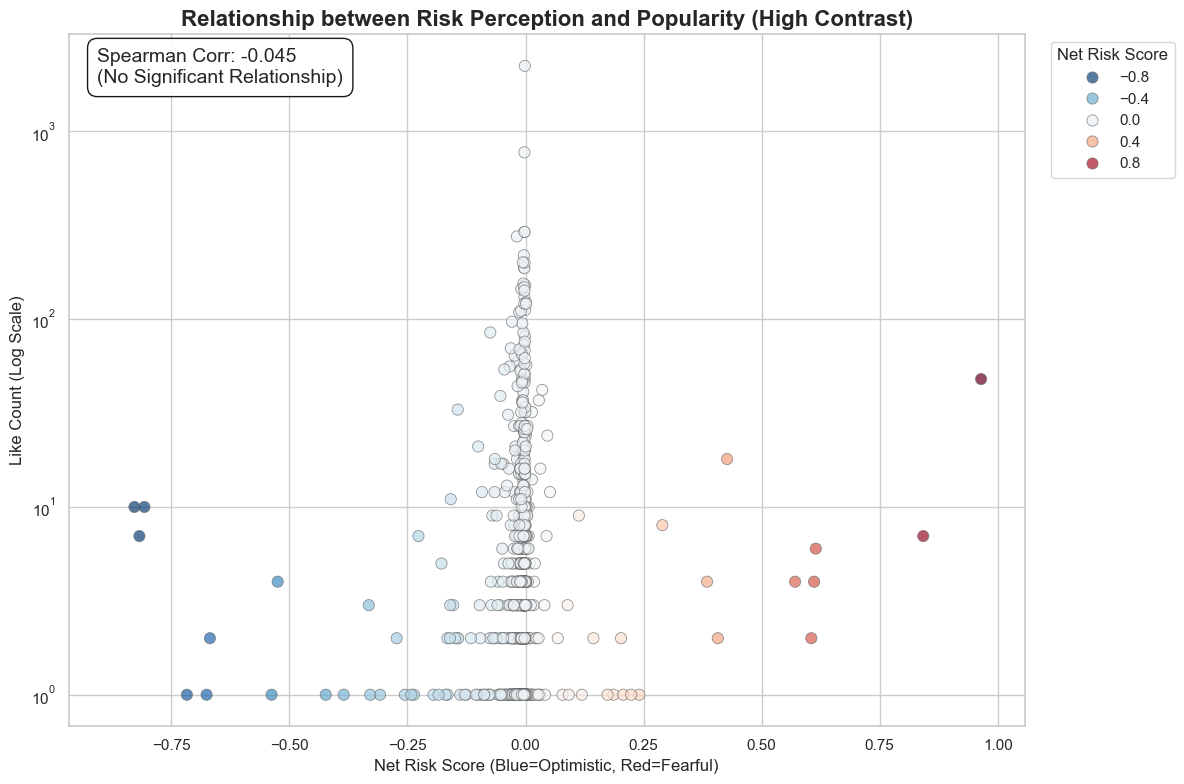

In [36]:

sns.set_theme(style="whitegrid")

plt.figure(figsize=(12, 8))

correlation = final_df[['net_risk_score', 'like_count']].corr(method='spearman')
corr_value = correlation.loc['net_risk_score', 'like_count']


scatter = sns.scatterplot(
    data=final_df, 
    x='net_risk_score', 
    y='like_count', 
    hue='net_risk_score', 
    palette='RdBu_r',      
    alpha=0.7,             
    edgecolor='dimgrey',   
    linewidth=0.6,         
    s=65                   
)


plt.yscale('log')


plt.title('Relationship between Risk Perception and Popularity (High Contrast)', fontsize=16, fontweight='bold')
plt.xlabel('Net Risk Score (Blue=Optimistic, Red=Fearful)', fontsize=12)
plt.ylabel('Like Count (Log Scale)', fontsize=12)


plt.text(0.03, 0.93, f'Spearman Corr: {corr_value:.3f}\n(No Significant Relationship)', 
         transform=plt.gca().transAxes, fontsize=14, 
         bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.5', alpha=0.9))


plt.legend(title='Net Risk Score', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
save_path = os.path.join(output_dir, 'fear_engagement_high_contrast.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()

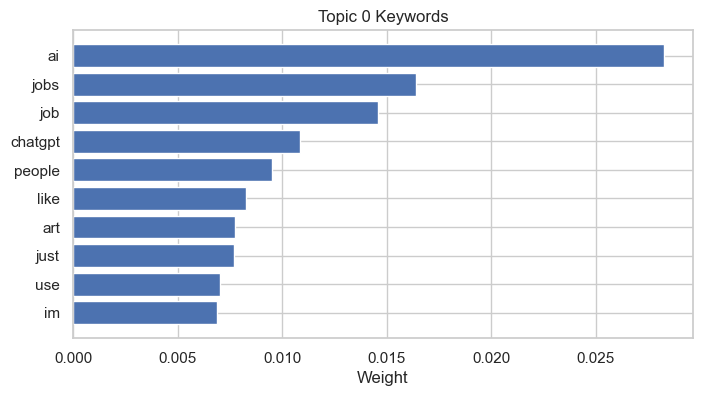

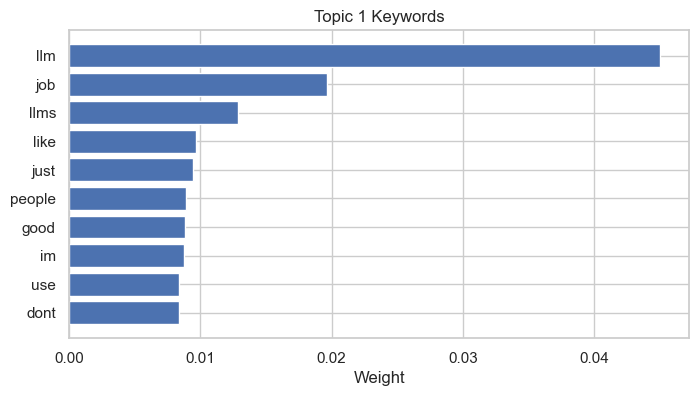

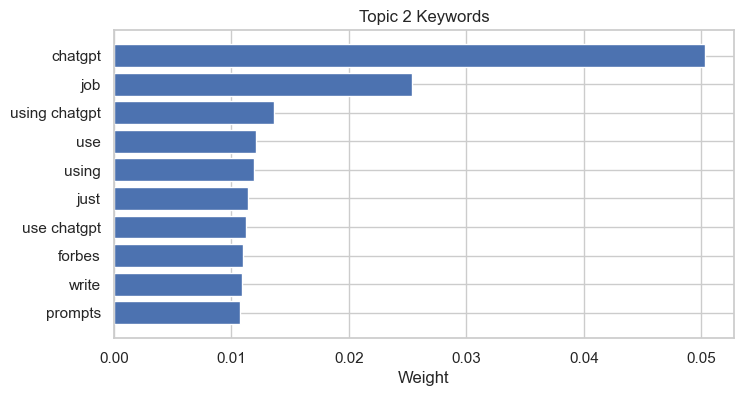

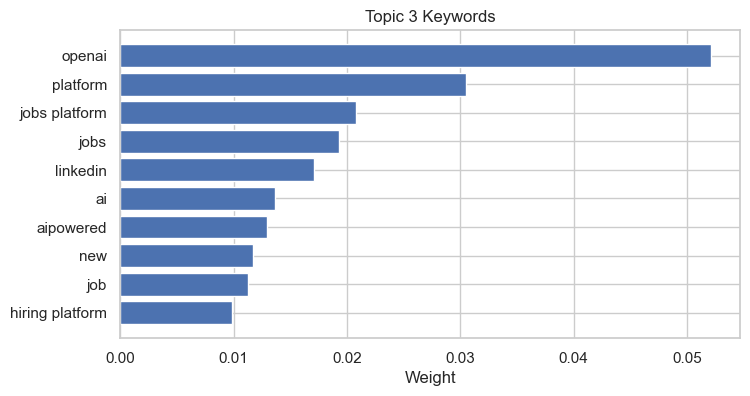

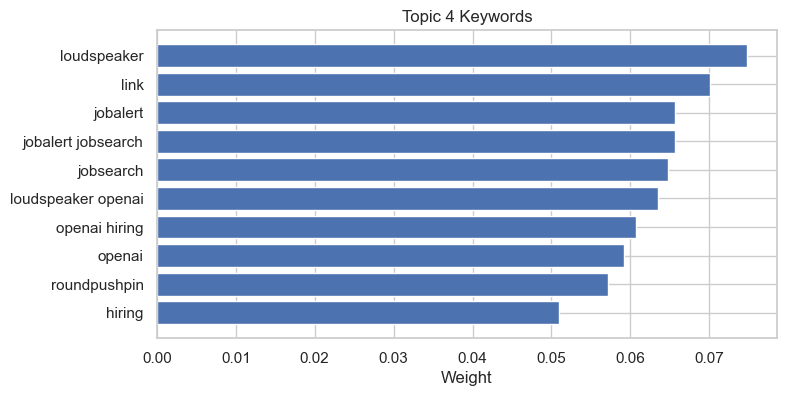

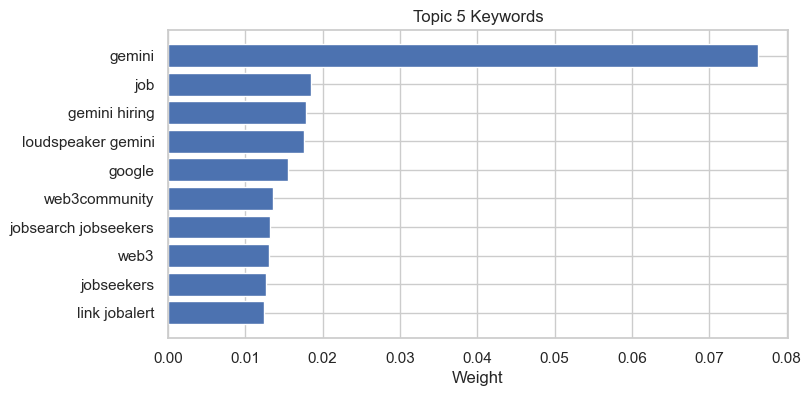

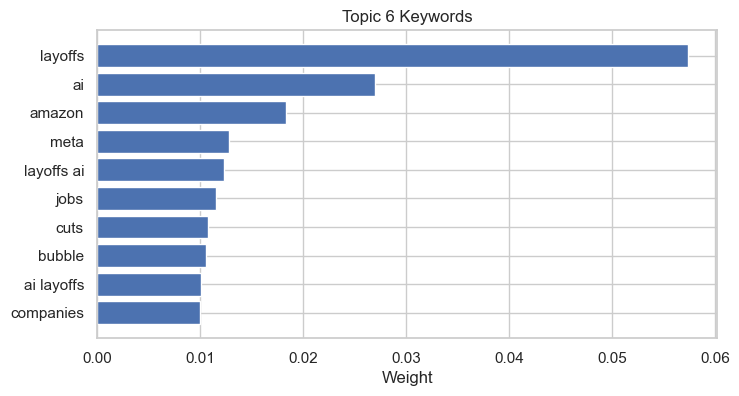

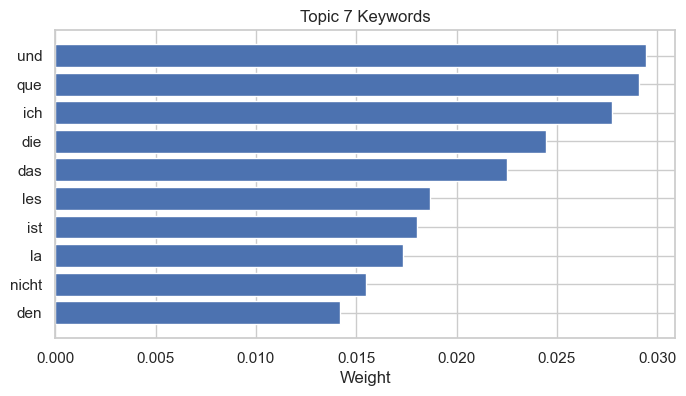

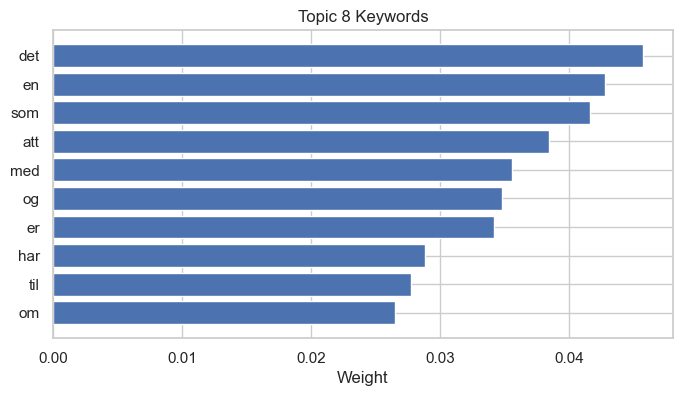

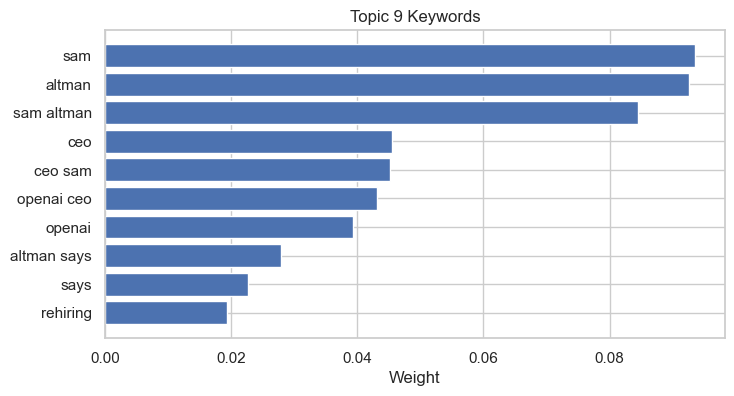

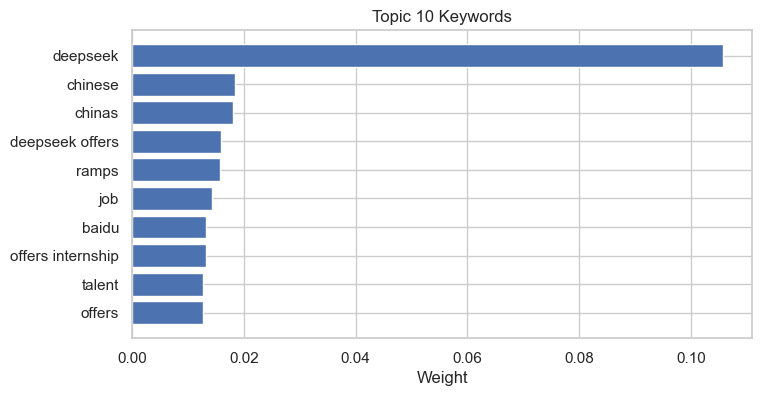

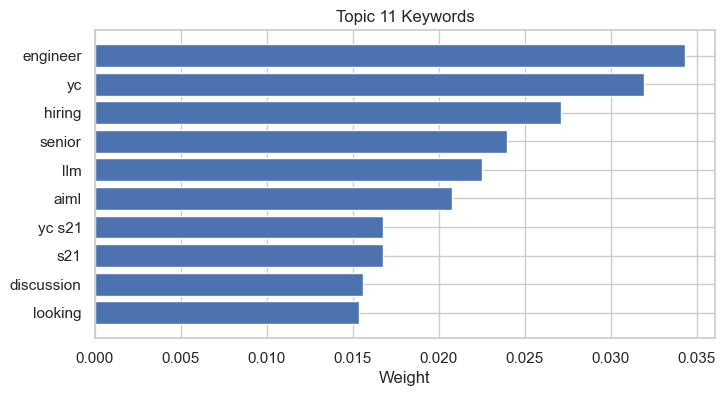

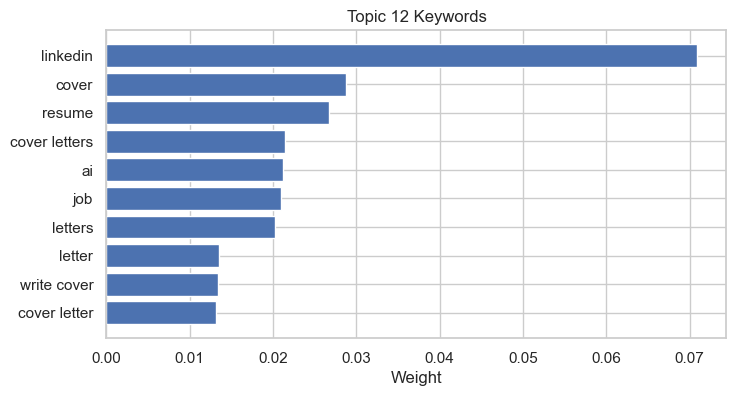

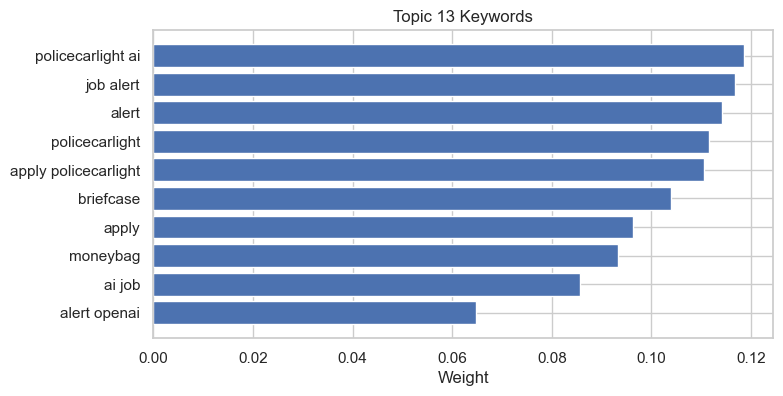

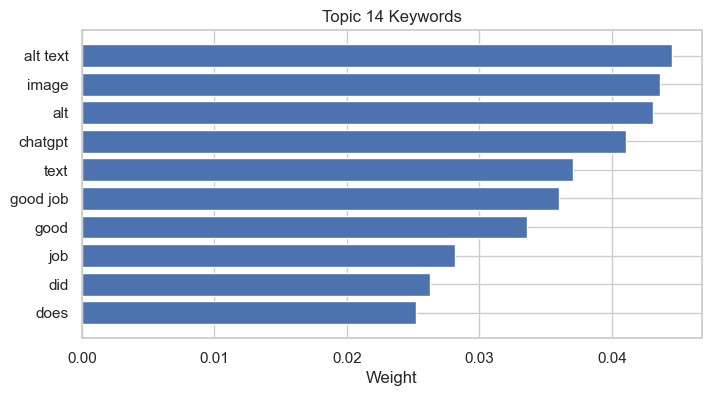

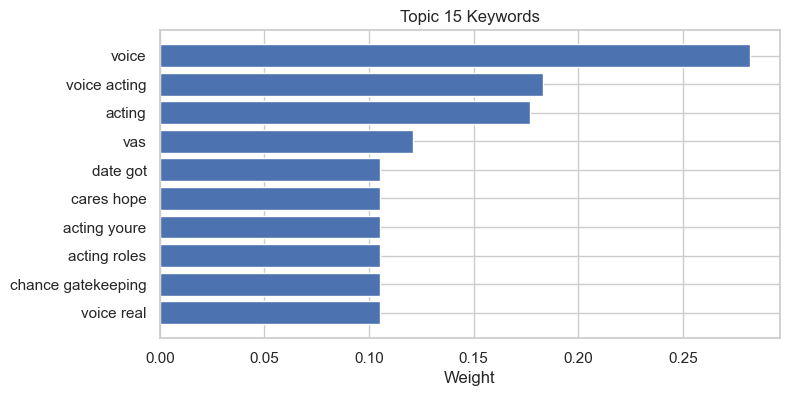

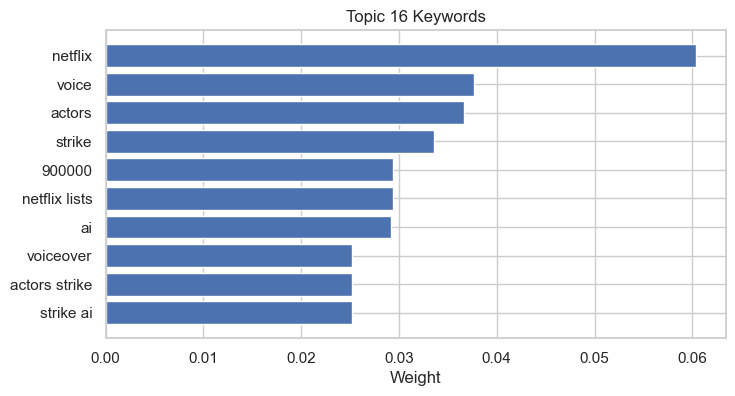

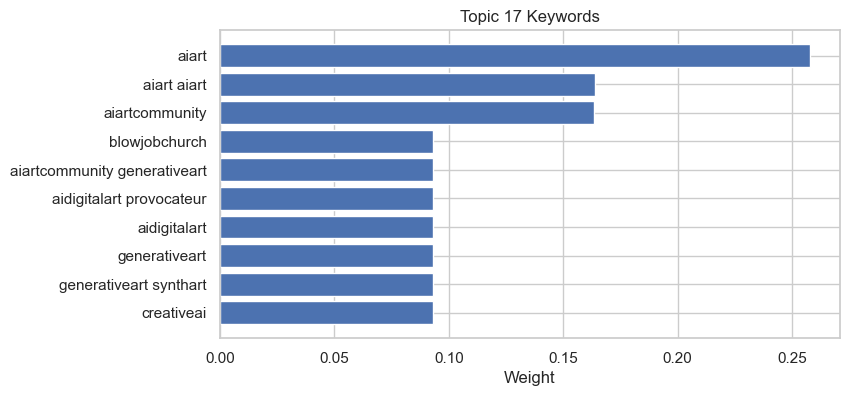

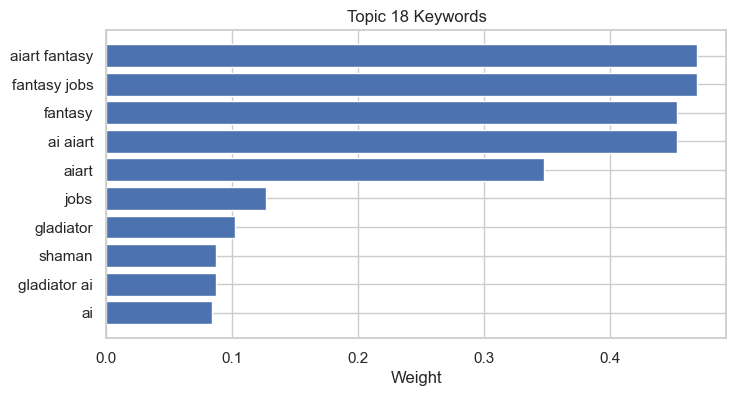

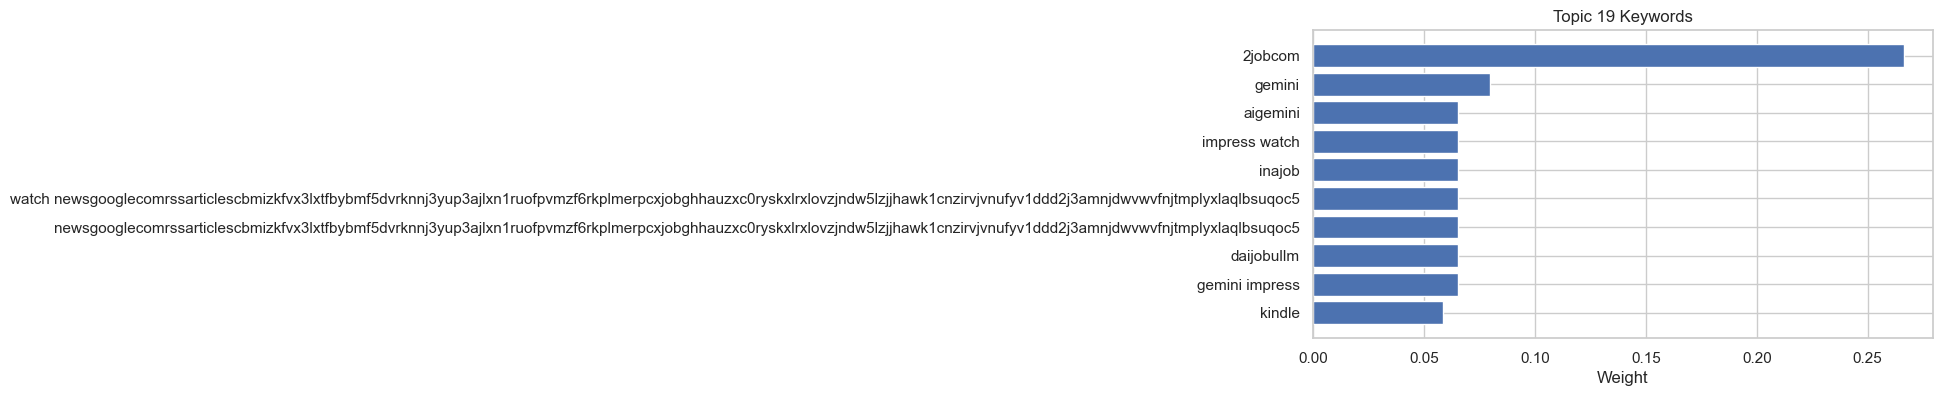

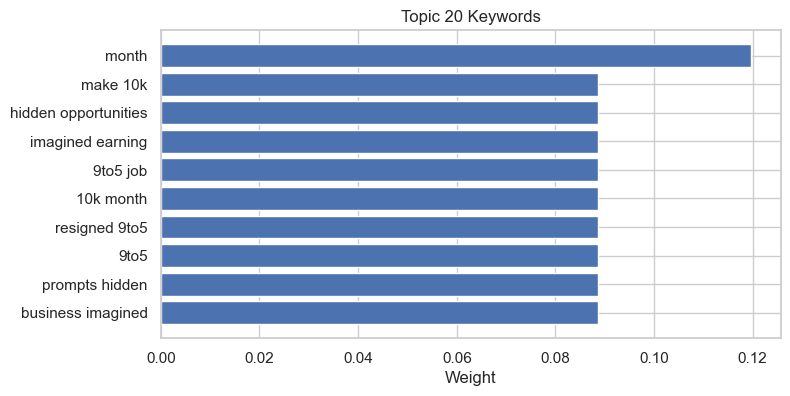

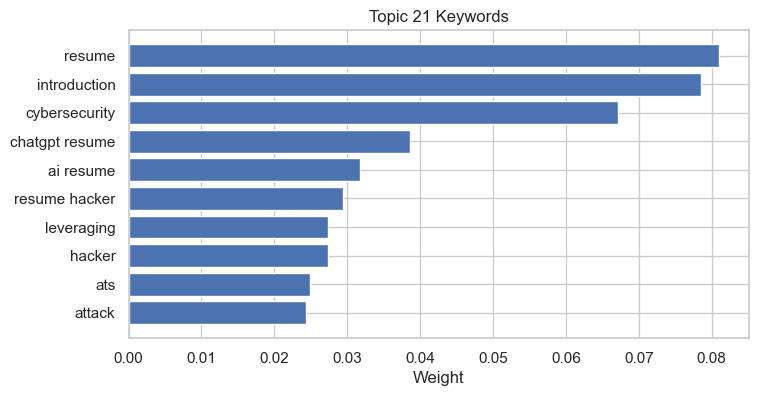

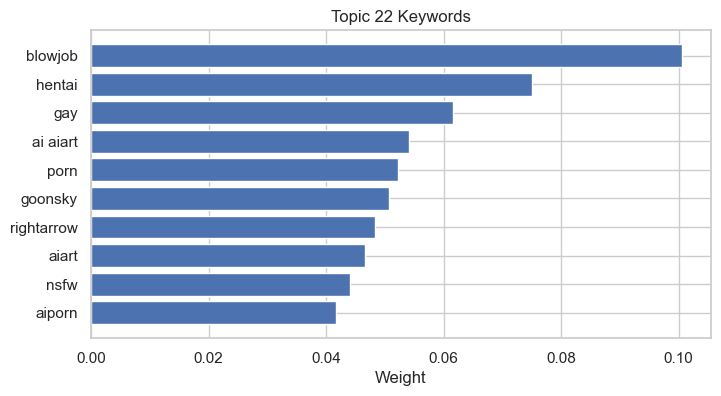

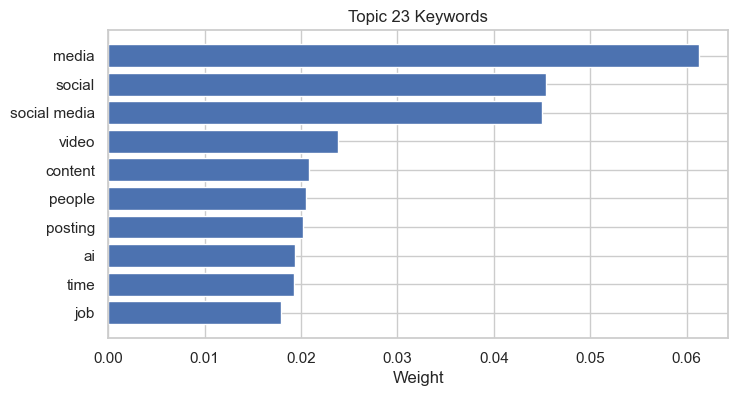

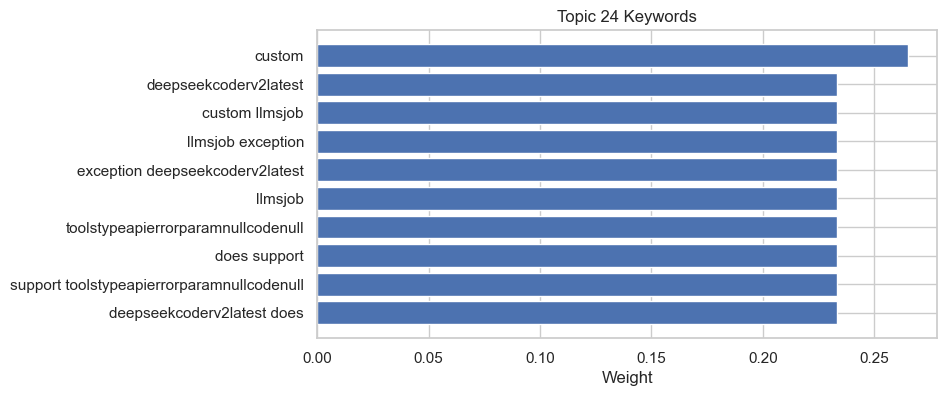

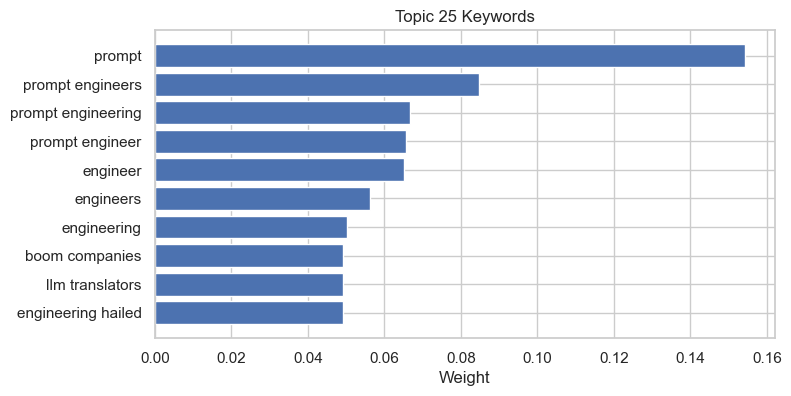

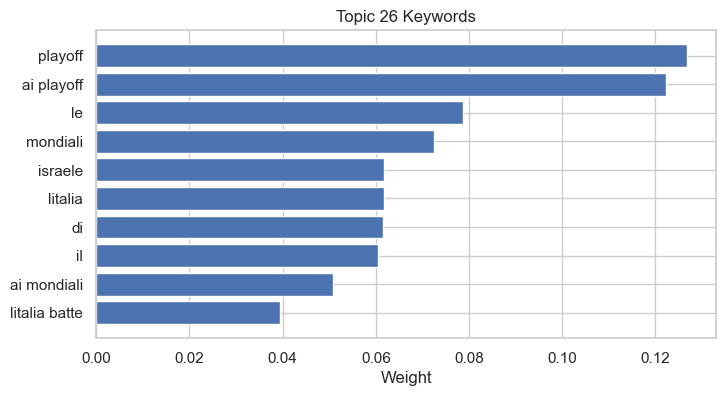

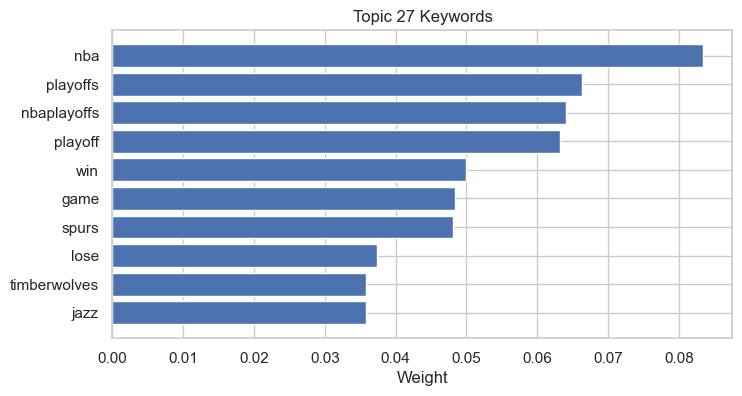

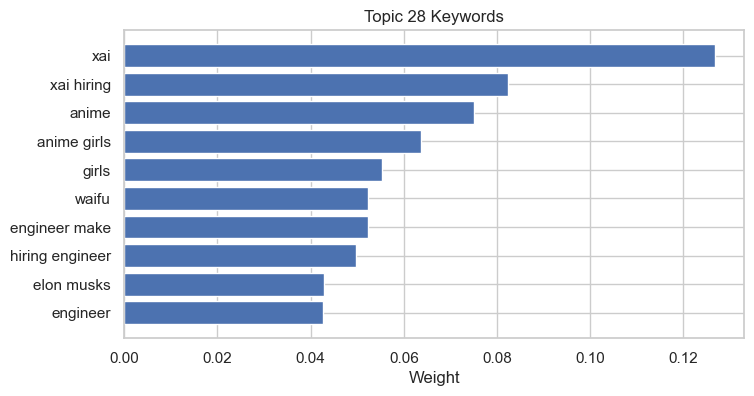

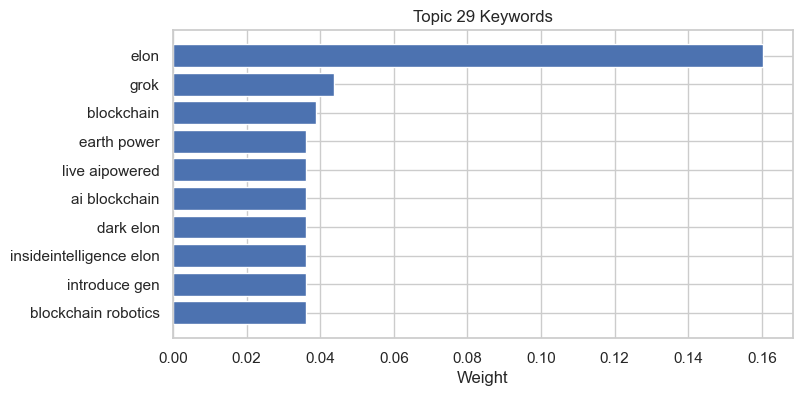

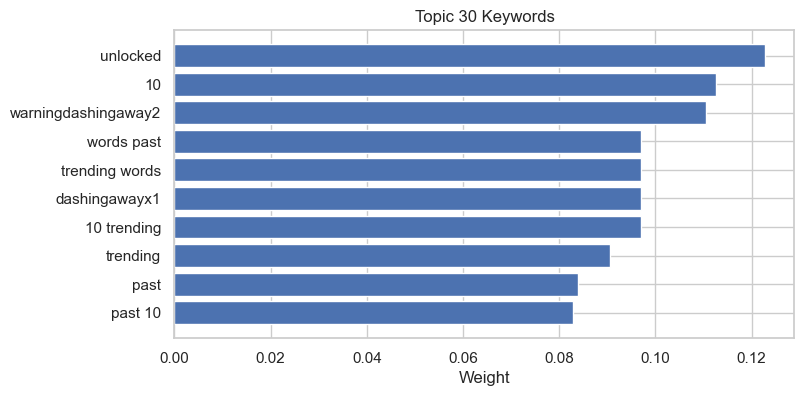

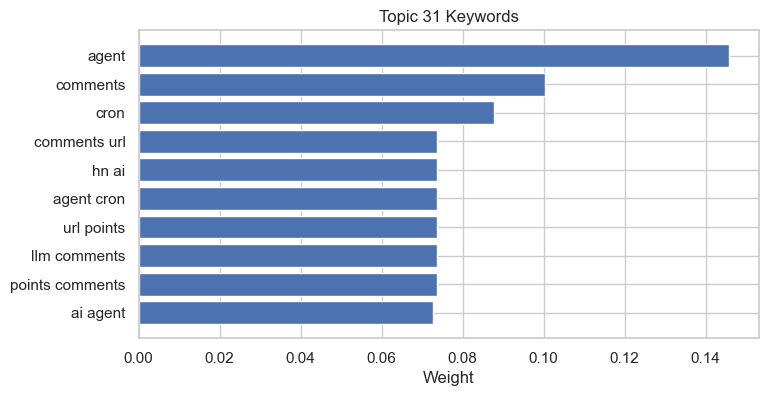

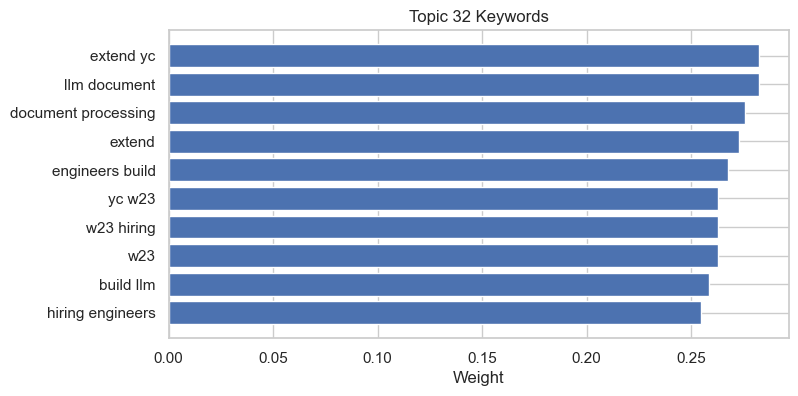

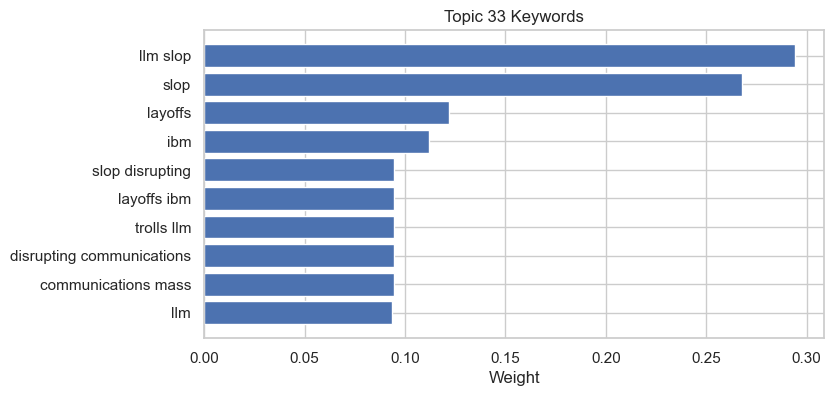

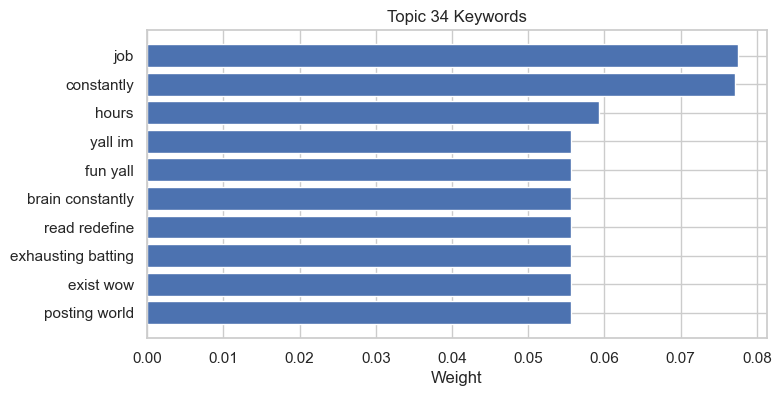

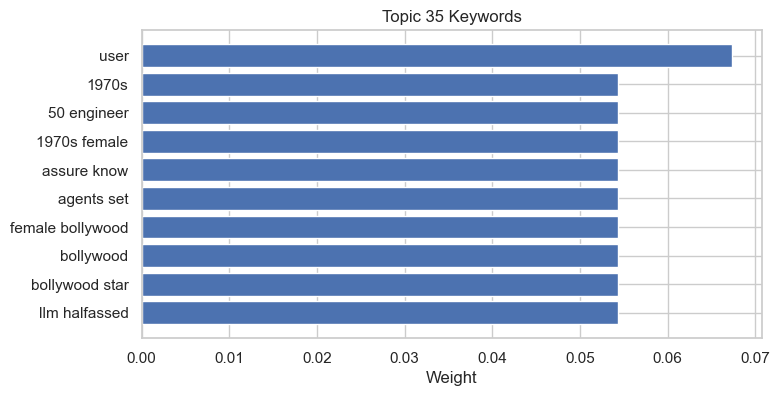

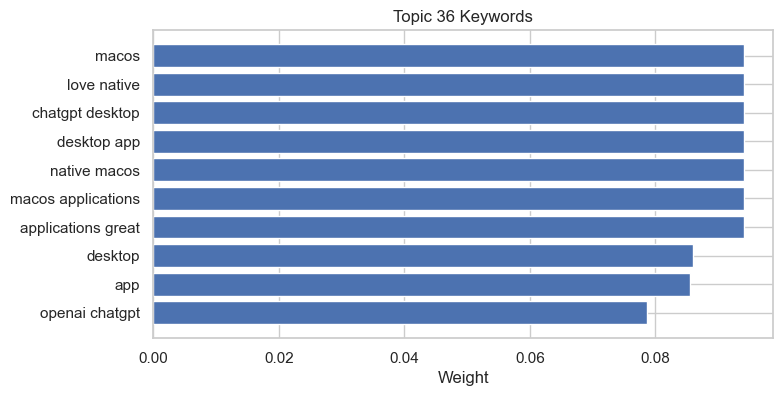

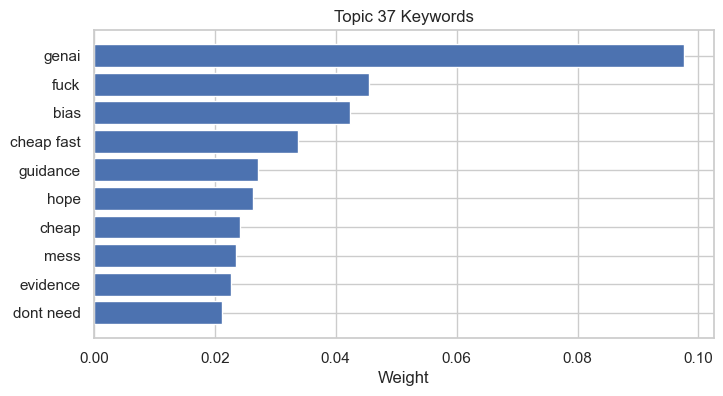

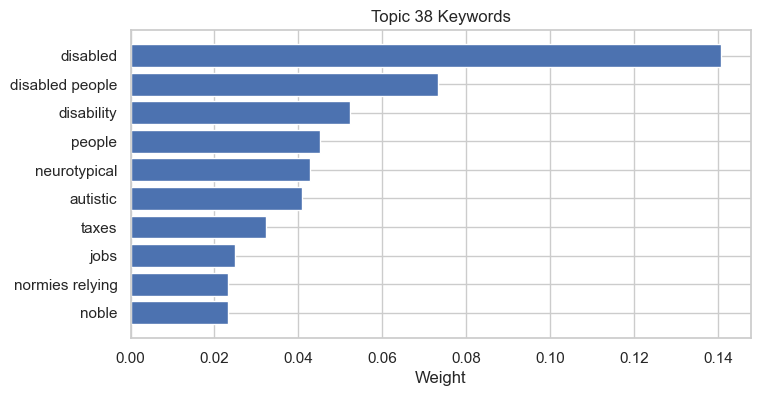

In [37]:
# 3️⃣ Visualize topic similarity map
topic_model.visualize_topics()

# 4️⃣ Plot top keywords for each topic
for topic_num in topic_info_filtered['Topic'].tolist():
    words = topic_model.get_topic(topic_num)
    if words:
        word_labels, word_scores = zip(*words)
        plt.figure(figsize=(8,4))
        plt.barh(word_labels, word_scores)
        plt.title(f"Topic {topic_num} Keywords")
        plt.gca().invert_yaxis()
        plt.xlabel('Weight')
        plt.show()

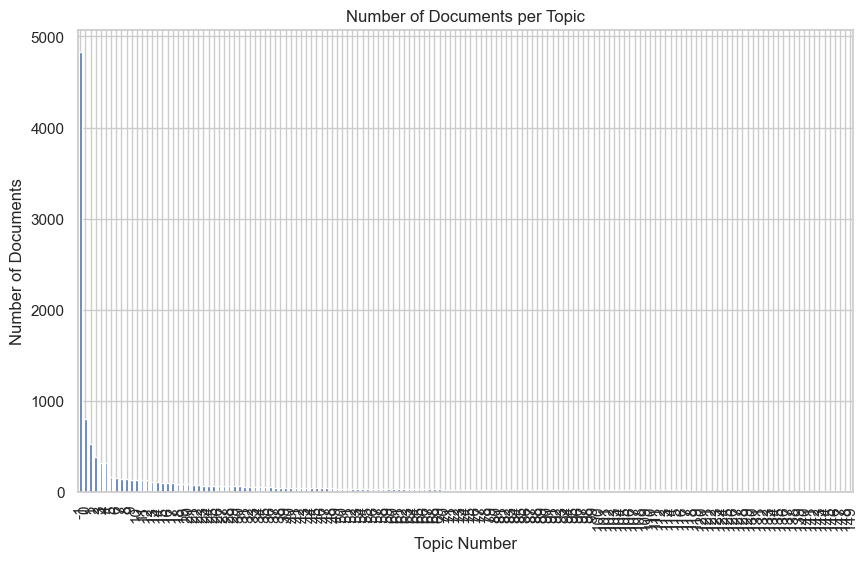

,Document,Topic,Name,CustomName,Representation,Representative_Docs,Top_n_words,Probability,Representative_document
0,Statistical learning in action. #ChatGPT does ...,-1,-1_ai_job_jobs_chatgpt,-1_Outliers_噪音,"[ai, job, jobs, chatgpt, openai, just, like, p...",[The thing is the first jobs AI should replace...,ai - job - jobs - chatgpt - openai - just - li...,0.744401,False
1,Statistical learning in action. #ChatGPT does ...,-1,-1_ai_job_jobs_chatgpt,-1_Outliers_噪音,"[ai, job, jobs, chatgpt, openai, just, like, p...",[The thing is the first jobs AI should replace...,ai - job - jobs - chatgpt - openai - just - li...,0.680477,False
2,Asked OpenAI's ChatGPT (Dec 15 version) to wri...,-1,-1_ai_job_jobs_chatgpt,-1_Outliers_噪音,"[ai, job, jobs, chatgpt, openai, just, like, p...",[The thing is the first jobs AI should replace...,ai - job - jobs - chatgpt - openai - just - li...,0.632316,False
3,Will ChatGPT Destroy iOS Developer Jobs? A Dem...,-1,-1_ai_job_jobs_chatgpt,-1_Outliers_噪音,"[ai, job, jobs, chatgpt, openai, just, like, p...",[The thing is the first jobs AI should replace...,ai - job - jobs - chatgpt - openai - just - li...,0.340813,False
4,Some job advice for coverage lawyers from Chat...,-1,-1_ai_job_jobs_chatgpt,-1_Outliers_噪音,"[ai, job, jobs, chatgpt, openai, just, like, p...",[The thing is the first jobs AI should replace...,ai - job - jobs - chatgpt - openai - just - li...,0.631393,False


In [38]:
# 5️⃣ Assign topics back to original dataframe
job_filtered_df['topic'] = topics
job_filtered_df['topic_probability'] = [prob.max() for prob in probabilities]

# 6️⃣ Plot document count per topic
topic_counts = job_filtered_df['topic'].value_counts().sort_index()
plt.figure(figsize=(10,6))
topic_counts.plot(kind='bar')
plt.xlabel('Topic Number')
plt.ylabel('Number of Documents')
plt.title('Number of Documents per Topic')
plt.show()

# 7️⃣ Get detailed document-topic info (optional)
doc_info = topic_model.get_document_info(job_filtered_df['cleaned_text'].tolist())
display(doc_info.head())

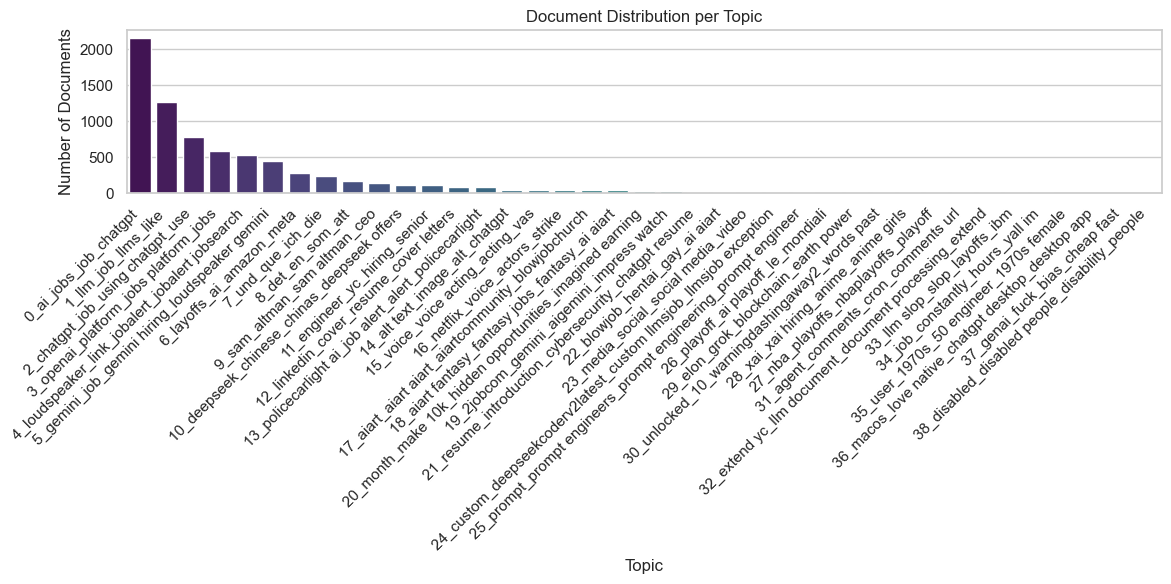

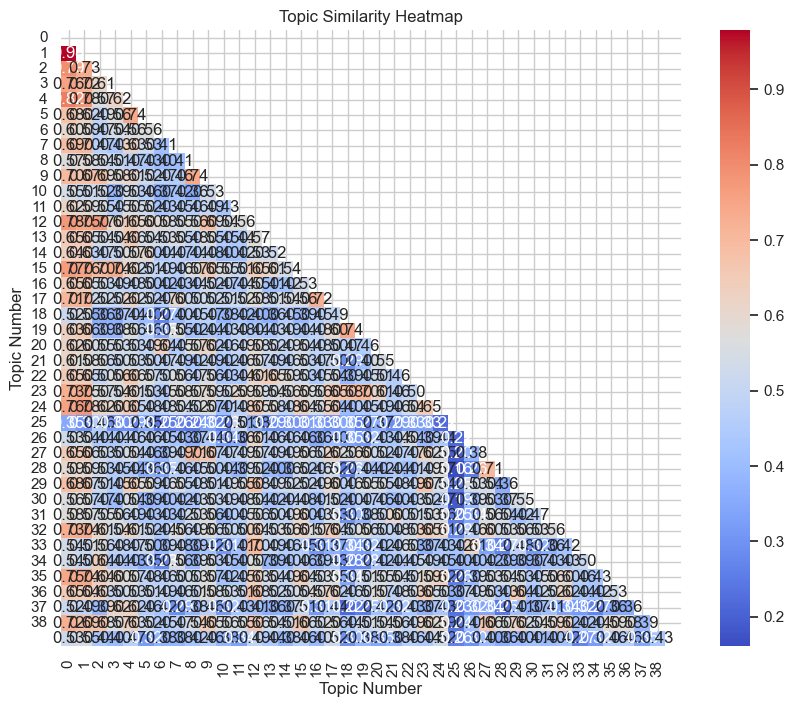

In [39]:
# 1️⃣ Get topic info
topic_info = topic_model.get_topic_info()
topic_info_filtered = topic_info[topic_info['Topic'] != -1]  # Exclude noise

# 2️⃣ Beautiful topic distribution plot
plt.figure(figsize=(12,6))
sns.barplot(x='Name', y='Count', data=topic_info_filtered.sort_values('Count', ascending=False), palette='viridis')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Number of Documents')
plt.xlabel('Topic')
plt.title('Document Distribution per Topic')
plt.tight_layout()
plt.show()

# 3️⃣ Topic similarity heatmap
# Get topic embeddings
topic_embeddings = topic_model.topic_embeddings_
if topic_embeddings is not None:
    # Compute cosine similarity between topics
    from sklearn.metrics.pairwise import cosine_similarity
    import numpy as np
    
    similarity_matrix = cosine_similarity(topic_embeddings)
    
    # Mask upper triangle to avoid repetition
    mask = np.triu(np.ones_like(similarity_matrix, dtype=bool))
    
    plt.figure(figsize=(10,8))
    sns.heatmap(similarity_matrix, annot=True, fmt=".2f", cmap='coolwarm', mask=mask,
                xticklabels=topic_info_filtered['Topic'], yticklabels=topic_info_filtered['Topic'])
    plt.title('Topic Similarity Heatmap')
    plt.xlabel('Topic Number')
    plt.ylabel('Topic Number')
    plt.show()
else:
    print("No topic embeddings available for heatmap.")